<span style="font-size:2em; font-weight:bold;"> Variogram, Correlation and Kriging Estimation (VarioCorreKrigE): Cokriging and Collocated Cokriging modelling and estimation </span>
***

In this notebook we explore cokriging and collocated cokriging through an example from Samson and Deutsch (2020) [https://geostatisticslessons.com/lessons/collocatedcokriging | https://github.com/GeostatisticsLessons/GeostatisticsLessonsNotebooks/blob/master/notebooks/collocatedcokriging/collocatedcokriging.ipynb]. The examples are outlined as follows:

1) Example 1: Simple Cokriging (SCK)
2) Example 2: Simple Collocated Cokriging (SCCK) using Markov Models 1 and 2 (MM1/MM2)
3) Example 3: Intrinsic Simple Collocated Cokriging (ISCCK) using Markov Models 1 and 2 (MM1/MM2)
4) Example 4: Ordinary Cokriging (OCK)
5) Example 5: Ordinary Collocated Cokriging (OCCK) using Markov Models 1 and 2 (MM1/MM2)
6) Example 6: Intrinsic Ordinary Collocated Cokriging (IOCCK) using Markov Models 1 and 2 (MM1/MM2)

The same dataset as per Samson and Deutsch (2020) are used for all examples for consistency and comparability. However, it should be noted that these examples do not fit explicit minor and major correlogram structures and as such the results will not be exact. A psuedo rotation is instead imposed which should not be used other than for visualization purposes to determine the meaningful impact minor and major directions may have the cokriged results.

_Each example is designed to be standalone once section 1.0 is run which makes it easy to trial the differences across the various cokriging algorithms_

# 1.0 Import modules and Data

## 1.1 Import modules

### 1.1.1 General Use

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
import seaborn as sns
from sklearn.metrics import mean_squared_error

### 1.1.2 cokrig

In [2]:
from VarioCorreKrigE.variofit import variofit, crossvariofit
from VarioCorreKrigE.cckrig import align_lmc_experimental_bins, estimate_collocated_correlation, search_lmc_model_space, simple_cokriging, ordinary_cokriging, make_lmc_structure_spec, make_covmodel_spec, SCCK_MM1, SCCK_MM2, OCCK_MM1, OCCK_MM2, ICCK_MM1, ICCK_MM2, OICCK_MM1, OICCK_MM2

## 1.2 Import Data

In [3]:
datafl = pd.read_csv(r"Data/cluster1.out")
datafl_sec = pd.read_csv(r"Data/ydata.out")
truth = pd.read_csv(r"Data/true.out")
x = np.asarray(pd.read_csv(r"Data/x.out")).reshape(len(datafl_sec))
y = np.asarray(pd.read_csv(r"Data/y.out")).reshape(len(datafl_sec))

## 1.3 Map of data

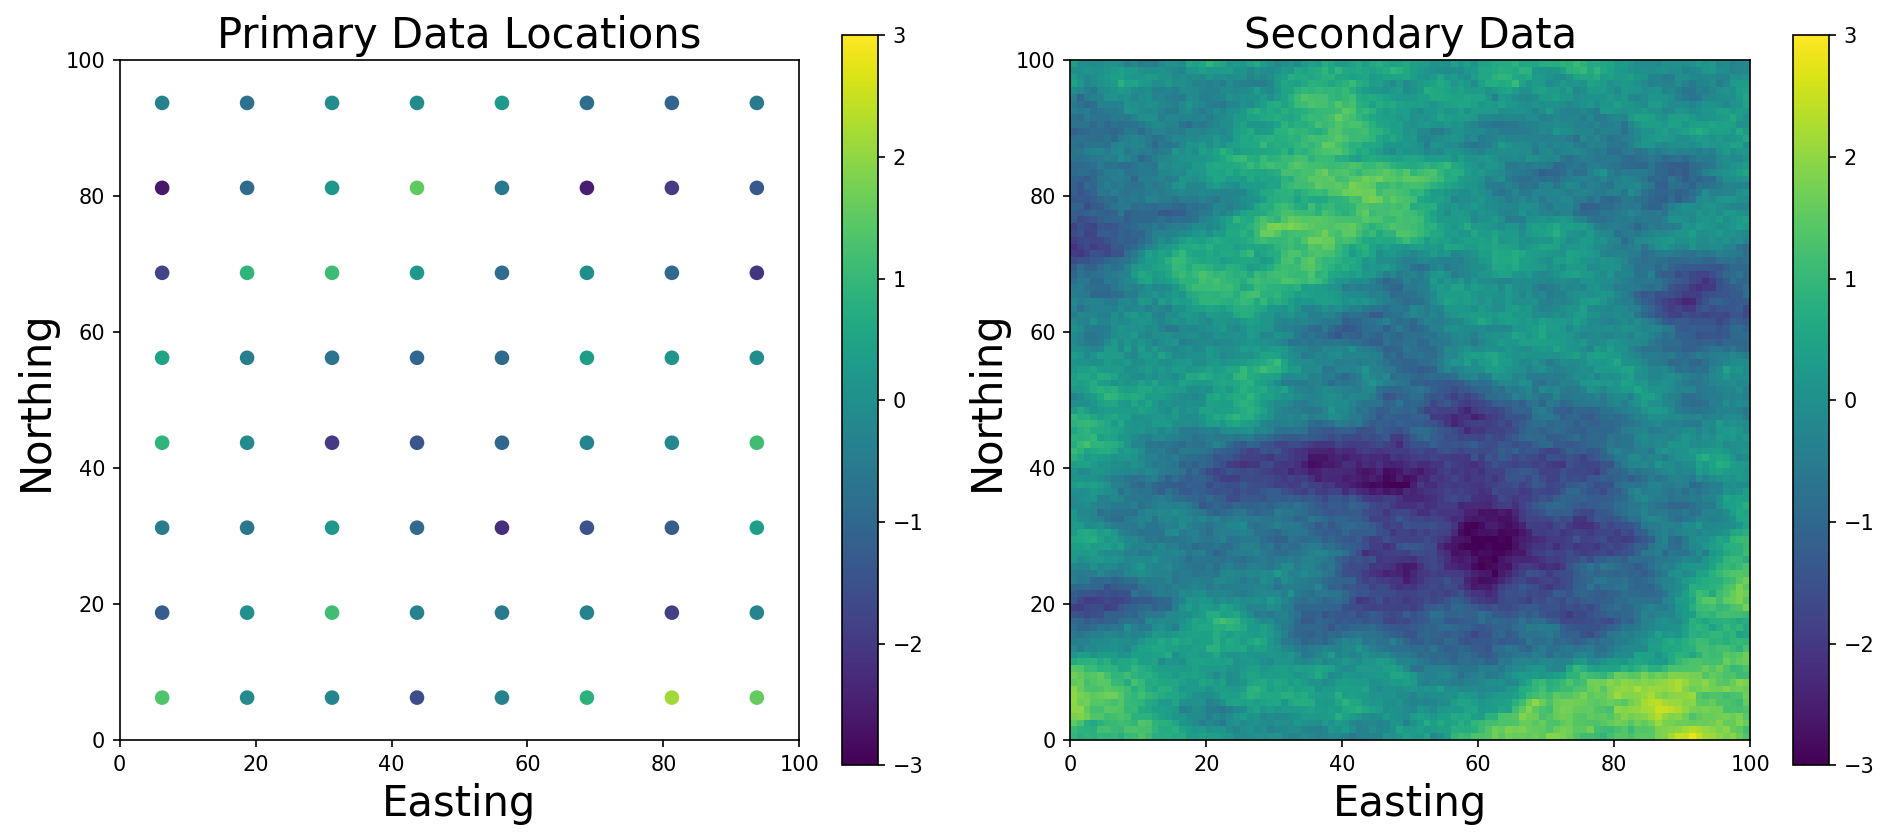

In [4]:
# Limits
vlim = (-3, 3)
XMIN, XMAX = 0, 100
YMIN, YMAX = 0, 100
SMIN, SMAX = -3, 3

# Build gridded field
gridd = pd.DataFrame({
    "Y": y,
    "X": x,
    "Estimate": datafl_sec["Secondary"]
})

# Sort and reshape into 100×100 grid
gridded = gridd.sort_values(["Y", "X"], ascending=True)["Estimate"].values
gridded = gridded.reshape((100, 100), order="C")

# Figure
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5), dpi = 150)

# Panel 1 — Primary Data Locations
img0 = ax[0].scatter(
    datafl["X"], datafl["Y"],
    c=datafl["Primary"].values,
    cmap="viridis",
    vmin=SMIN, vmax=SMAX
)
ax[0].set_title("Primary Data Locations", fontsize=20)
ax[0].set_xlabel("Easting", fontsize=20)
ax[0].set_ylabel("Northing", fontsize=20)
ax[0].set_xlim(XMIN, XMAX)
ax[0].set_ylim(YMIN, YMAX)
ax[0].set_aspect("equal")

# Panel 2 — Secondary Data (Gridded)
img1 = ax[1].imshow(
    gridded,
    origin="lower",
    extent=[XMIN, XMAX, YMIN, YMAX],
    aspect="equal",
    interpolation="none",
    cmap="viridis",
    vmin=SMIN, vmax=SMAX
)
ax[1].set_title("Secondary Data", fontsize=20)
ax[1].set_xlabel("Easting", fontsize=20)
ax[1].set_ylabel("Northing", fontsize=20)

# Colorbars
fig.colorbar(img0, ax=ax[0])
fig.colorbar(img1, ax=ax[1])

plt.tight_layout()
plt.show()

## 1.4 Distribution and correlation of data

<Figure size 1400x1400 with 0 Axes>

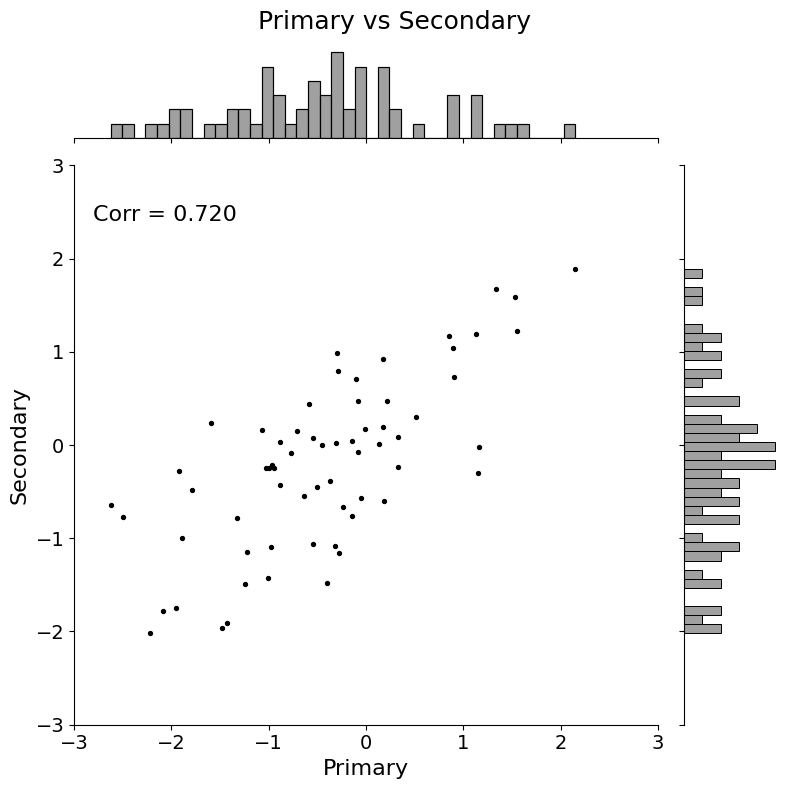

In [5]:
fig = plt.figure(figsize=(7, 7), dpi=200)
g = sns.JointGrid(
    data=datafl,
    x="Primary",
    y="Secondary",
    xlim=(-3, 3),
    ylim=(-3, 3),
    height=8,
    space=0
)

# Main scatter
g.plot_joint(plt.scatter, s=8, color="black")

# Marginal histograms
g.plot_marginals(
    sns.histplot,
    bins=40,
    color="gray",
    kde=False
)

# Correlation text
corr = datafl[["Primary", "Secondary"]].corr().iloc[0, 1]
g.ax_joint.text(-2.8, 2.4, f"Corr = {corr:.3f}", fontsize=12)

g.ax_joint.set_xlabel("Primary", fontsize=16)
g.ax_joint.set_ylabel("Secondary", fontsize=16)

g.ax_joint.tick_params(axis="both", labelsize=14)
g.ax_marg_x.tick_params(axis="both", labelsize=12)
g.ax_marg_y.tick_params(axis="both", labelsize=12)

g.ax_marg_x.set_xlabel("Primary Histogram", fontsize=14)
g.ax_marg_y.set_ylabel("Secondary Histogram", fontsize=14)

for text in g.ax_joint.texts:
    text.set_fontsize(16)

g.figure.suptitle("Primary vs Secondary", fontsize=18)
g.figure.tight_layout()
plt.show()

## 1.5 Make correlograms

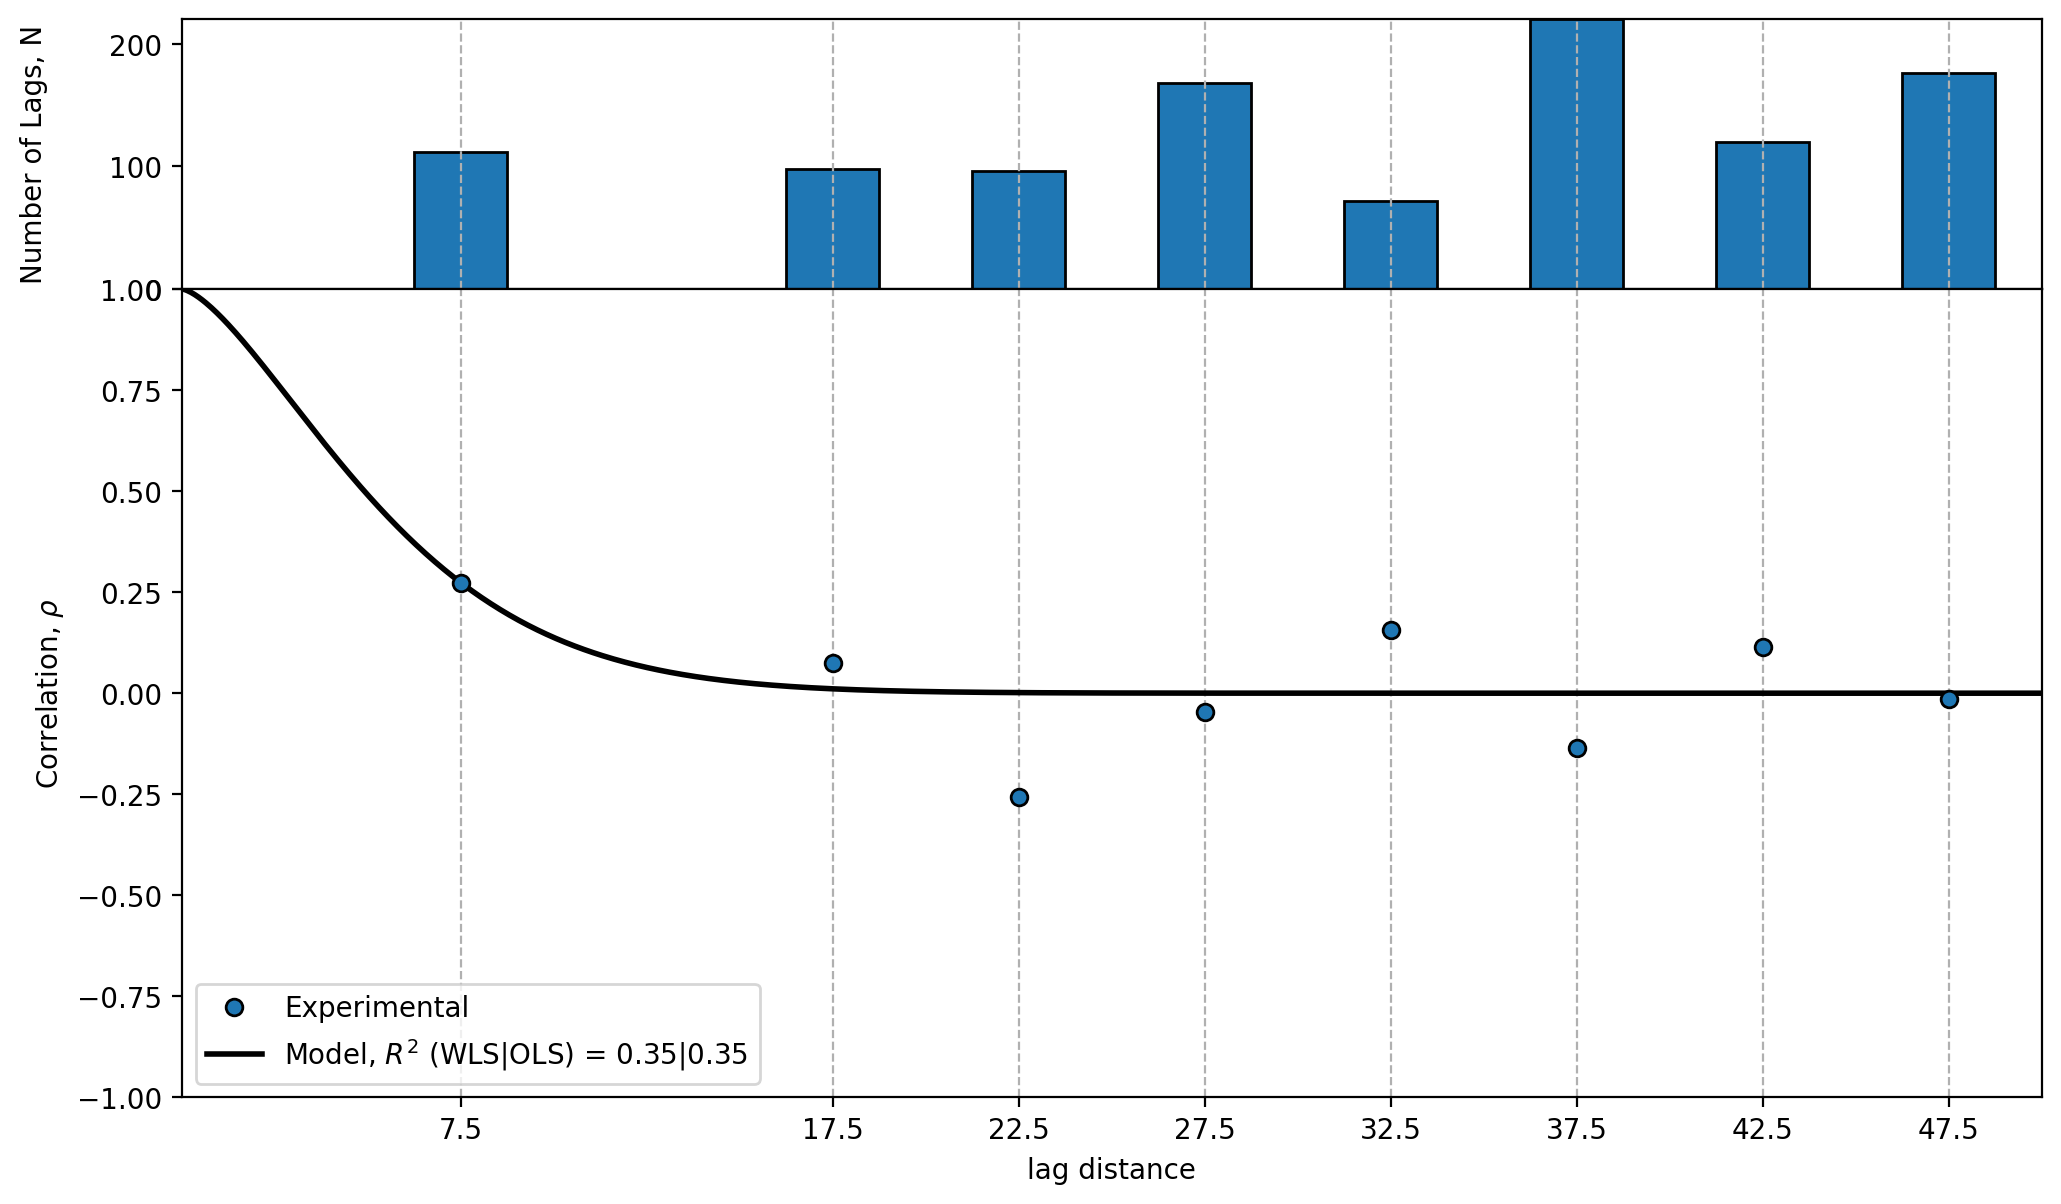

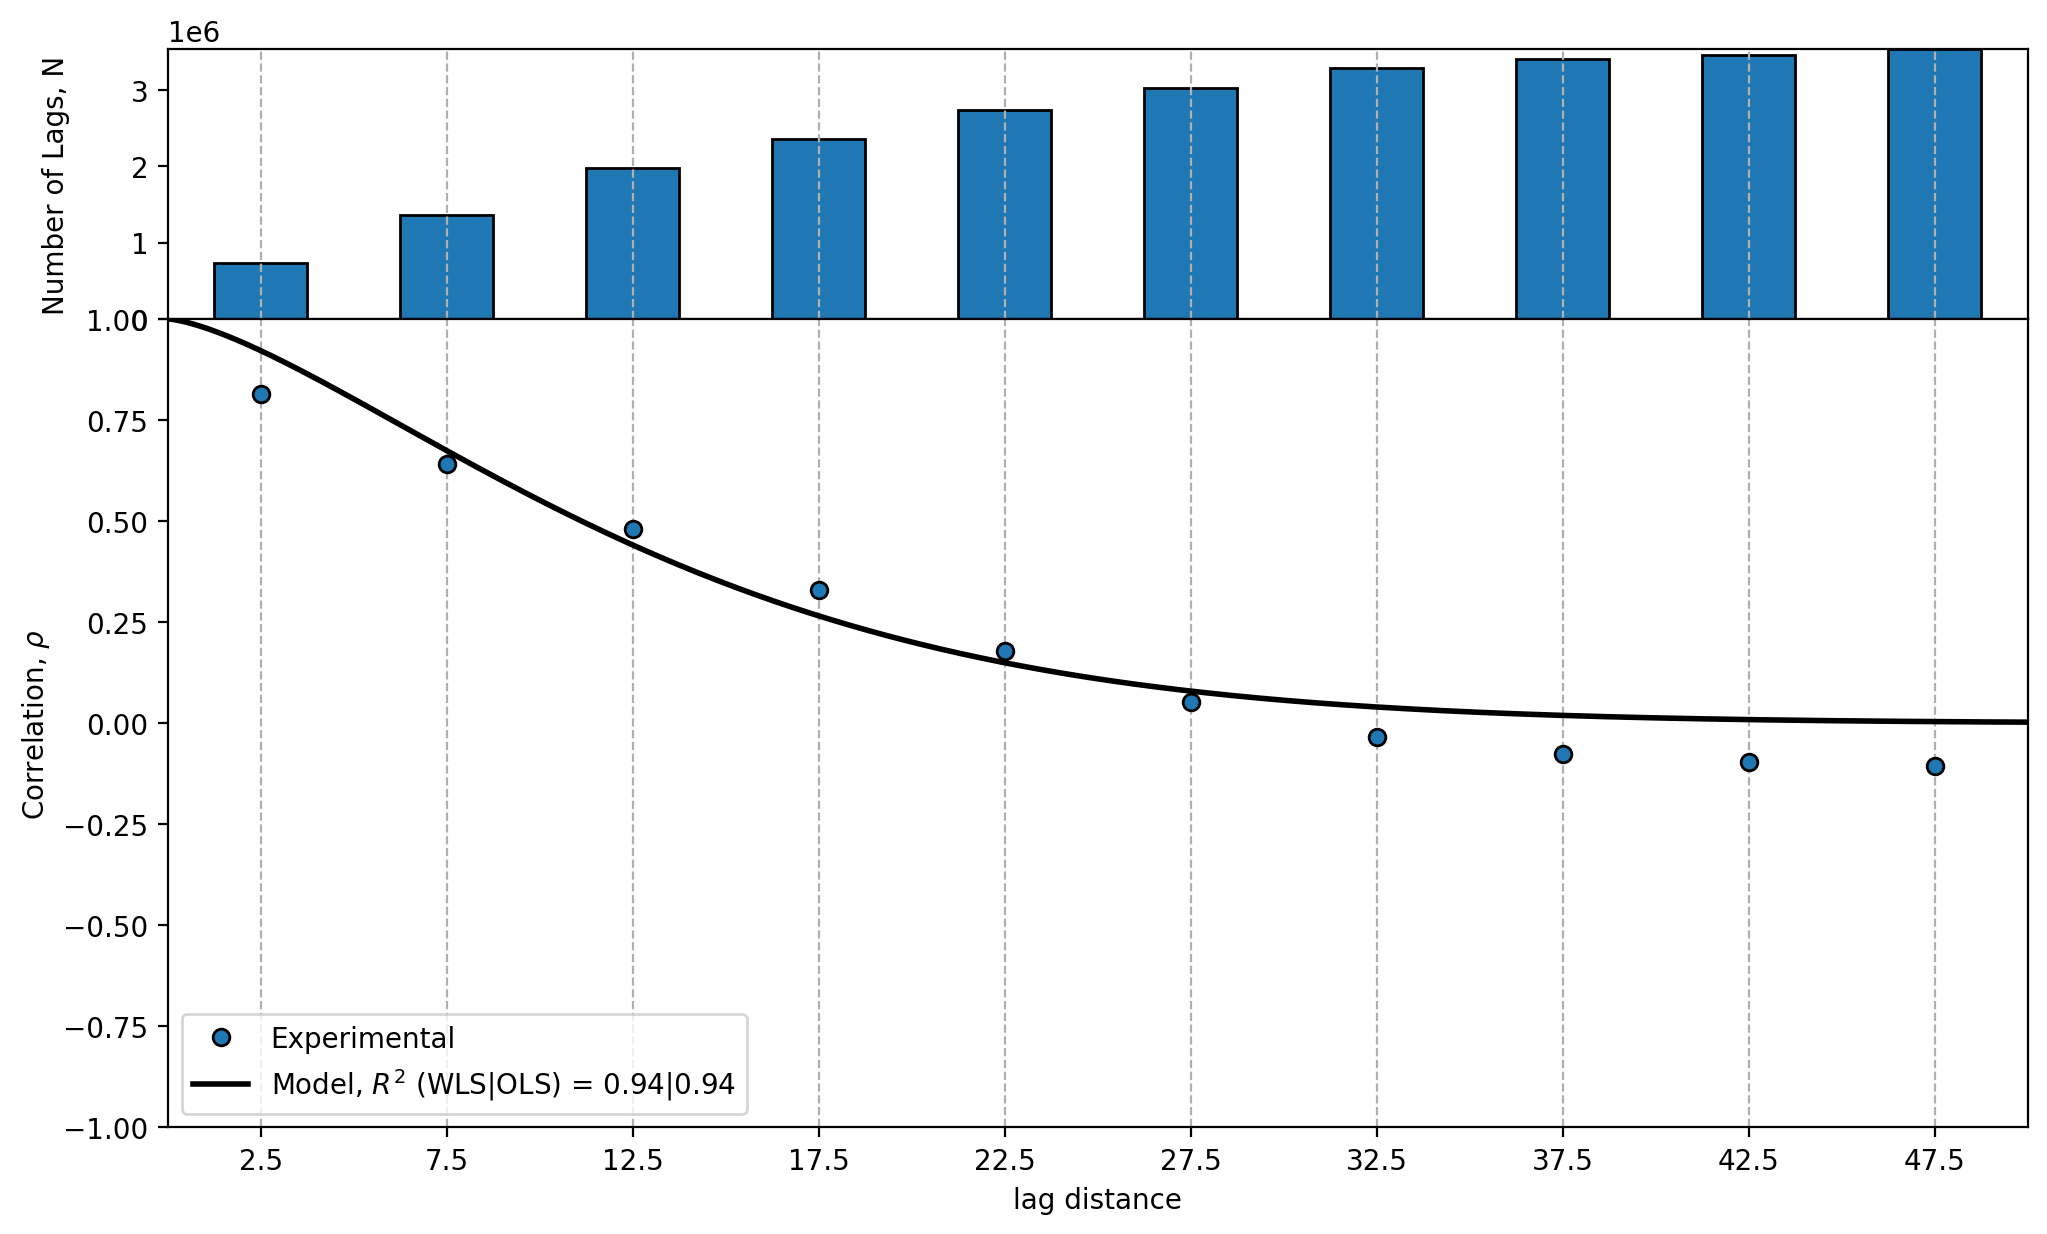

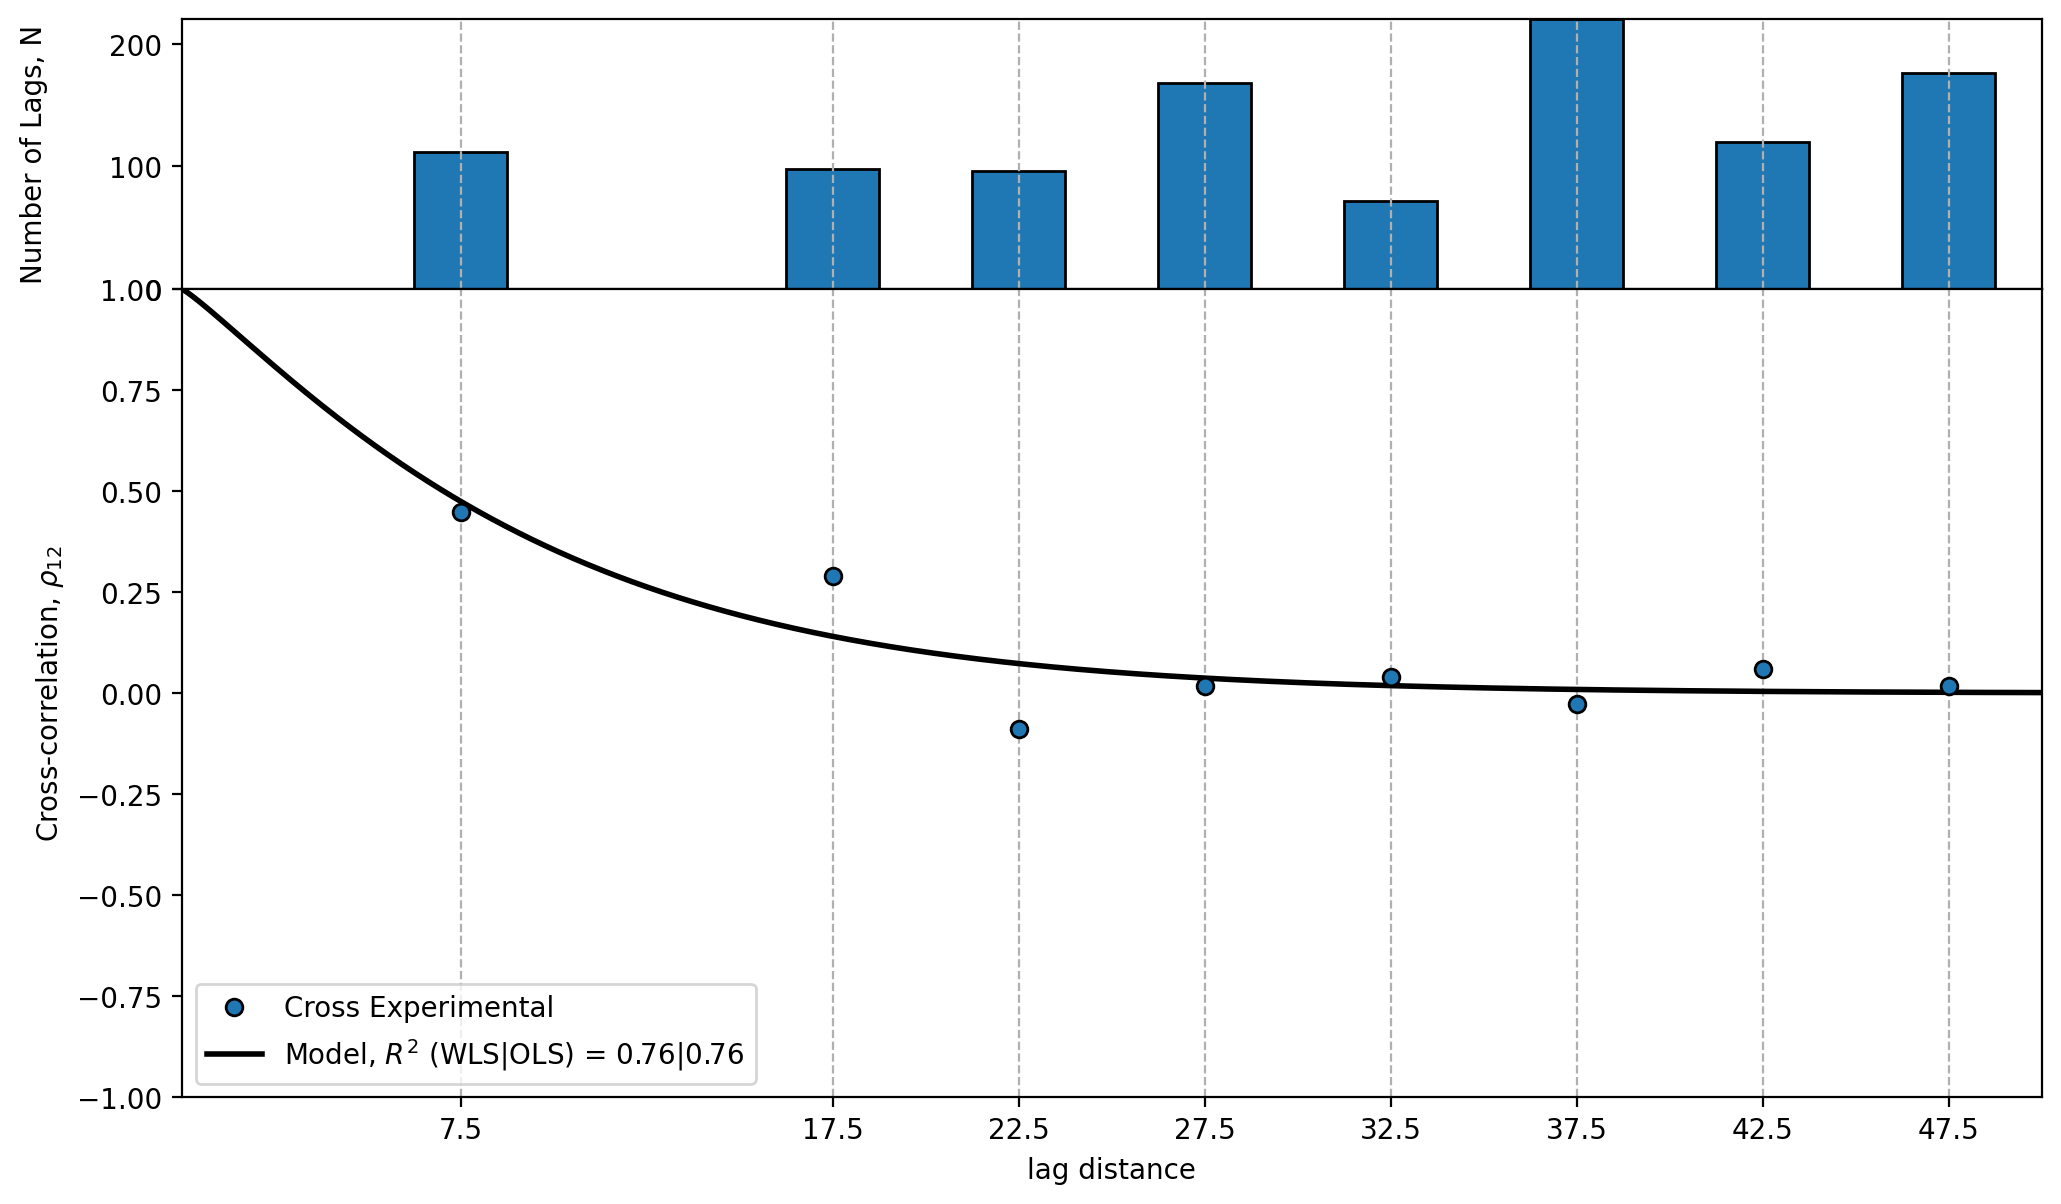

In [6]:
# specify fitting parameters
estimator = "Matheron"
model = "powered_exponential"
weight_fn = None
weight_params = None
xmax_factor = 2

# primary data
h_lag_primary, n_obs_primary, gamma_primary, params_primary, r2_wls_primary, r2_ols_primary = variofit(values = datafl['Primary'], coordinates = datafl[['X','Y']], distance_type = 'cartesian', max_distance = 50, bin_size = 5, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, plot = True, transform="correlation")

# secondary data
h_lag_secondary, n_obs_secondary, gamma_secondary, params_secondary, r2_wls_secondary, r2_ols_secondary = variofit(values = datafl_sec['Secondary'], coordinates = datafl_sec[['X','Y']], distance_type = 'cartesian', max_distance = 50, bin_size = 5, estimator_type= estimator, model_type = model, weight_fn = weight_fn, weight_params = weight_params, xmax_factor=xmax_factor, fix_sill = True, plot = True, transform="correlation")

# crossvariogram
h_lag_cross, n_obs_cross, gamma12_cross, params_cross, r2_wls_cross, r2_ols_cross = crossvariofit(values1=datafl['Primary'],values2=datafl['Secondary'],coordinates=datafl[['X','Y']] ,distance_type="cartesian", max_distance=50, bin_size=5, estimator_type=estimator, model_type=model,weight_fn=weight_fn,weight_params=weight_params,fix_nugget=True,fix_sill=False,allow_negative_sill=False, plot=True, transform="correlation"
)

# 2.0 Example 1: Simple Co-kriging

## 2.1 Build covariance models and LMC

Kernel sets:   0%|          | 0/780 [00:00<?, ?it/s]

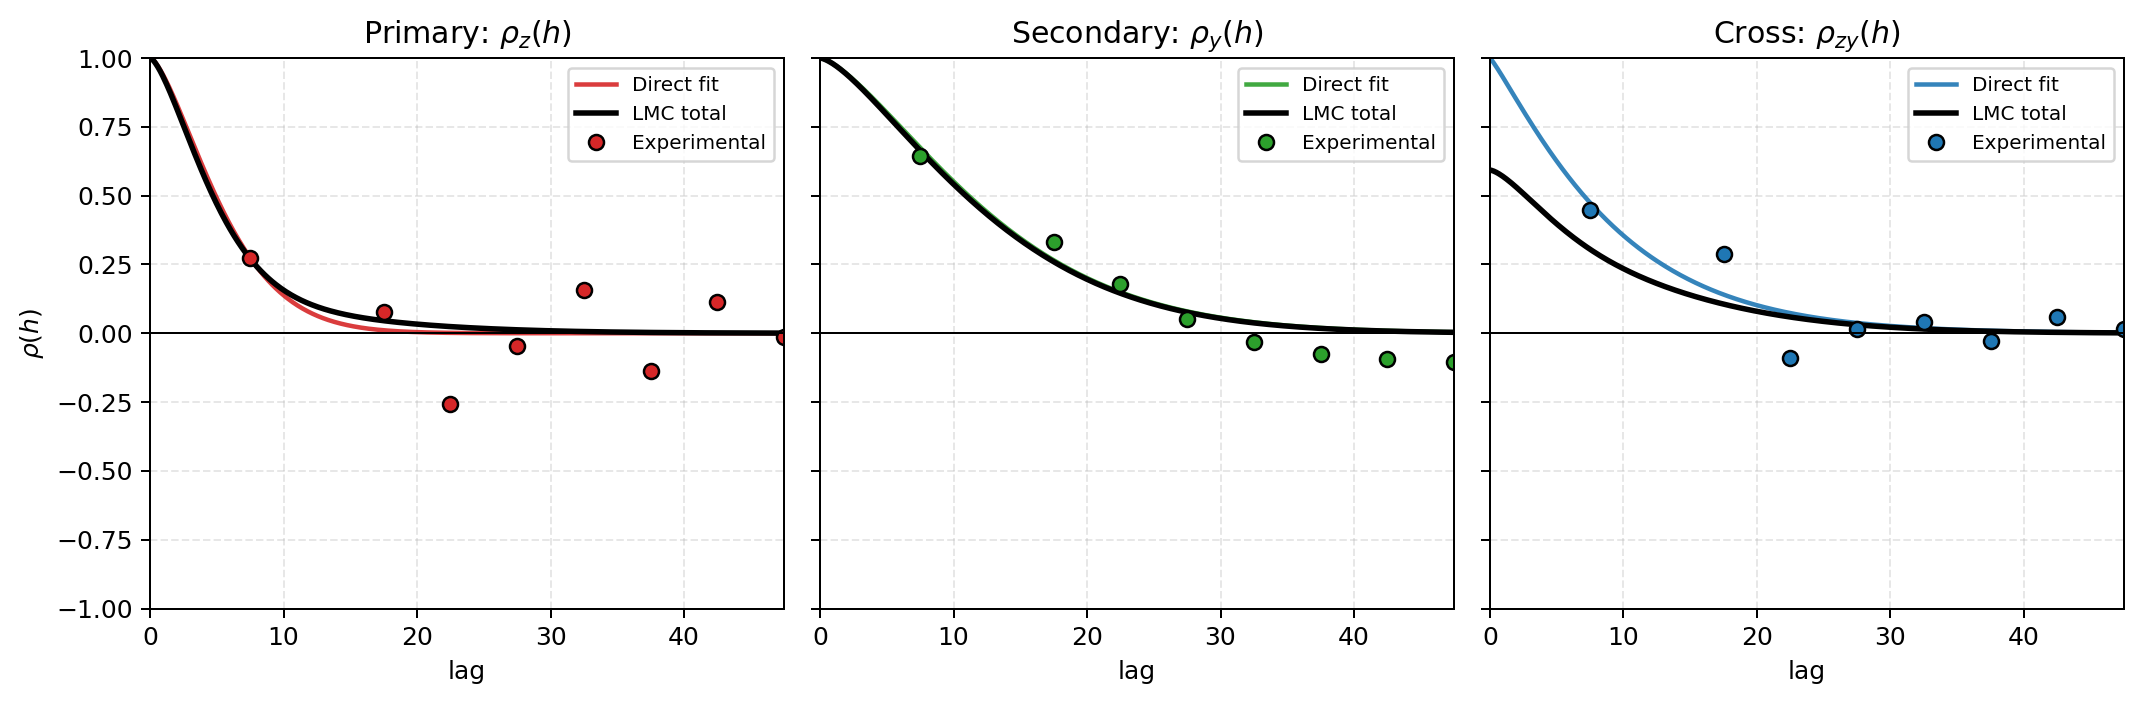

best objective = 0.022956019990793115
best rho0_fit = 0.5929542522974408
best feasible = False
best n_bad_total = 12


In [7]:
h_common, rz_common, ry_common, rzy_common, wz_common, wy_common, wzy_common = align_lmc_experimental_bins(
    h_primary=h_lag_primary,
    rho_primary=gamma_primary,
    n_primary=n_obs_primary,
    h_secondary=h_lag_secondary,
    rho_secondary=gamma_secondary,
    n_secondary=n_obs_secondary,
    h_cross=h_lag_cross,
    rho_cross=gamma12_cross,
    n_cross=n_obs_cross,
)

rho0_target = estimate_collocated_correlation(
    datafl["Primary"].to_numpy(),
    datafl["Secondary"].to_numpy(),
    method="pearson",
)

search_res = search_lmc_model_space(
    h_common,
    rz_common,
    ry_common,
    rzy_common,

    fixed_structures=None,

    model_family="variogram",
    model_type=model,                 # e.g. "powered_exponential"
    params_primary=params_primary,
    params_secondary=params_secondary,
    params_cross=params_cross,
    n_ranges=7,
    range_spacing="linear",
    range_padding_frac=0.15,
    include_direct_ranges=True,
    include_shape_average=True,
    n_structures=2,
    allow_repeated_kernels=False,

    w_primary=wz_common,
    w_secondary=wy_common,
    w_cross=wzy_common,

    cross_misfit_weight_grid=[0.25, 0.5, 1.0, 2.0, 5.0],
    rho0_penalty_weight_grid=[0.0, 0.01, 0.1, 1.0, 10.0],

    normalize_weights=True,

    plot_best=True,
    verbose=False,

)

best = search_res["best"]
best_fit = best["fit"]

print("best objective =", best["objective"])
print("best rho0_fit =", best["rho0_fit"])
print("best feasible =", best["is_feasible"])
print("best n_bad_total =", best["n_bad_total"])

## 2.2 Run Co-kriging

### 2.2.1 Case 0: No LMC and No Azimuth/Azimuth

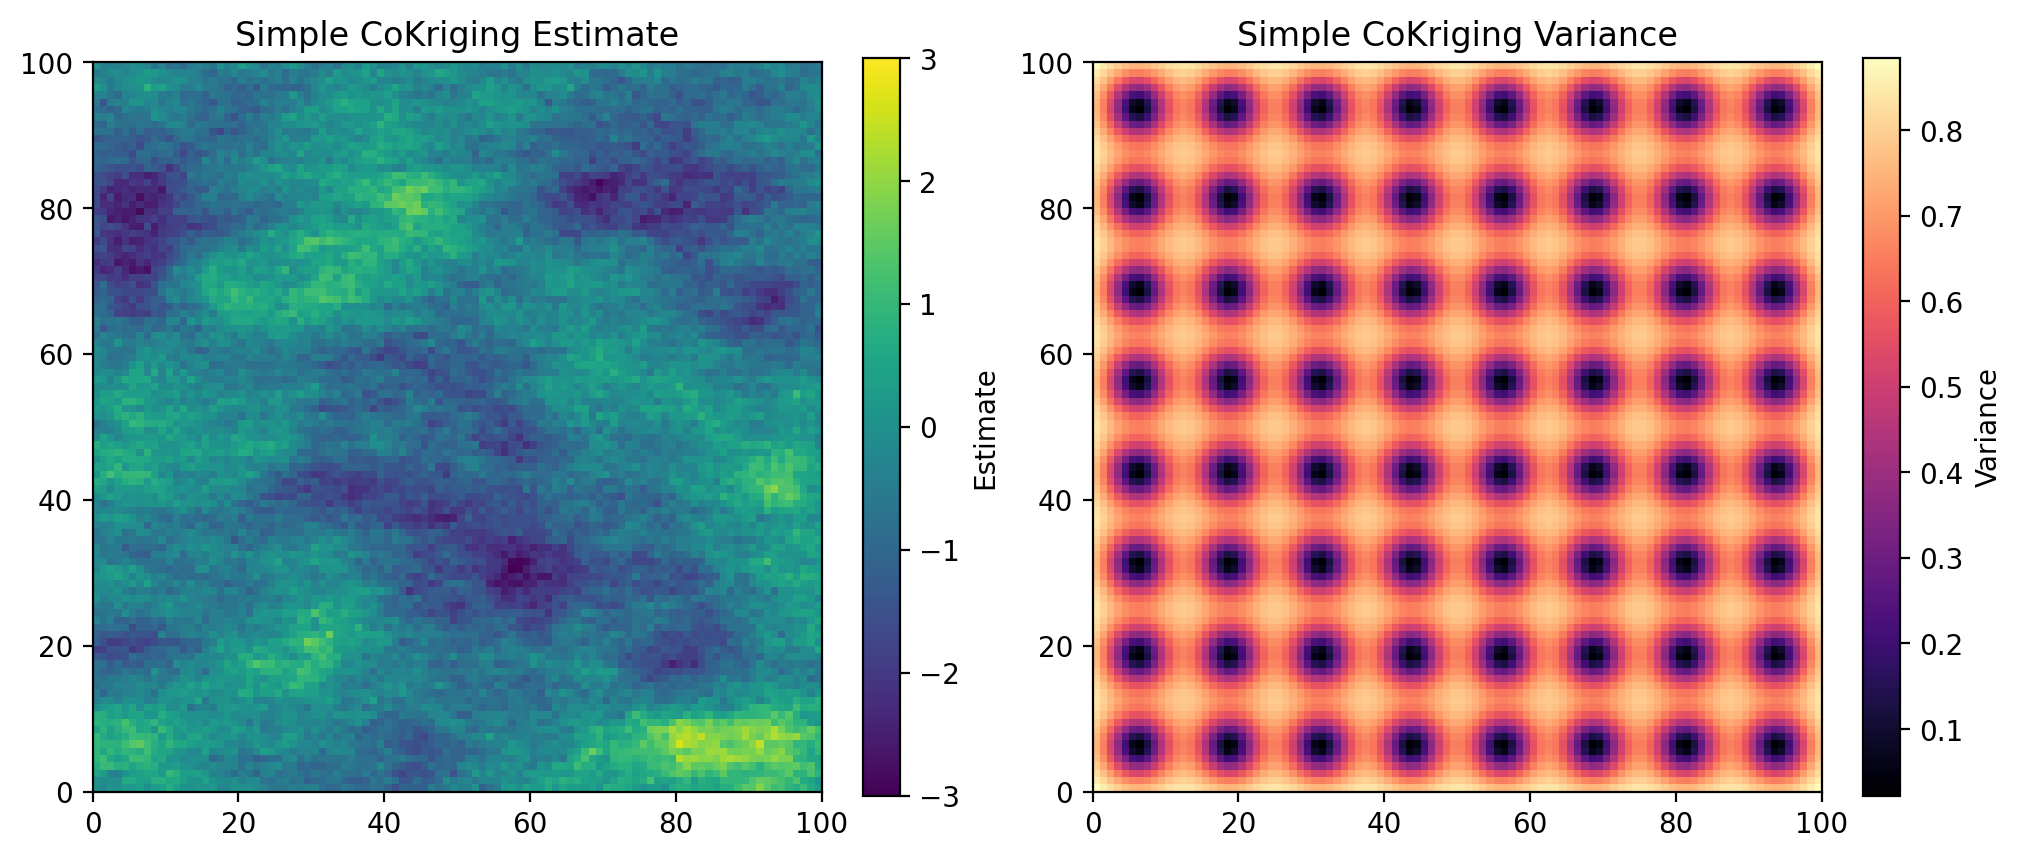

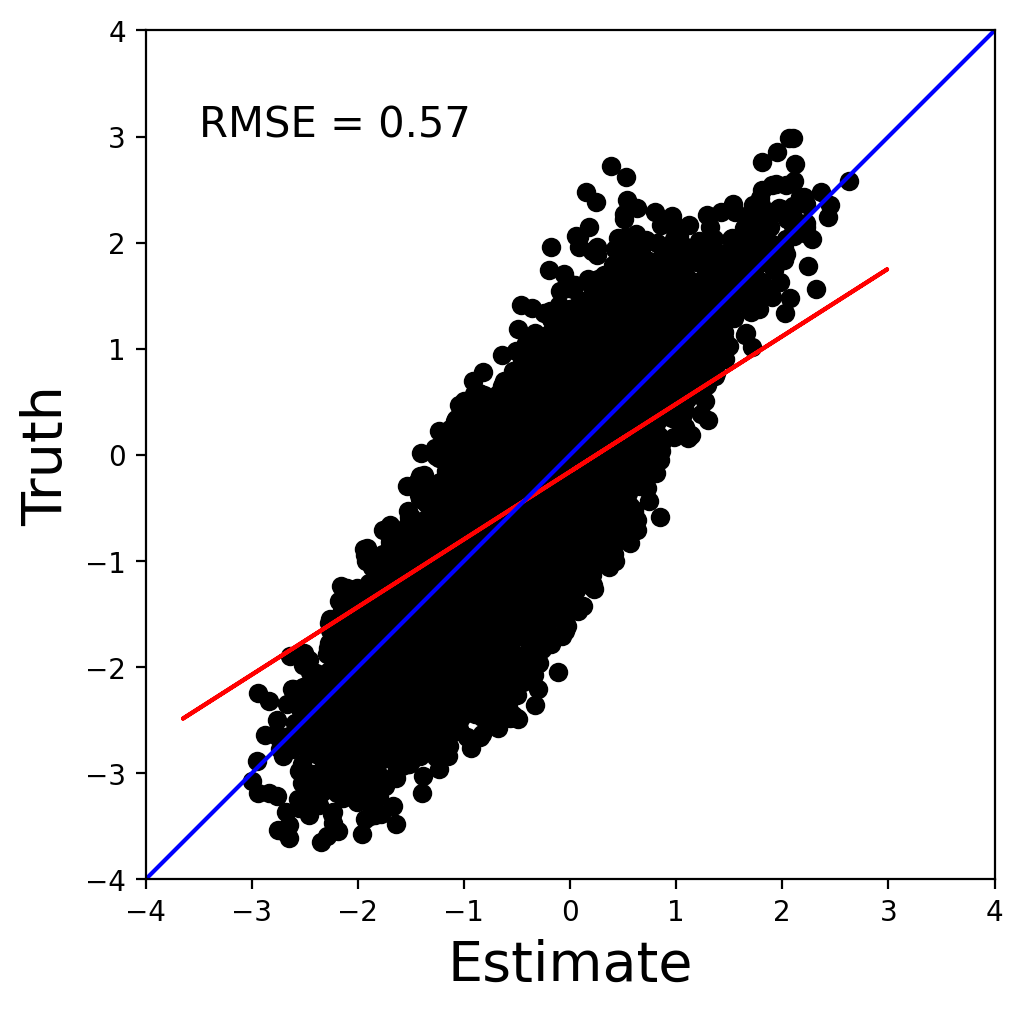

In [8]:
primary_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_primary,
)

secondary_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_secondary,
)

cross_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_cross,
    cross_scale=0.32,
)

est, var, wz, wy = simple_cokriging(
    primary_values=datafl["Primary"].to_numpy(),
    primary_coords=datafl[["X", "Y"]].to_numpy(),
    secondary_values=datafl_sec["Secondary"].to_numpy(),
    secondary_coords=datafl_sec[["X", "Y"]].to_numpy(),
    targets=datafl_sec[["X", "Y"]].to_numpy(),
    covariance_mode="direct",
    primary_model=primary_model,
    secondary_model=secondary_model,
    cross_model=cross_model,
    distance_type="cartesian",
    rotation_matrix=None,
    standardize=True,
    jitter=1e-10,
    check_positive_definite=True,
    return_weights=True,
)

# plot
nx = len(np.unique(datafl_sec["X"]))
ny = len(np.unique(datafl_sec["Y"]))

X = datafl_sec["X"].to_numpy().reshape(ny, nx)
Y = datafl_sec["Y"].to_numpy().reshape(ny, nx)

EST = est.reshape(ny, nx)
VAR = var.reshape(ny, nx)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=200, constrained_layout=True)
im0 = ax[0].pcolormesh(X, Y, EST, cmap="viridis", shading="auto", vmin = -3, vmax = 3)
ax[0].set_title("Simple CoKriging Estimate")
ax[0].set_aspect("equal")
fig.colorbar(im0, ax=ax[0], label="Estimate", aspect = 20, shrink=0.75, pad = 0.02)
im1 = ax[1].pcolormesh(X, Y, VAR, cmap="magma", shading="auto")
ax[1].set_title("Simple CoKriging Variance")
ax[1].set_aspect("equal")
fig.colorbar(im1, ax=ax[1], label="Variance", aspect = 20, shrink=0.75, pad = 0.02)
plt.show()

# RMSE
RMSE = np.sqrt(mean_squared_error(est, truth["Primary"]))

fig, ax = plt.subplots(figsize=(5, 5), dpi=200, constrained_layout=True)
ax.scatter(est, truth["Primary"], color="Black")
ax.plot(
        (truth["Primary"]),
        np.poly1d(
            np.polyfit(
                truth["Primary"], est, 1
            )
        )((truth["Primary"])),
        color="Red",
    )
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
x_45 = np.linspace(*ax.get_xlim())
ax.plot(x_45, x_45, color="blue")
ax.set_xlabel("Estimate", size=20)
ax.set_ylabel("Truth", size=20)
ax.set_aspect("equal", "box")
ax.text(-3.5, 3.0, f"RMSE = {RMSE:.2f}", fontsize=15)
plt.show()

### 2.2.2 Case 1: LMC and No Azimuth

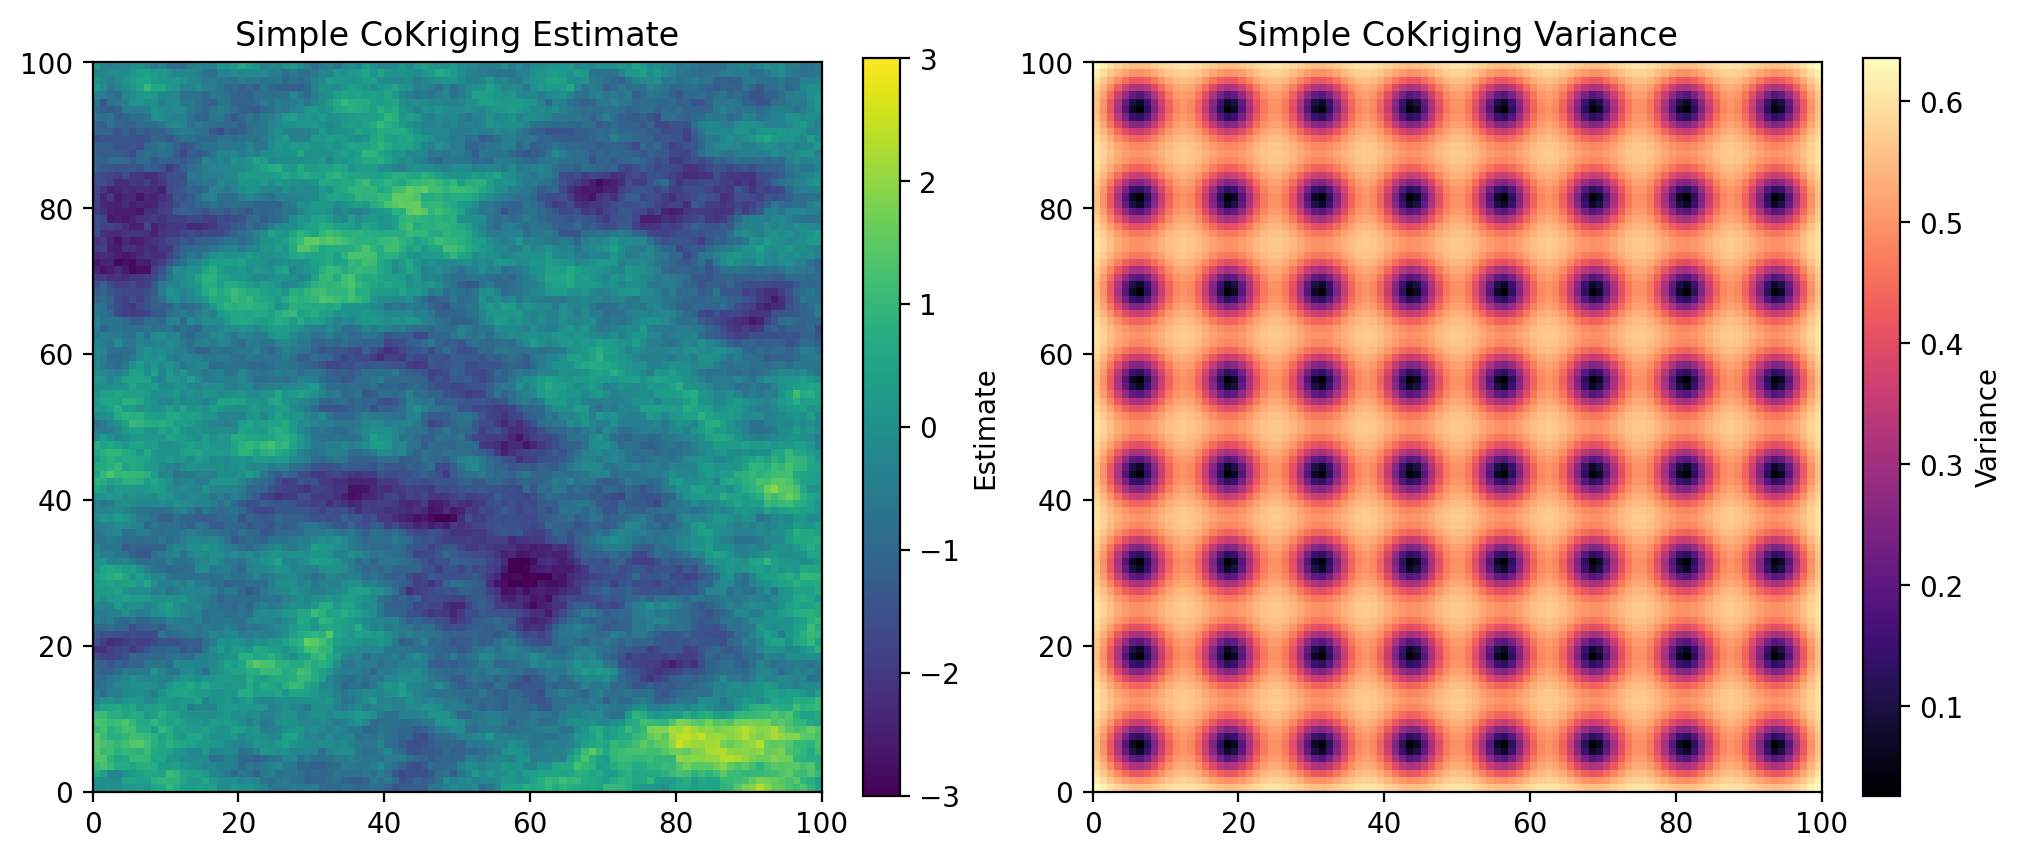

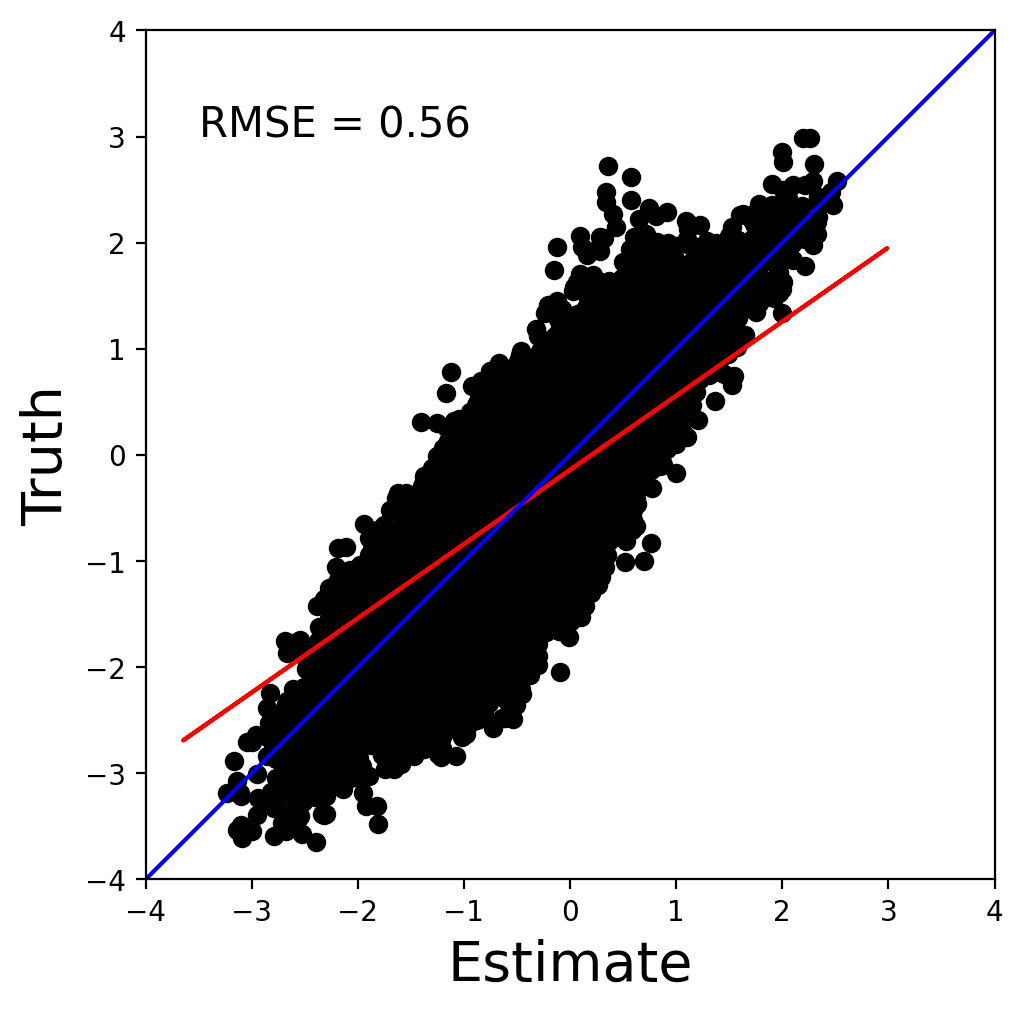

In [9]:
# use bestfit structures
structures = best_fit["structures"]
est, var, wz_ck, wy_ck = simple_cokriging(
    primary_values=datafl["Primary"].to_numpy(),
    primary_coords=datafl[["X", "Y"]].to_numpy(),
    secondary_values=datafl_sec["Secondary"].to_numpy(),
    secondary_coords=datafl_sec[["X", "Y"]].to_numpy(),
    targets=datafl_sec[["X", "Y"]].to_numpy(),
    covariance_mode="lmc",
    structures=structures,
    distance_type="cartesian",
    rotation_matrix=None,
    standardize=True,
    jitter=1e-10,
    check_positive_definite=True,
    return_weights=True,
)

# plot
nx = len(np.unique(datafl_sec["X"]))
ny = len(np.unique(datafl_sec["Y"]))

X = datafl_sec["X"].to_numpy().reshape(ny, nx)
Y = datafl_sec["Y"].to_numpy().reshape(ny, nx)

EST = est.reshape(ny, nx)
VAR = var.reshape(ny, nx)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=200, constrained_layout=True)
im0 = ax[0].pcolormesh(X, Y, EST, cmap="viridis", shading="auto", vmin = -3, vmax = 3)
ax[0].set_title("Simple CoKriging Estimate")
ax[0].set_aspect("equal")
fig.colorbar(im0, ax=ax[0], label="Estimate", aspect = 20, shrink=0.75, pad = 0.02)
im1 = ax[1].pcolormesh(X, Y, VAR, cmap="magma", shading="auto")
ax[1].set_title("Simple CoKriging Variance")
ax[1].set_aspect("equal")
fig.colorbar(im1, ax=ax[1], label="Variance", aspect = 20, shrink=0.75, pad = 0.02)
plt.show()

# RMSE
RMSE = np.sqrt(mean_squared_error(est, truth["Primary"]))

fig, ax = plt.subplots(figsize=(5, 5), dpi=200, constrained_layout=True)
ax.scatter(est, truth["Primary"], color="Black")
ax.plot(
        (truth["Primary"]),
        np.poly1d(
            np.polyfit(
                truth["Primary"], est, 1
            )
        )((truth["Primary"])),
        color="Red",
    )
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
x_45 = np.linspace(*ax.get_xlim())
ax.plot(x_45, x_45, color="blue")
ax.set_xlabel("Estimate", size=20)
ax.set_ylabel("Truth", size=20)
ax.set_aspect("equal", "box")
ax.text(-3.5, 3.0, f"RMSE = {RMSE:.2f}", fontsize=15)
plt.show()

### 2.2.3 Case 2: LMC and Azimuth per structure/covariance

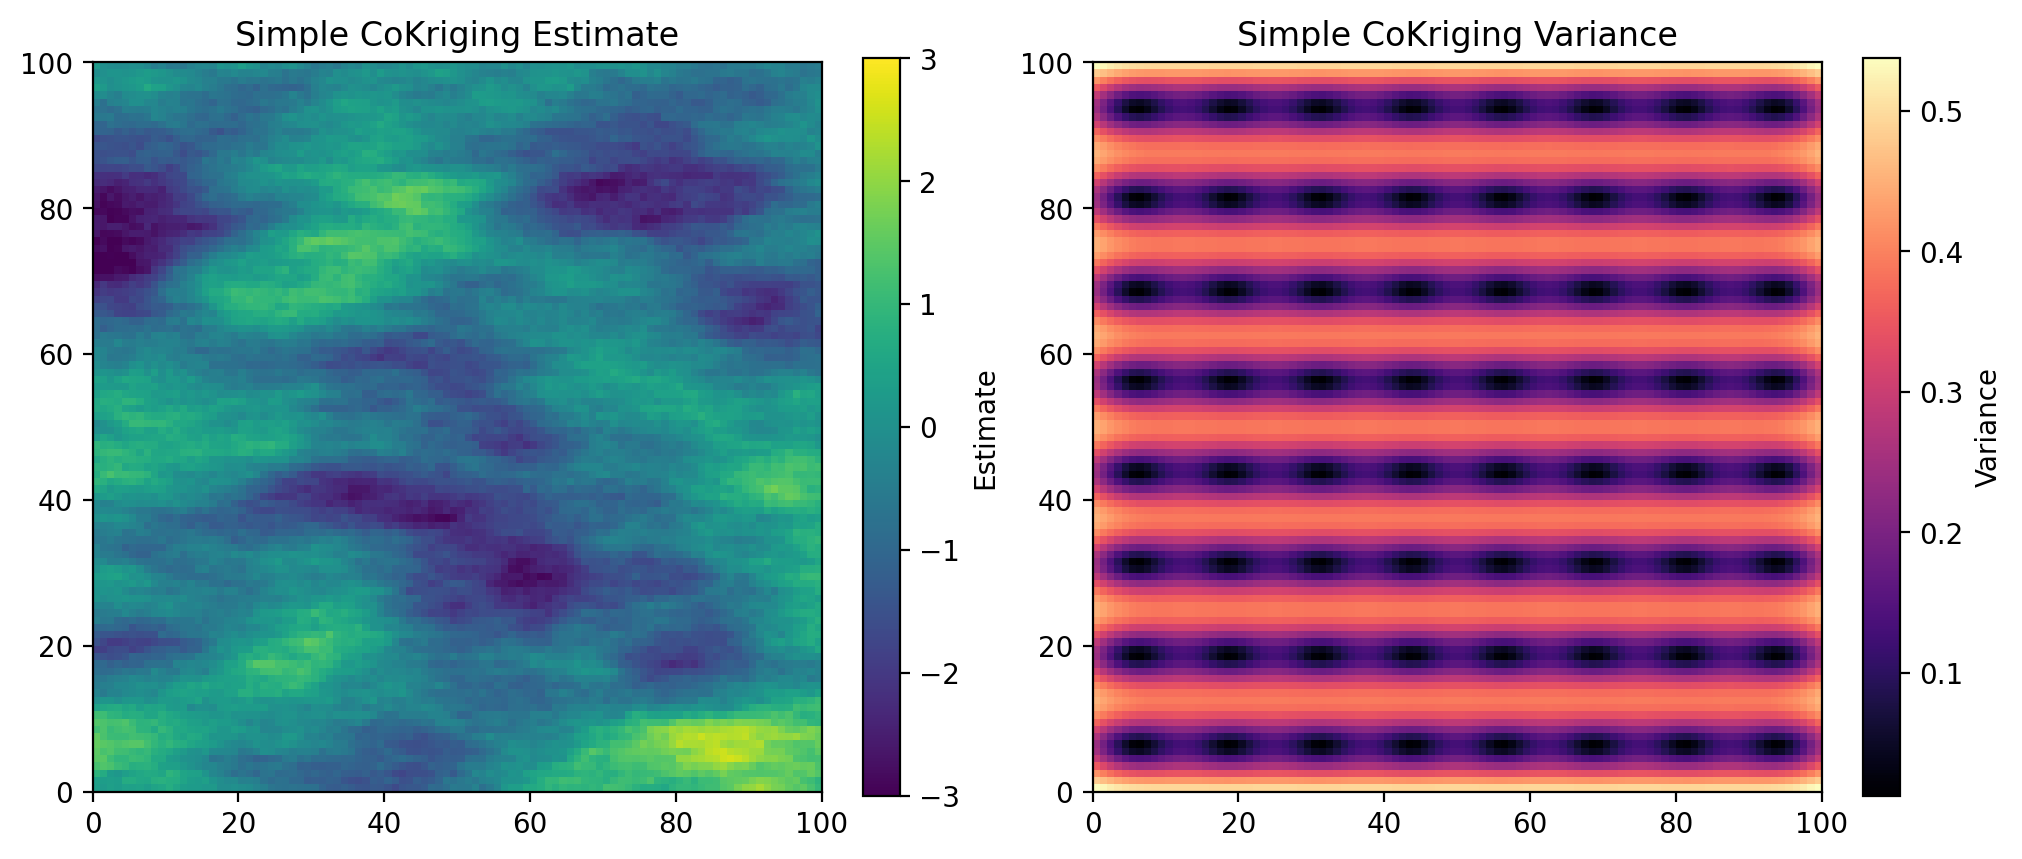

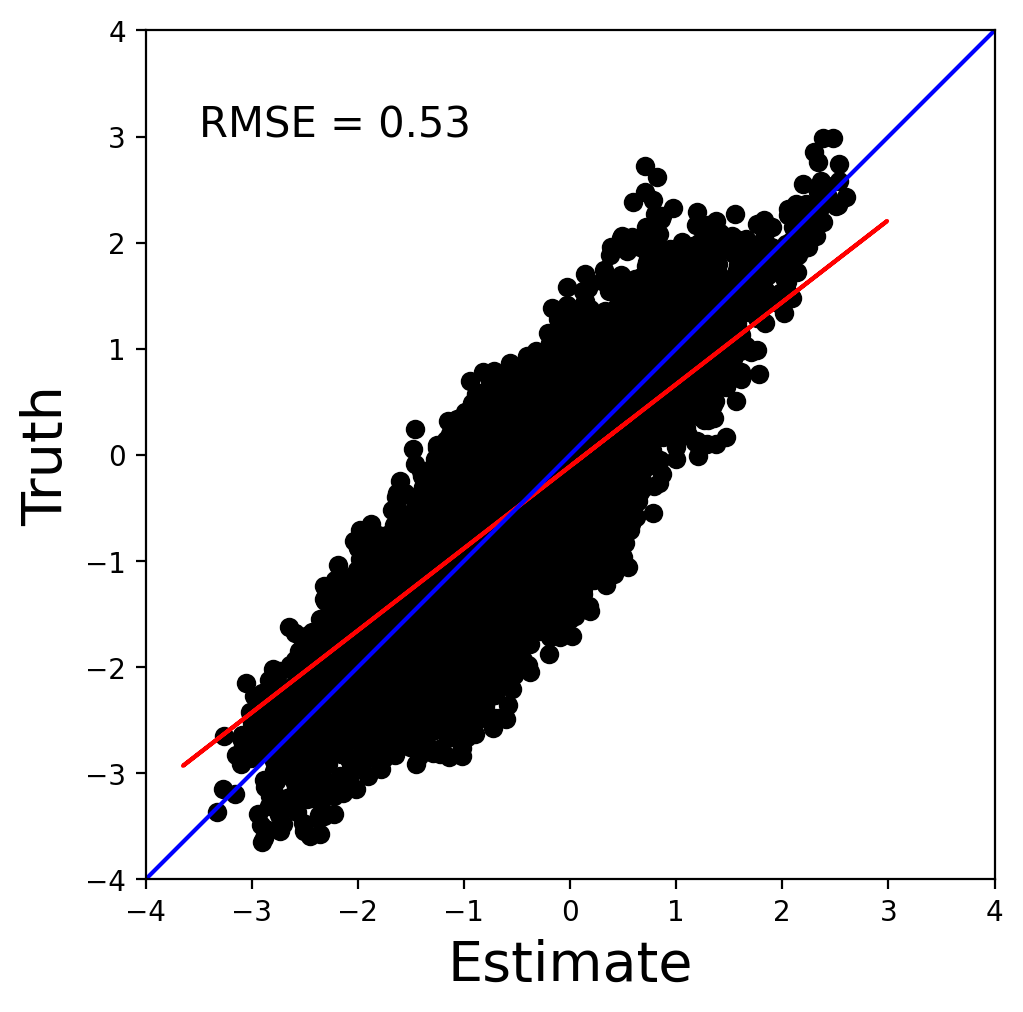

In [10]:
structures = best_fit["structures"]

rotation_matrix = {
    0: {"azimuth": 90.0, "a_max": 33.0, "a_min": 15.0},
    1: {"azimuth": 90.0, "a_max": 40.0, "a_min": 30.0},
}

est, var, wz_ck, wy_ck = simple_cokriging(
    primary_values=datafl["Primary"].to_numpy(),
    primary_coords=datafl[["X", "Y"]].to_numpy(),
    secondary_values=datafl_sec["Secondary"].to_numpy(),
    secondary_coords=datafl_sec[["X", "Y"]].to_numpy(),
    targets=datafl_sec[["X", "Y"]].to_numpy(),
    covariance_mode="lmc",
    structures=structures,
    distance_type="cartesian",
    rotation_matrix=rotation_matrix,
    standardize=True,
    jitter=1e-10,
    check_positive_definite=True,
    return_weights=True,
)

# plot
nx = len(np.unique(datafl_sec["X"]))
ny = len(np.unique(datafl_sec["Y"]))

X = datafl_sec["X"].to_numpy().reshape(ny, nx)
Y = datafl_sec["Y"].to_numpy().reshape(ny, nx)

EST = est.reshape(ny, nx)
VAR = var.reshape(ny, nx)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=200, constrained_layout=True)
im0 = ax[0].pcolormesh(X, Y, EST, cmap="viridis", shading="auto", vmin = -3, vmax = 3)
ax[0].set_title("Simple CoKriging Estimate")
ax[0].set_aspect("equal")
fig.colorbar(im0, ax=ax[0], label="Estimate", aspect = 20, shrink=0.75, pad = 0.02)
im1 = ax[1].pcolormesh(X, Y, VAR, cmap="magma", shading="auto")
ax[1].set_title("Simple CoKriging Variance")
ax[1].set_aspect("equal")
fig.colorbar(im1, ax=ax[1], label="Variance", aspect = 20, shrink=0.75, pad = 0.02)
plt.show()

# RMSE
RMSE = np.sqrt(mean_squared_error(est, truth["Primary"]))

fig, ax = plt.subplots(figsize=(5, 5), dpi=200, constrained_layout=True)
ax.scatter(est, truth["Primary"], color="Black")
ax.plot(
        (truth["Primary"]),
        np.poly1d(
            np.polyfit(
                truth["Primary"], est, 1
            )
        )((truth["Primary"])),
        color="Red",
    )
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
x_45 = np.linspace(*ax.get_xlim())
ax.plot(x_45, x_45, color="blue")
ax.set_xlabel("Estimate", size=20)
ax.set_ylabel("Truth", size=20)
ax.set_aspect("equal", "box")
ax.text(-3.5, 3.0, f"RMSE = {RMSE:.2f}", fontsize=15)
plt.show()

### 2.2.4 Case 3: LMC and Azimuth per structure/covariance, actual parameters

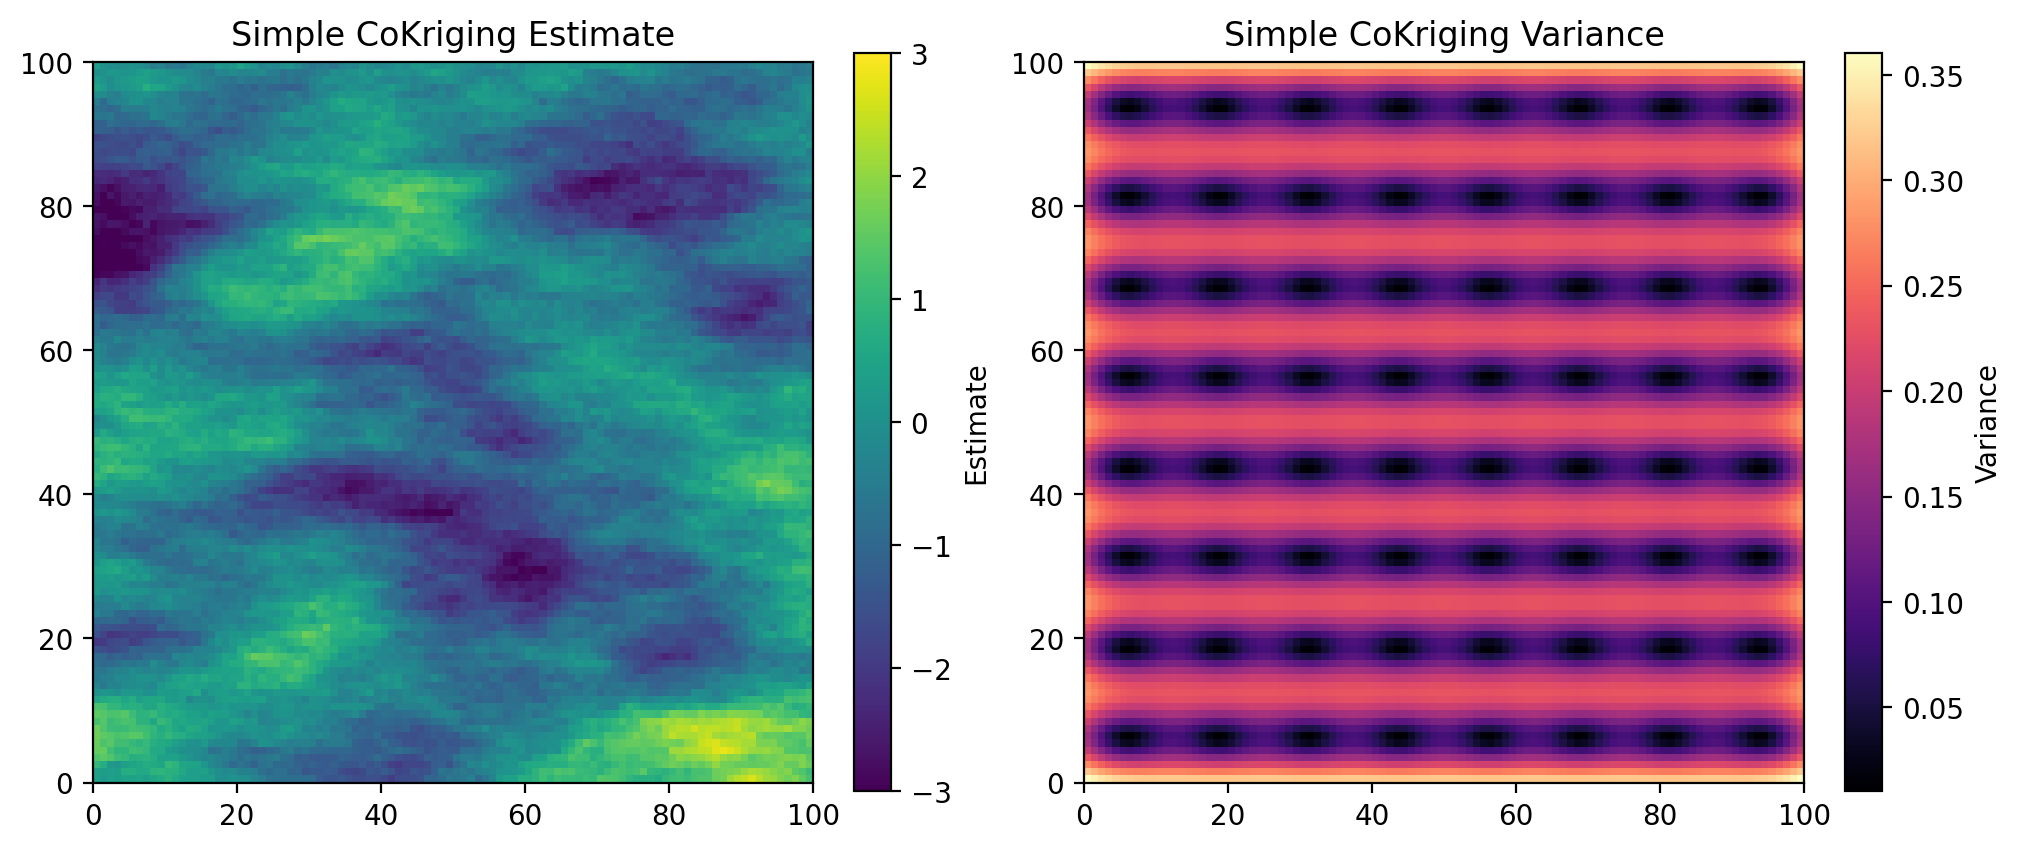

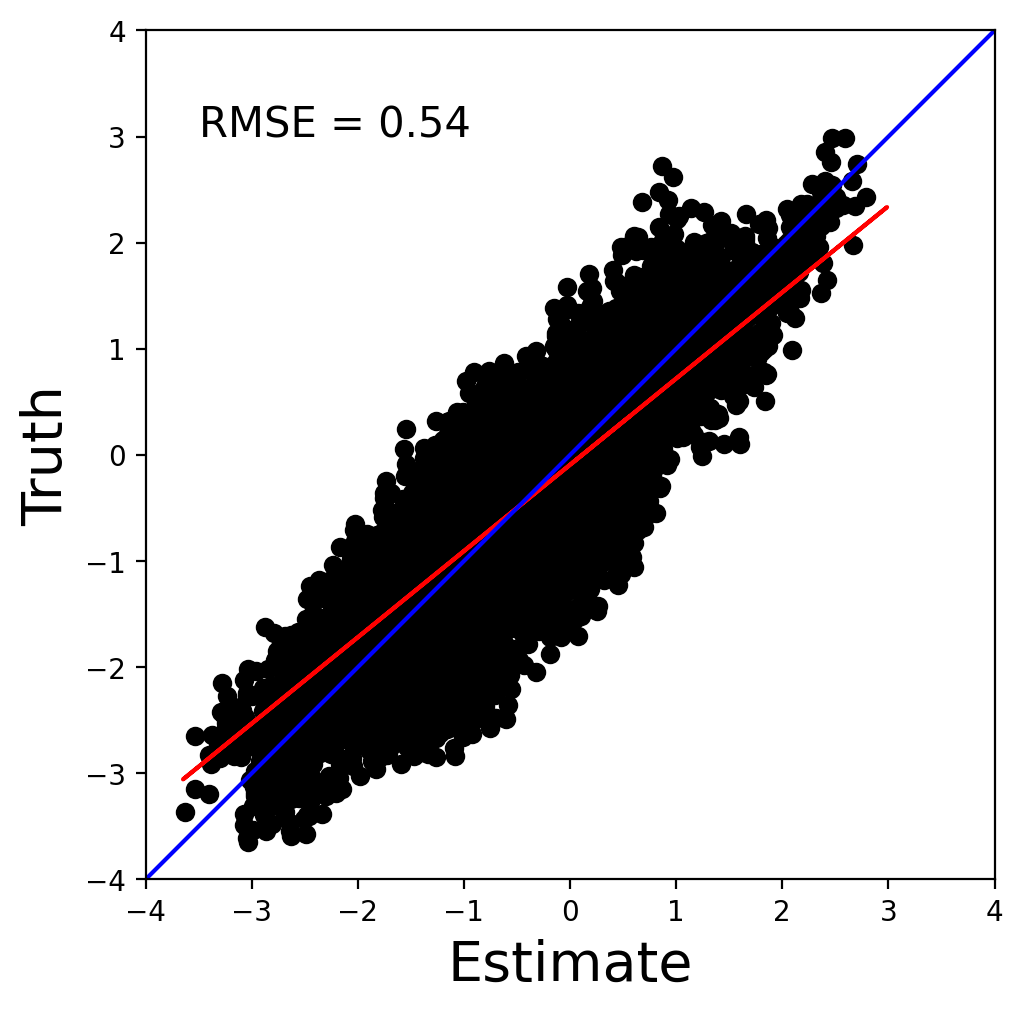

In [11]:
structures_example = [
    make_lmc_structure_spec(
        B=np.array([[0.85, 0.72 * 0.6],
                    [0.72 * 0.6, 0.25]], dtype=float),
        model_family="variogram",
        model_type="powered_exponential",
        params={"r": 1.0, "c0": 1.0, "b": 0.0, "beta": 1.476198801958},
        name="example_1",
    ),
    make_lmc_structure_spec(
        B=np.array([[0.15, 0.72 * 0.4],
                    [0.72 * 0.4, 0.75]], dtype=float),
        model_family="variogram",
        model_type="powered_exponential",
        params={"r": 1.0, "c0": 1.0, "b": 0.0, "beta": 1.476198801958},
        name="example_2",
    ),
]

rotation_matrix = {
    0: {"azimuth": 90.0, "a_max": 33.0, "a_min": 15.0},
    1: {"azimuth": 90.0, "a_max": 40.0, "a_min": 30.0},
}

est, var, wz_ck, wy_ck = simple_cokriging(
    primary_values=datafl["Primary"].to_numpy(),
    primary_coords=datafl[["X", "Y"]].to_numpy(),
    secondary_values=datafl_sec["Secondary"].to_numpy(),
    secondary_coords=datafl_sec[["X", "Y"]].to_numpy(),
    targets=datafl_sec[["X", "Y"]].to_numpy(),
    covariance_mode="lmc",
    structures=structures_example,
    distance_type="cartesian",
    rotation_matrix=rotation_matrix,
    standardize=True,
    jitter=1e-10,
    check_positive_definite=True,
    return_weights=True,
)

# plot
nx = len(np.unique(datafl_sec["X"]))
ny = len(np.unique(datafl_sec["Y"]))

X = datafl_sec["X"].to_numpy().reshape(ny, nx)
Y = datafl_sec["Y"].to_numpy().reshape(ny, nx)

EST = est.reshape(ny, nx)
VAR = var.reshape(ny, nx)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=200, constrained_layout=True)
im0 = ax[0].pcolormesh(X, Y, EST, cmap="viridis", shading="auto", vmin = -3, vmax = 3)
ax[0].set_title("Simple CoKriging Estimate")
ax[0].set_aspect("equal")
fig.colorbar(im0, ax=ax[0], label="Estimate", aspect = 20, shrink=0.75, pad = 0.02)
im1 = ax[1].pcolormesh(X, Y, VAR, cmap="magma", shading="auto")
ax[1].set_title("Simple CoKriging Variance")
ax[1].set_aspect("equal")
fig.colorbar(im1, ax=ax[1], label="Variance", aspect = 20, shrink=0.75, pad = 0.02)
plt.show()

# RMSE
RMSE = np.sqrt(mean_squared_error(est, truth["Primary"]))

fig, ax = plt.subplots(figsize=(5, 5), dpi=200, constrained_layout=True)
ax.scatter(est, truth["Primary"], color="Black")
ax.plot(
        (truth["Primary"]),
        np.poly1d(
            np.polyfit(
                truth["Primary"], est, 1
            )
        )((truth["Primary"])),
        color="Red",
    )
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
x_45 = np.linspace(*ax.get_xlim())
ax.plot(x_45, x_45, color="blue")
ax.set_xlabel("Estimate", size=20)
ax.set_ylabel("Truth", size=20)
ax.set_aspect("equal", "box")
ax.text(-3.5, 3.0, f"RMSE = {RMSE:.2f}", fontsize=15)
plt.show()

# 3.0 Example 2: Simple Co-located Cokriging Markov Models

## 3.1 Make Residual correlograms

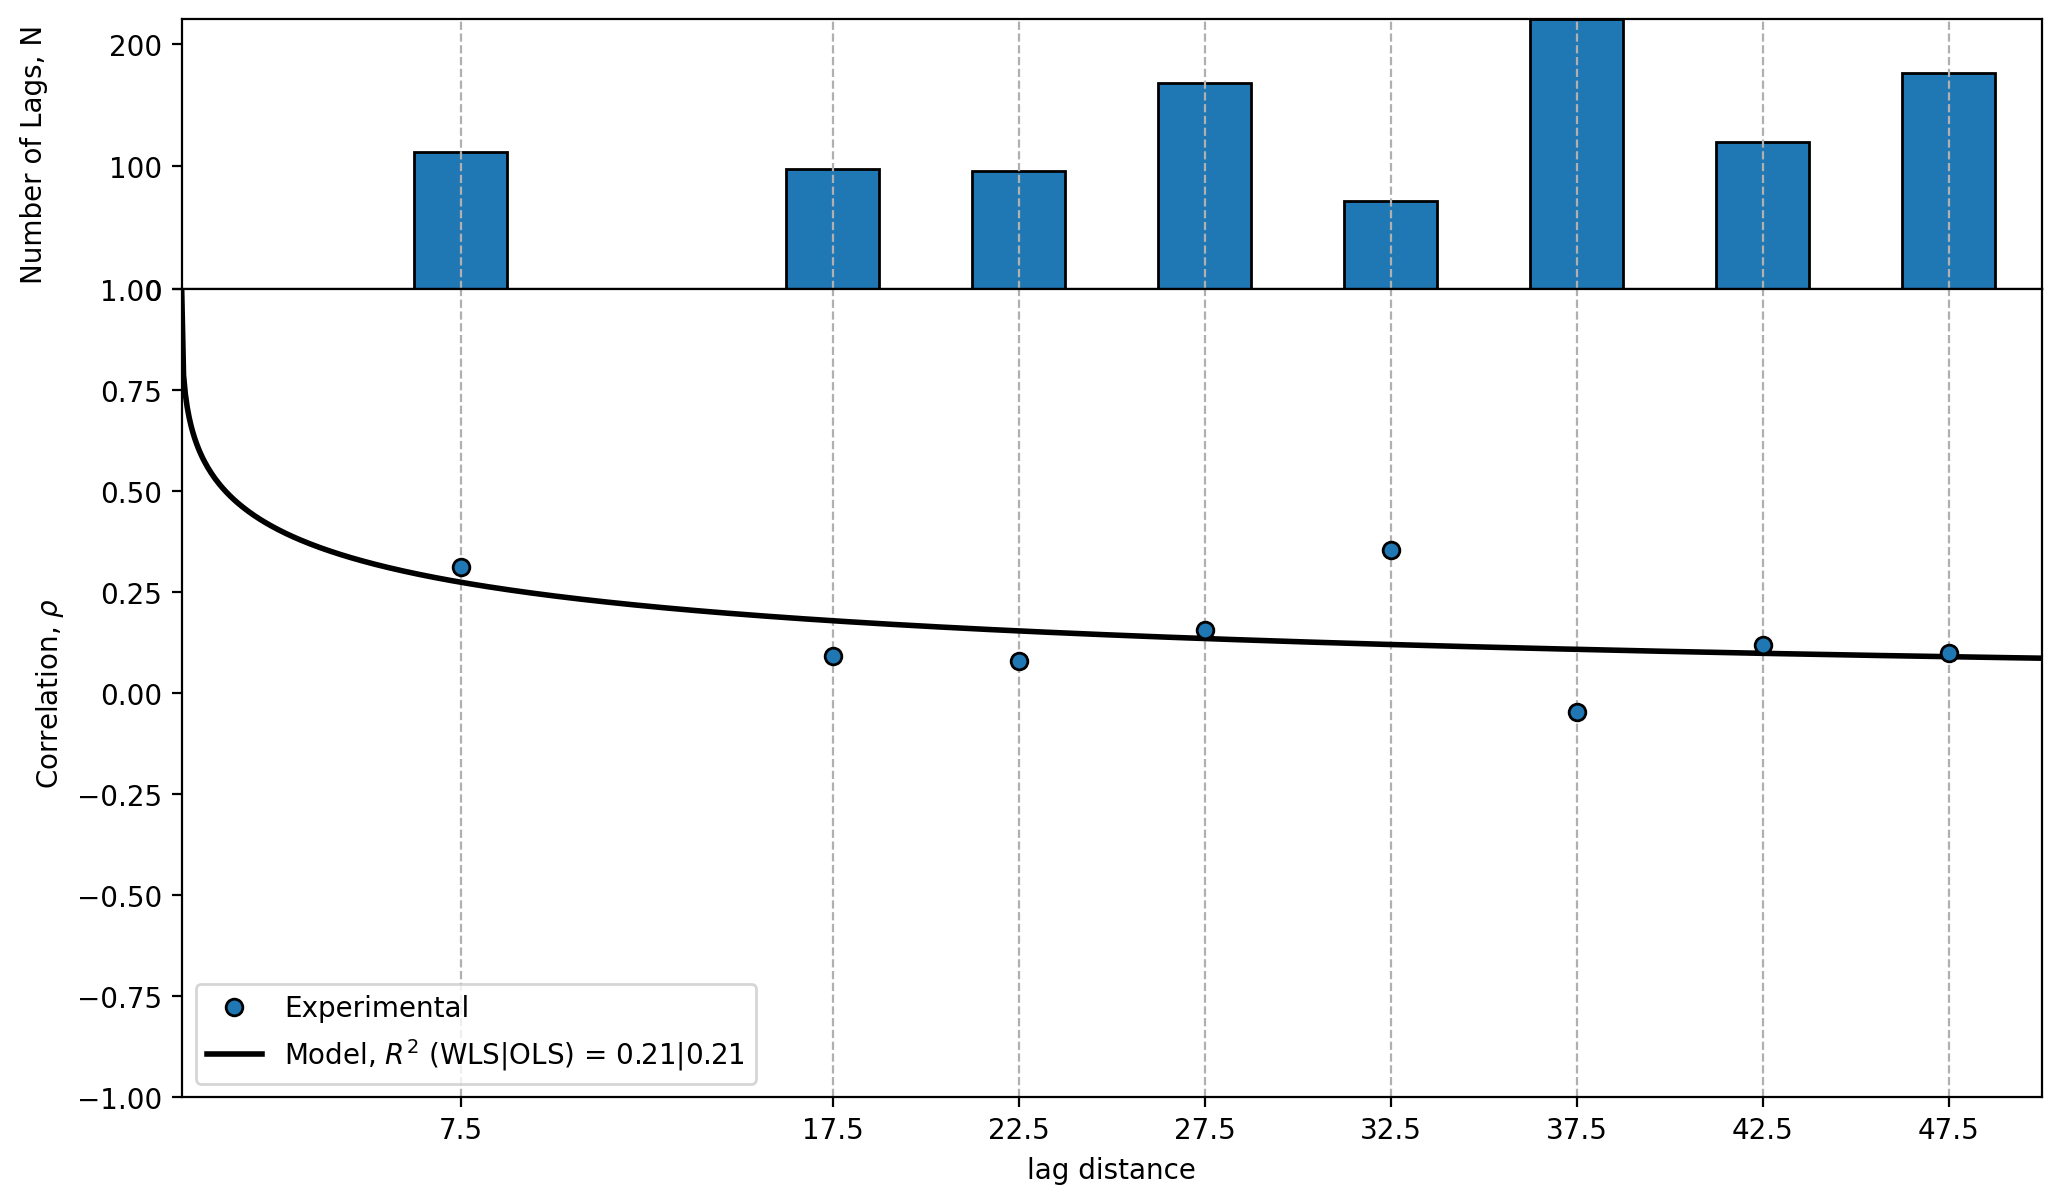

In [12]:
# get correlation between primary and secondary variables
rho0_target = estimate_collocated_correlation(
    datafl["Primary"].to_numpy(),
    datafl["Secondary"].to_numpy(),
    method="pearson",
)

# Collocated sample pairs at primary locations
z_pair = datafl["Primary"].to_numpy(dtype=float)
y_pair = datafl["Secondary"].to_numpy(dtype=float)
xy_pair = datafl[["X", "Y"]].to_numpy()

# Standardize using one consistent reference
mu_z = z_pair.mean()
sd_z = z_pair.std(ddof=1)
mu_y = y_pair.mean()
sd_y = y_pair.std(ddof=1)

z_std = (z_pair - mu_z) / sd_z
y_std = (y_pair - mu_y) / sd_y

# MM2 residual variable
r_mm2 = (z_std - rho0_target * y_std) / np.sqrt(1.0 - rho0_target**2)


# Fit direct correlogram model for the residual variable
h_lag_resid, n_obs_resid, rho_resid_emp, params_resid, r2_wls_resid, r2_ols_resid = variofit(
    values=r_mm2,
    coordinates=xy_pair,
    distance_type="cartesian",
    max_distance=50,
    bin_size=5,
    estimator_type=estimator,
    model_type=model,
    weight_fn=weight_fn,
    weight_params=weight_params,
    xmax_factor=xmax_factor,
    fix_sill=True,
    plot=True,
    transform="correlation",
)

## 3.2 Build covariance models

In [13]:
# make models from correlograms
primary_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_primary,
)

secondary_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_secondary,
)

residual_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_resid,
)

rho0_target = estimate_collocated_correlation(
    datafl["Primary"].to_numpy(),
    datafl["Secondary"].to_numpy(),
    method="pearson",
)

print("rho0_target =", rho0_target)

rho0_target = 0.7197391780935076


## 3.3 Run Simple Co-located Cokriging

### 3.3.1 Case 0: No azimuth rotation

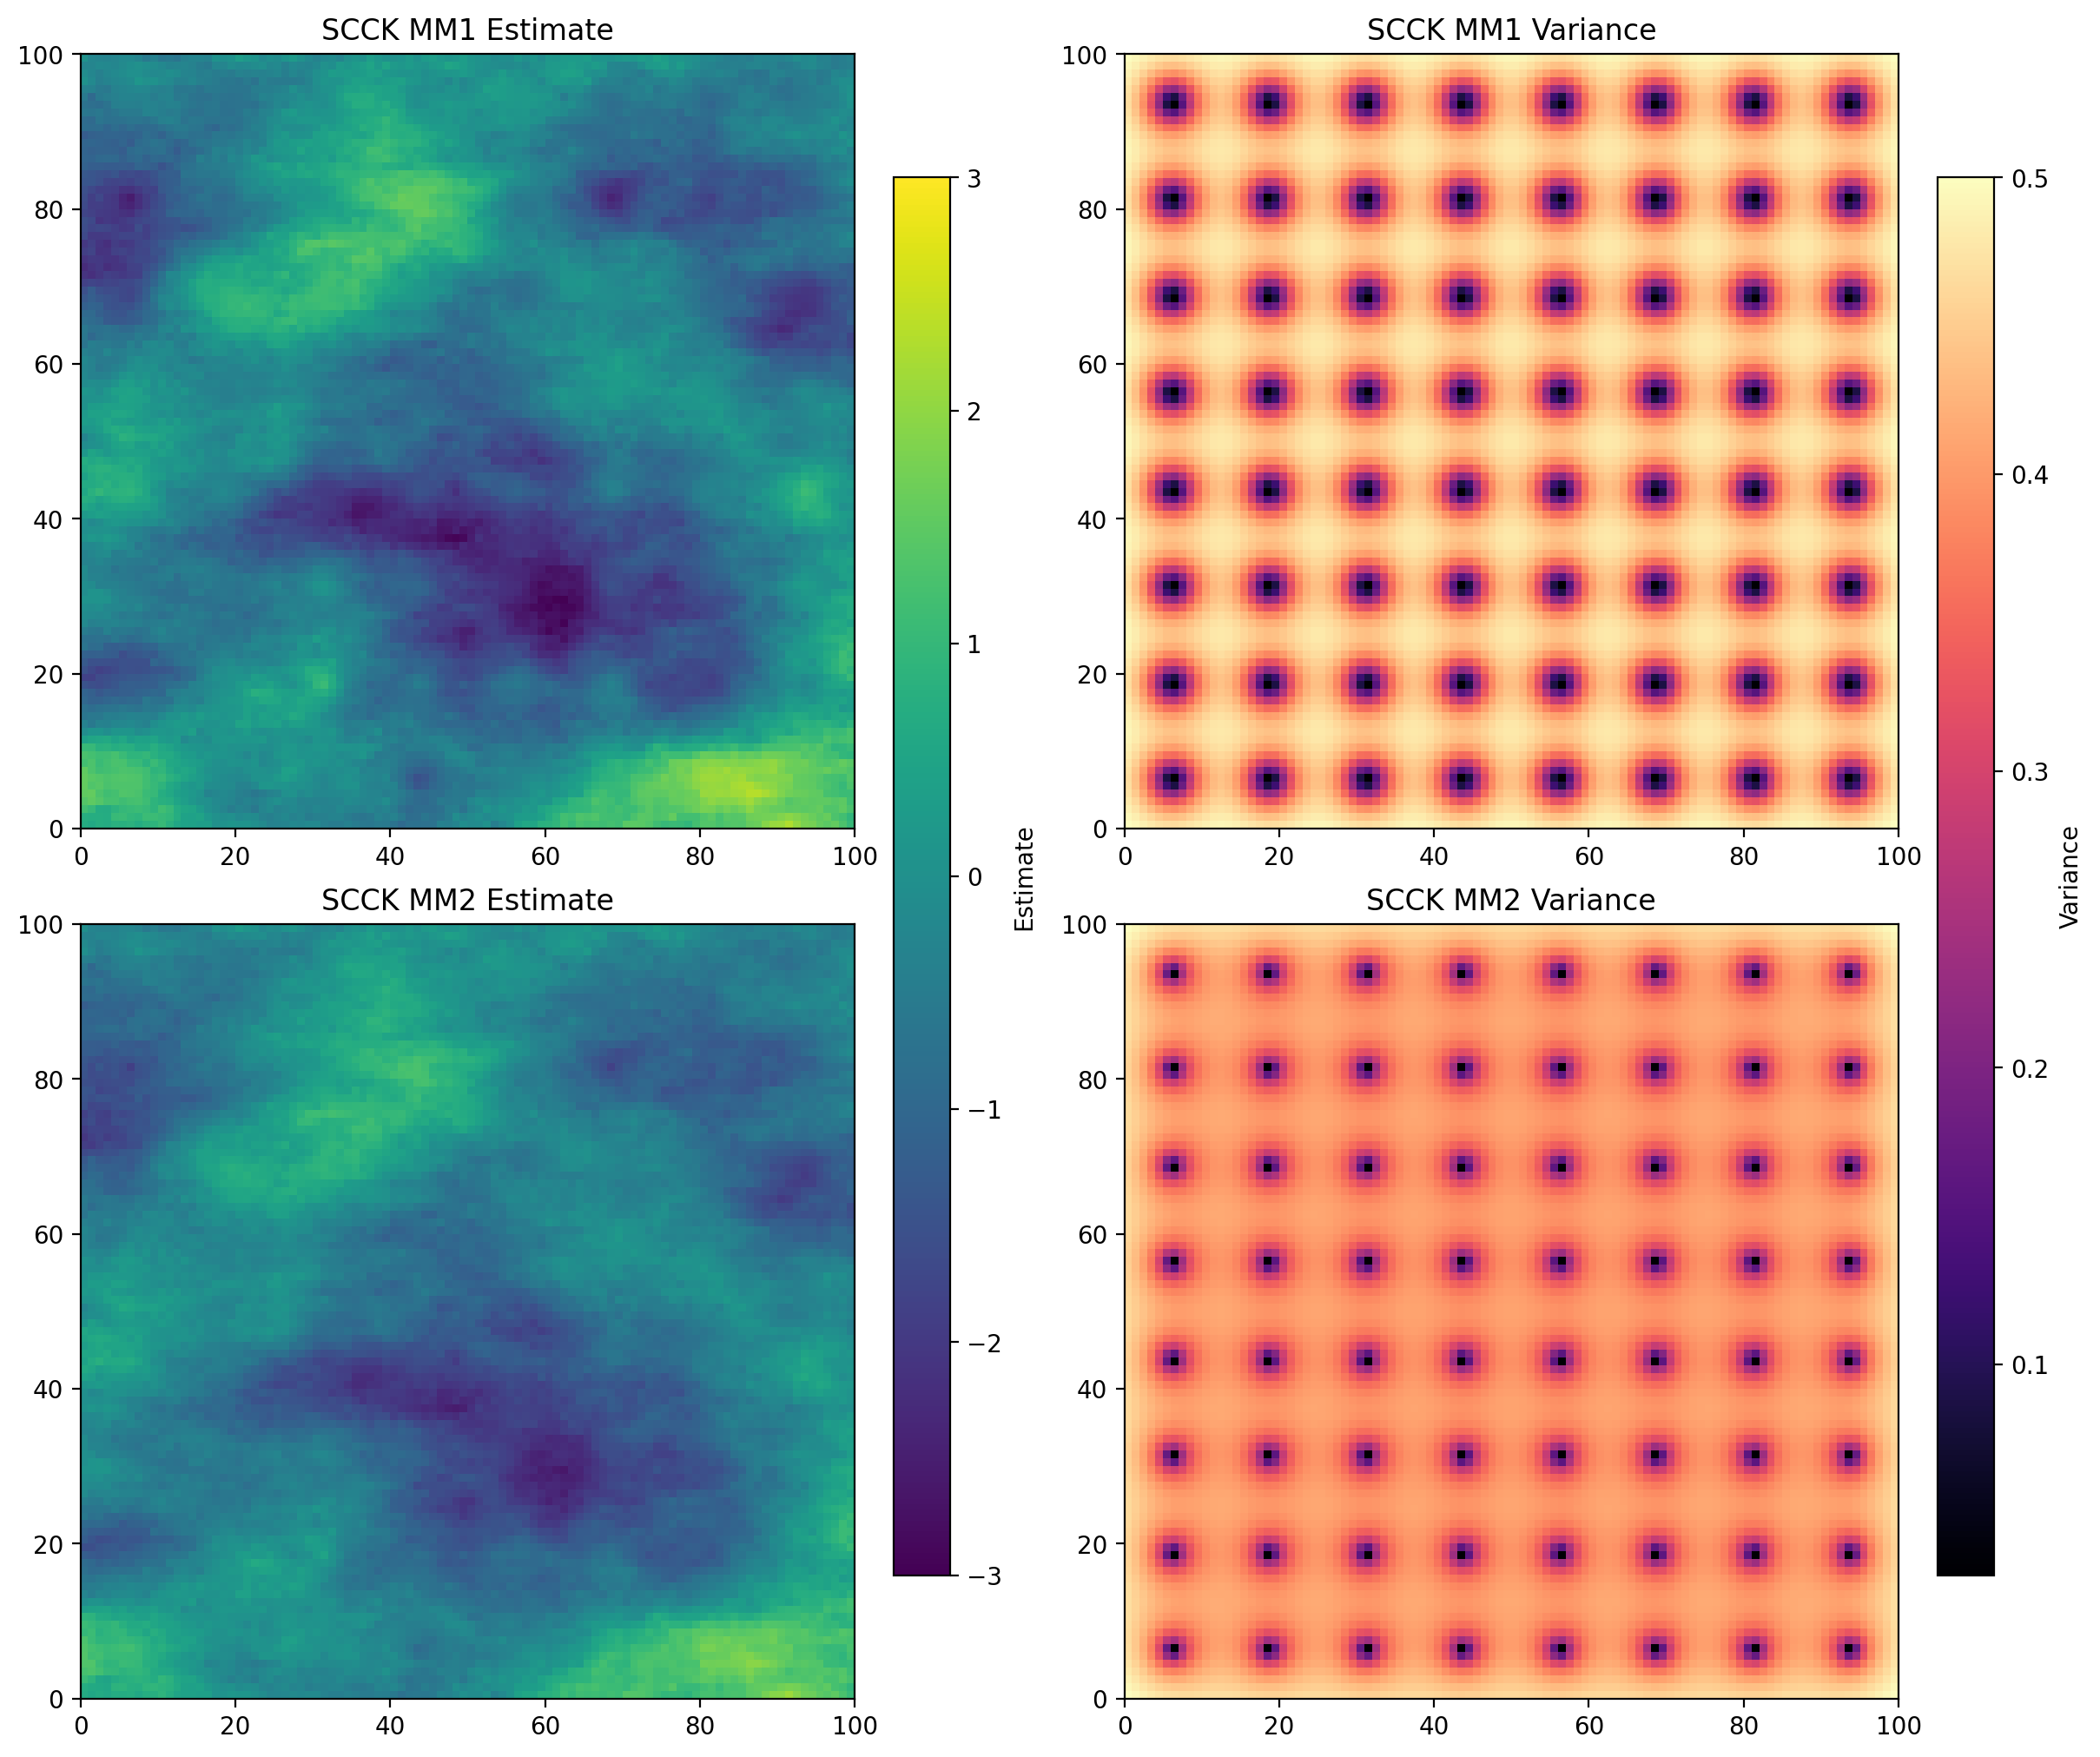

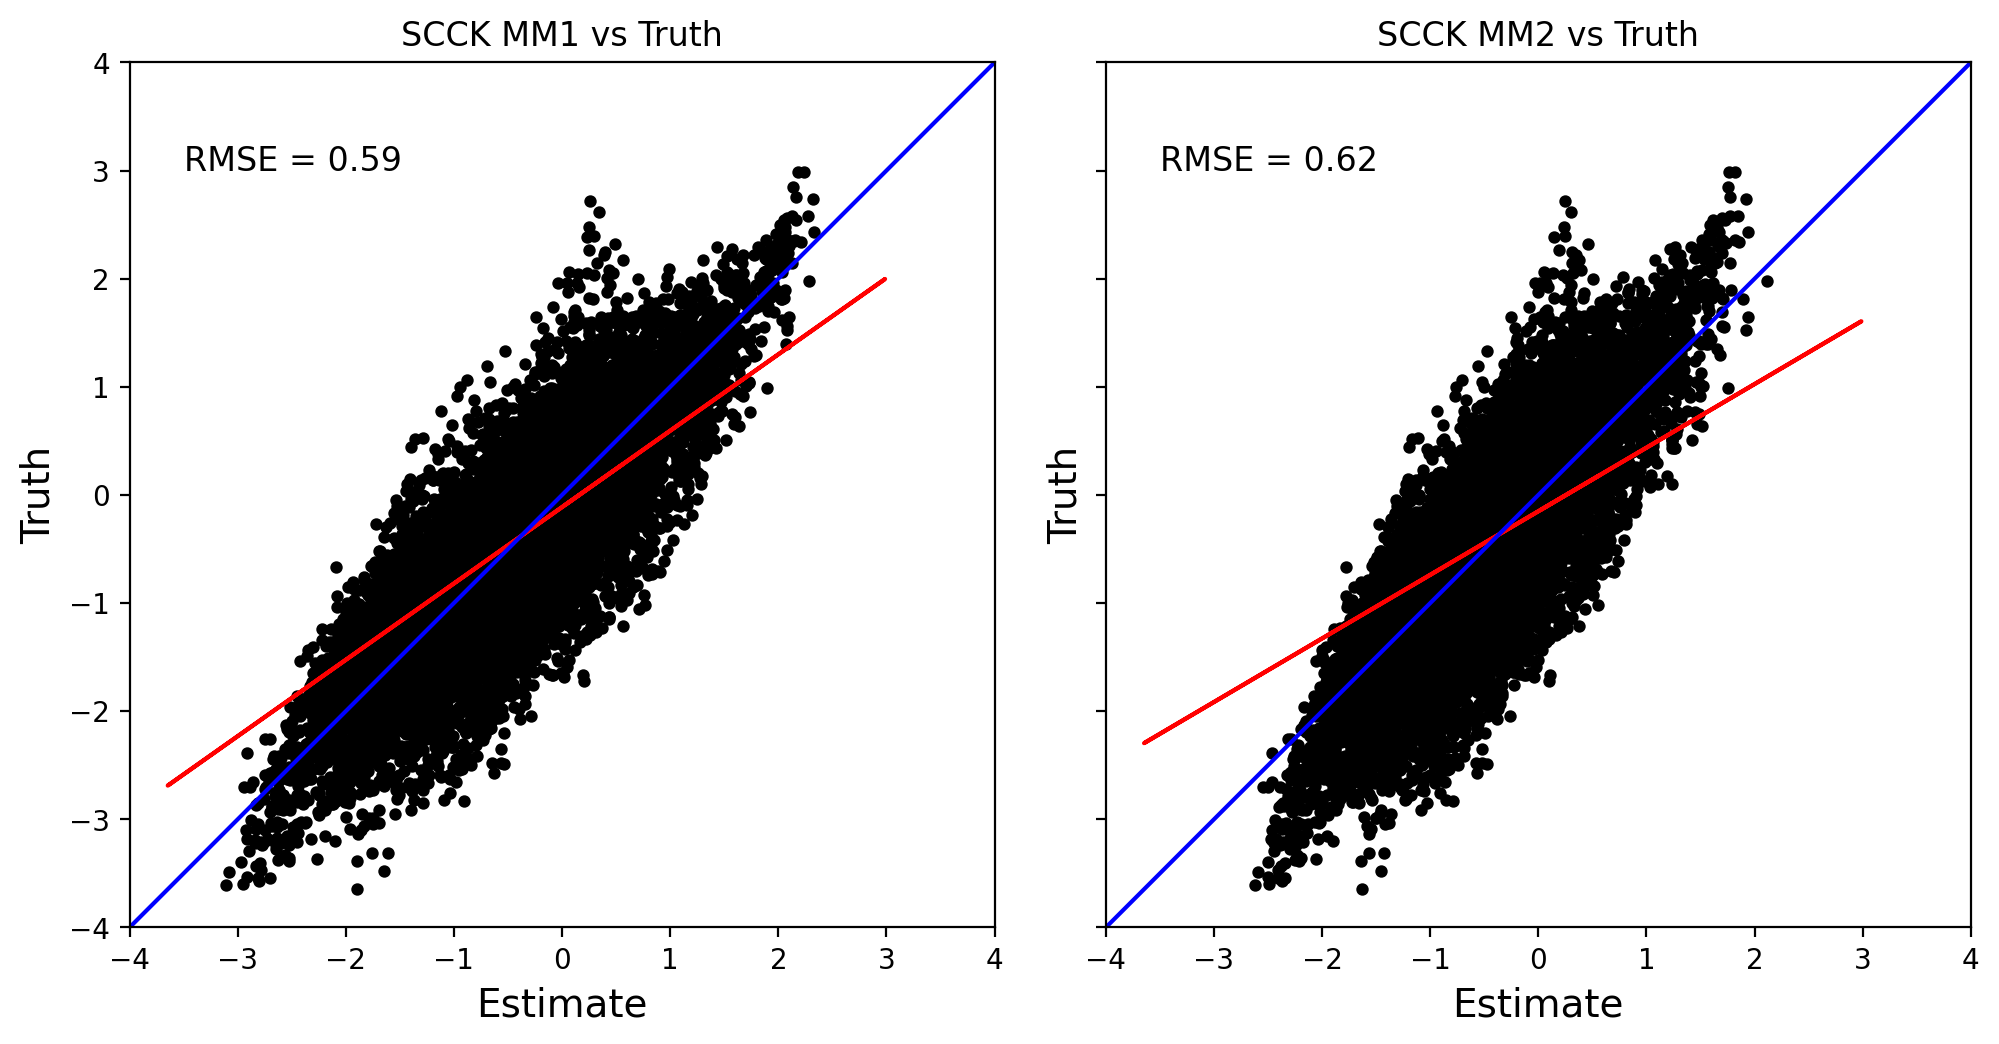

In [14]:
# MM1
est_mm1, var_mm1, wz_mm1, wy0_mm1 = SCCK_MM1(
    primary_values=datafl["Primary"].to_numpy(),
    primary_coords=datafl[["X", "Y"]].to_numpy(),
    collocated_secondary_values=datafl_sec["Secondary"].to_numpy(),
    targets=datafl_sec[["X", "Y"]].to_numpy(),
    rho0=rho0_target,
    primary_model=primary_model,
    secondary_values_for_standardization=datafl["Secondary"].to_numpy(),
    distance_type="cartesian",
    rotation_matrix=None,
    standardize=True,
    jitter=1e-10,
    check_positive_definite=True,
    return_weights=True,
    show_progress=False,
)

# MM2
est_mm2, var_mm2, wz_mm2, wy0_mm2 = SCCK_MM2(
    primary_values=datafl["Primary"].to_numpy(),
    primary_coords=datafl[["X", "Y"]].to_numpy(),
    collocated_secondary_values=datafl_sec["Secondary"].to_numpy(),
    targets=datafl_sec[["X", "Y"]].to_numpy(),
    rho0=rho0_target,
    secondary_model=secondary_model,
    residual_model=residual_model,
    secondary_values_for_standardization=datafl["Secondary"].to_numpy(),
    distance_type="cartesian",
    rotation_matrix=None,
    standardize=True,
    jitter=1e-10,
    check_positive_definite=True,
    return_weights=True,
    show_progress=False,
)

# plotting
rmse_mm1 = np.sqrt(mean_squared_error(truth["Primary"], est_mm1))
rmse_mm2 = np.sqrt(mean_squared_error(truth["Primary"], est_mm2))

nx = len(np.unique(datafl_sec["X"]))
ny = len(np.unique(datafl_sec["Y"]))

X = datafl_sec["X"].to_numpy().reshape(ny, nx)
Y = datafl_sec["Y"].to_numpy().reshape(ny, nx)

EST_mm1 = est_mm1.reshape(ny, nx)
VAR_mm1 = var_mm1.reshape(ny, nx)

EST_mm2 = est_mm2.reshape(ny, nx)
VAR_mm2 = var_mm2.reshape(ny, nx)

# Figure 1: maps with MM1 on top and MM2 below
fig, ax = plt.subplots(2, 2, figsize=(12, 10), dpi=200, constrained_layout=True)
im00 = ax[0, 0].pcolormesh(X, Y, EST_mm1, cmap="viridis", shading="auto", vmin=-3, vmax=3)
ax[0, 0].set_title(f"SCCK MM1 Estimate")
ax[0, 0].set_aspect("equal")
im01 = ax[0, 1].pcolormesh(X, Y, VAR_mm1, cmap="magma", shading="auto")
ax[0, 1].set_title(f"SCCK MM1 Variance")
ax[0, 1].set_aspect("equal")
im10 = ax[1, 0].pcolormesh(X, Y, EST_mm2, cmap="viridis", shading="auto", vmin=-3, vmax=3)
ax[1, 0].set_title(f"SCCK MM2 Estimate")
ax[1, 0].set_aspect("equal")
im11 = ax[1, 1].pcolormesh(X, Y, VAR_mm2, cmap="magma", shading="auto")
ax[1, 1].set_title(f"SCCK MM2 Variance")
ax[1, 1].set_aspect("equal")
fig.colorbar(im00, ax=ax[:, 0], label="Estimate", aspect=25, shrink=0.85, pad=0.02)
fig.colorbar(im01, ax=ax[:, 1], label="Variance", aspect=25, shrink=0.85, pad=0.02)
plt.show()

# Figure 2: MM1 and MM2 RMSE scatter plots
fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=200, constrained_layout=True, sharex=True, sharey=True)

# MM1
ax[0].scatter(est_mm1, truth["Primary"], color="black", s=12)
ax[0].plot(
    truth["Primary"],
    np.poly1d(np.polyfit(truth["Primary"], est_mm1, 1))(truth["Primary"]),
    color="red",
)
ax[0].set_xlim(-4, 4)
ax[0].set_ylim(-4, 4)
x_45 = np.linspace(-4, 4, 200)
ax[0].plot(x_45, x_45, color="blue")
ax[0].set_xlabel("Estimate", size=14)
ax[0].set_ylabel("Truth", size=14)
ax[0].set_aspect("equal", "box")
ax[0].text(-3.5, 3.0, f"RMSE = {rmse_mm1:.2f}", fontsize=12)
ax[0].set_title("SCCK MM1 vs Truth")

# MM2
ax[1].scatter(est_mm2, truth["Primary"], color="black", s=12)
ax[1].plot(
    truth["Primary"],
    np.poly1d(np.polyfit(truth["Primary"], est_mm2, 1))(truth["Primary"]),
    color="red",
)
ax[1].plot(x_45, x_45, color="blue")
ax[1].set_xlim(-4, 4)
ax[1].set_ylim(-4, 4)
ax[1].set_xlabel("Estimate", size=14)
ax[1].set_ylabel("Truth", size=14)
ax[1].set_aspect("equal", "box")
ax[1].text(-3.5, 3.0, f"RMSE = {rmse_mm2:.2f}", fontsize=12)
ax[1].set_title("SCCK MM2 vs Truth")

plt.show()

### 3.3.2 Case 1: Azimuth rotation

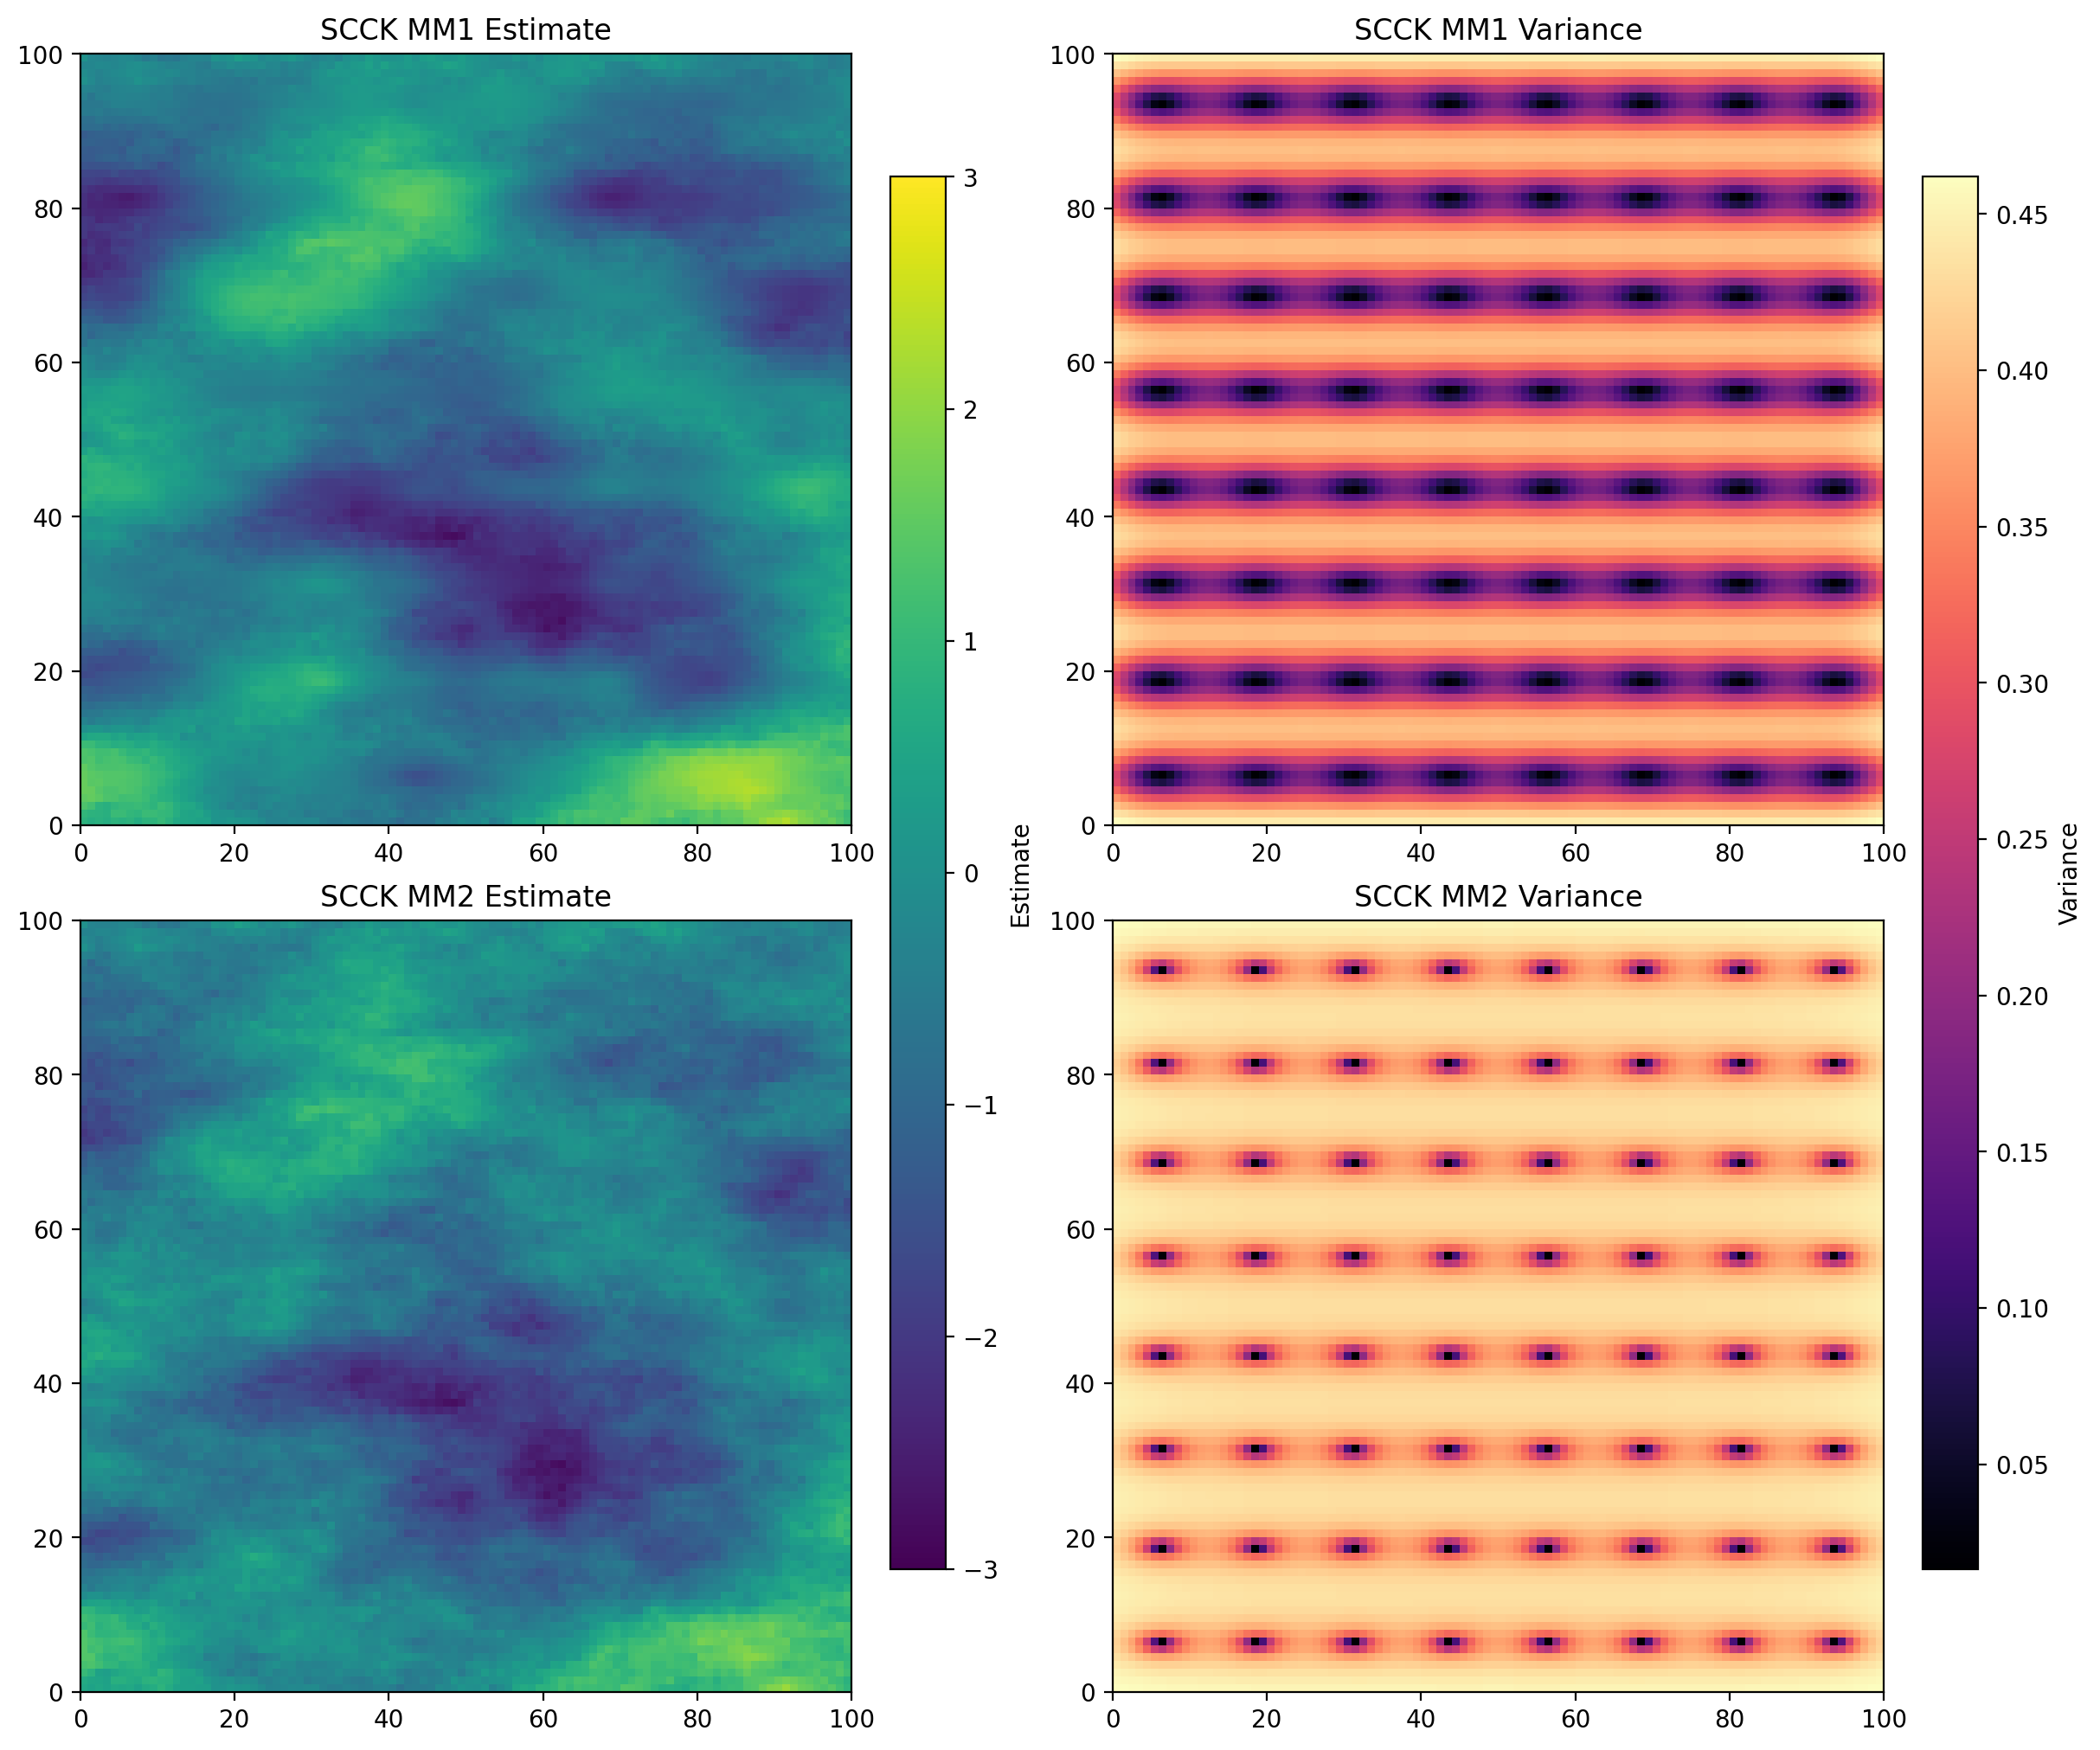

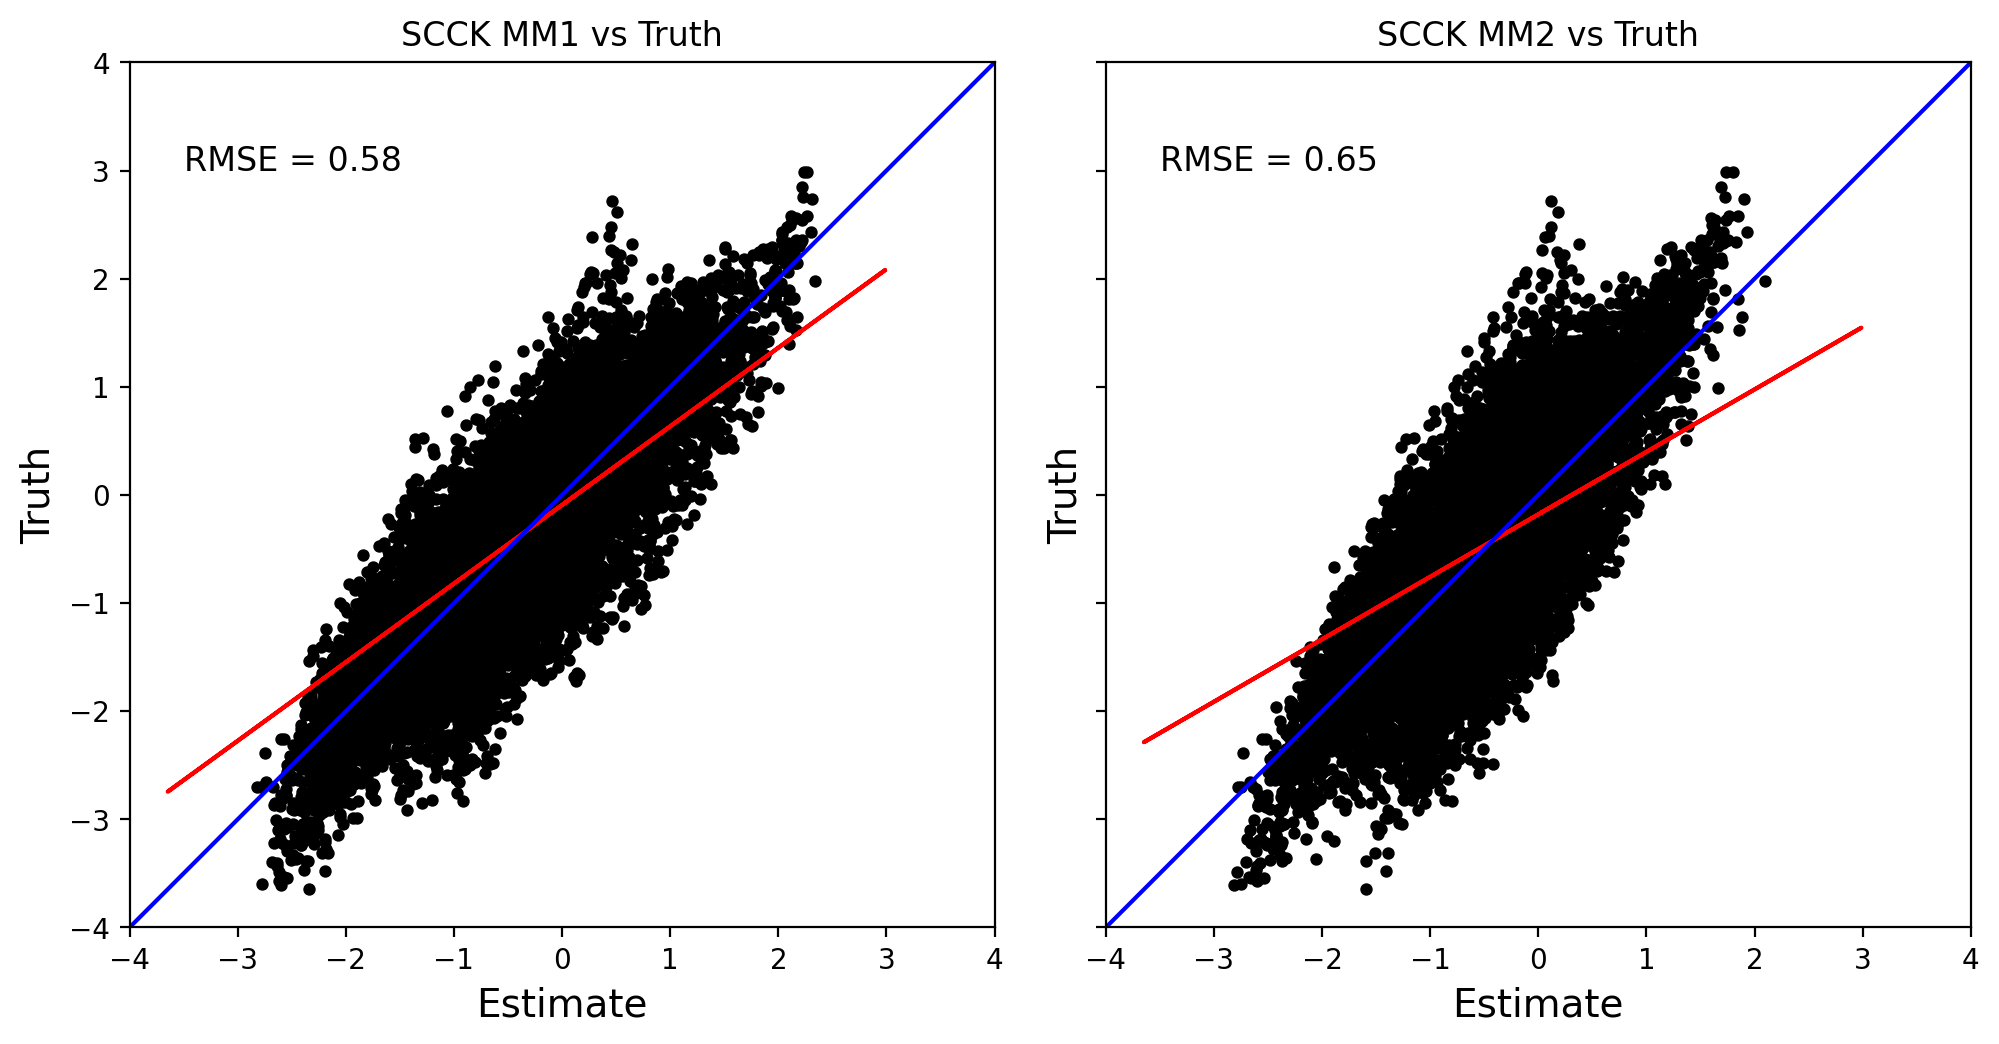

In [15]:
rotation_matrix = {"azimuth": 90.0, "a_max": 33.0, "a_min": 15.0}

# MM1
est_mm1, var_mm1, wz_mm1, wy0_mm1 = SCCK_MM1(
    primary_values=datafl["Primary"].to_numpy(),
    primary_coords=datafl[["X", "Y"]].to_numpy(),
    collocated_secondary_values=datafl_sec["Secondary"].to_numpy(),
    targets=datafl_sec[["X", "Y"]].to_numpy(),
    rho0=rho0_target,
    primary_model=primary_model,
    secondary_values_for_standardization=datafl["Secondary"].to_numpy(),
    distance_type="cartesian",
    rotation_matrix=rotation_matrix,
    standardize=True,
    jitter=1e-10,
    check_positive_definite=True,
    return_weights=True,
    show_progress=False,
)

# MM2
est_mm2, var_mm2, wz_mm2, wy0_mm2 = SCCK_MM2(
    primary_values=datafl["Primary"].to_numpy(),
    primary_coords=datafl[["X", "Y"]].to_numpy(),
    collocated_secondary_values=datafl_sec["Secondary"].to_numpy(),
    targets=datafl_sec[["X", "Y"]].to_numpy(),
    rho0=rho0_target,
    secondary_model=secondary_model,
    residual_model=residual_model,
    secondary_values_for_standardization=datafl["Secondary"].to_numpy(),
    distance_type="cartesian",
    rotation_matrix=rotation_matrix,
    standardize=True,
    jitter=1e-10,
    check_positive_definite=True,
    return_weights=True,
    show_progress=False,
)

# plotting
rmse_mm1 = np.sqrt(mean_squared_error(truth["Primary"], est_mm1))
rmse_mm2 = np.sqrt(mean_squared_error(truth["Primary"], est_mm2))

nx = len(np.unique(datafl_sec["X"]))
ny = len(np.unique(datafl_sec["Y"]))

X = datafl_sec["X"].to_numpy().reshape(ny, nx)
Y = datafl_sec["Y"].to_numpy().reshape(ny, nx)

EST_mm1 = est_mm1.reshape(ny, nx)
VAR_mm1 = var_mm1.reshape(ny, nx)

EST_mm2 = est_mm2.reshape(ny, nx)
VAR_mm2 = var_mm2.reshape(ny, nx)

# Figure 1: maps with MM1 on top and MM2 below
fig, ax = plt.subplots(2, 2, figsize=(12, 10), dpi=200, constrained_layout=True)
im00 = ax[0, 0].pcolormesh(X, Y, EST_mm1, cmap="viridis", shading="auto", vmin=-3, vmax=3)
ax[0, 0].set_title(f"SCCK MM1 Estimate")
ax[0, 0].set_aspect("equal")
im01 = ax[0, 1].pcolormesh(X, Y, VAR_mm1, cmap="magma", shading="auto")
ax[0, 1].set_title(f"SCCK MM1 Variance")
ax[0, 1].set_aspect("equal")
im10 = ax[1, 0].pcolormesh(X, Y, EST_mm2, cmap="viridis", shading="auto", vmin=-3, vmax=3)
ax[1, 0].set_title(f"SCCK MM2 Estimate")
ax[1, 0].set_aspect("equal")
im11 = ax[1, 1].pcolormesh(X, Y, VAR_mm2, cmap="magma", shading="auto")
ax[1, 1].set_title(f"SCCK MM2 Variance")
ax[1, 1].set_aspect("equal")
fig.colorbar(im00, ax=ax[:, 0], label="Estimate", aspect=25, shrink=0.85, pad=0.02)
fig.colorbar(im01, ax=ax[:, 1], label="Variance", aspect=25, shrink=0.85, pad=0.02)
plt.show()

# Figure 2: MM1 and MM2 RMSE scatter plots
fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=200, constrained_layout=True, sharex=True, sharey=True)

# MM1
ax[0].scatter(est_mm1, truth["Primary"], color="black", s=12)
ax[0].plot(
    truth["Primary"],
    np.poly1d(np.polyfit(truth["Primary"], est_mm1, 1))(truth["Primary"]),
    color="red",
)
ax[0].set_xlim(-4, 4)
ax[0].set_ylim(-4, 4)
x_45 = np.linspace(-4, 4, 200)
ax[0].plot(x_45, x_45, color="blue")
ax[0].set_xlabel("Estimate", size=14)
ax[0].set_ylabel("Truth", size=14)
ax[0].set_aspect("equal", "box")
ax[0].text(-3.5, 3.0, f"RMSE = {rmse_mm1:.2f}", fontsize=12)
ax[0].set_title("SCCK MM1 vs Truth")

# MM2
ax[1].scatter(est_mm2, truth["Primary"], color="black", s=12)
ax[1].plot(
    truth["Primary"],
    np.poly1d(np.polyfit(truth["Primary"], est_mm2, 1))(truth["Primary"]),
    color="red",
)
ax[1].plot(x_45, x_45, color="blue")
ax[1].set_xlim(-4, 4)
ax[1].set_ylim(-4, 4)
ax[1].set_xlabel("Estimate", size=14)
ax[1].set_ylabel("Truth", size=14)
ax[1].set_aspect("equal", "box")
ax[1].text(-3.5, 3.0, f"RMSE = {rmse_mm2:.2f}", fontsize=12)
ax[1].set_title("SCCK MM2 vs Truth")

plt.show()

# 4.0 Example 3: Intrinsic Simple Co-located Cokriging Markov models

## 4.1 Make Residual correlograms

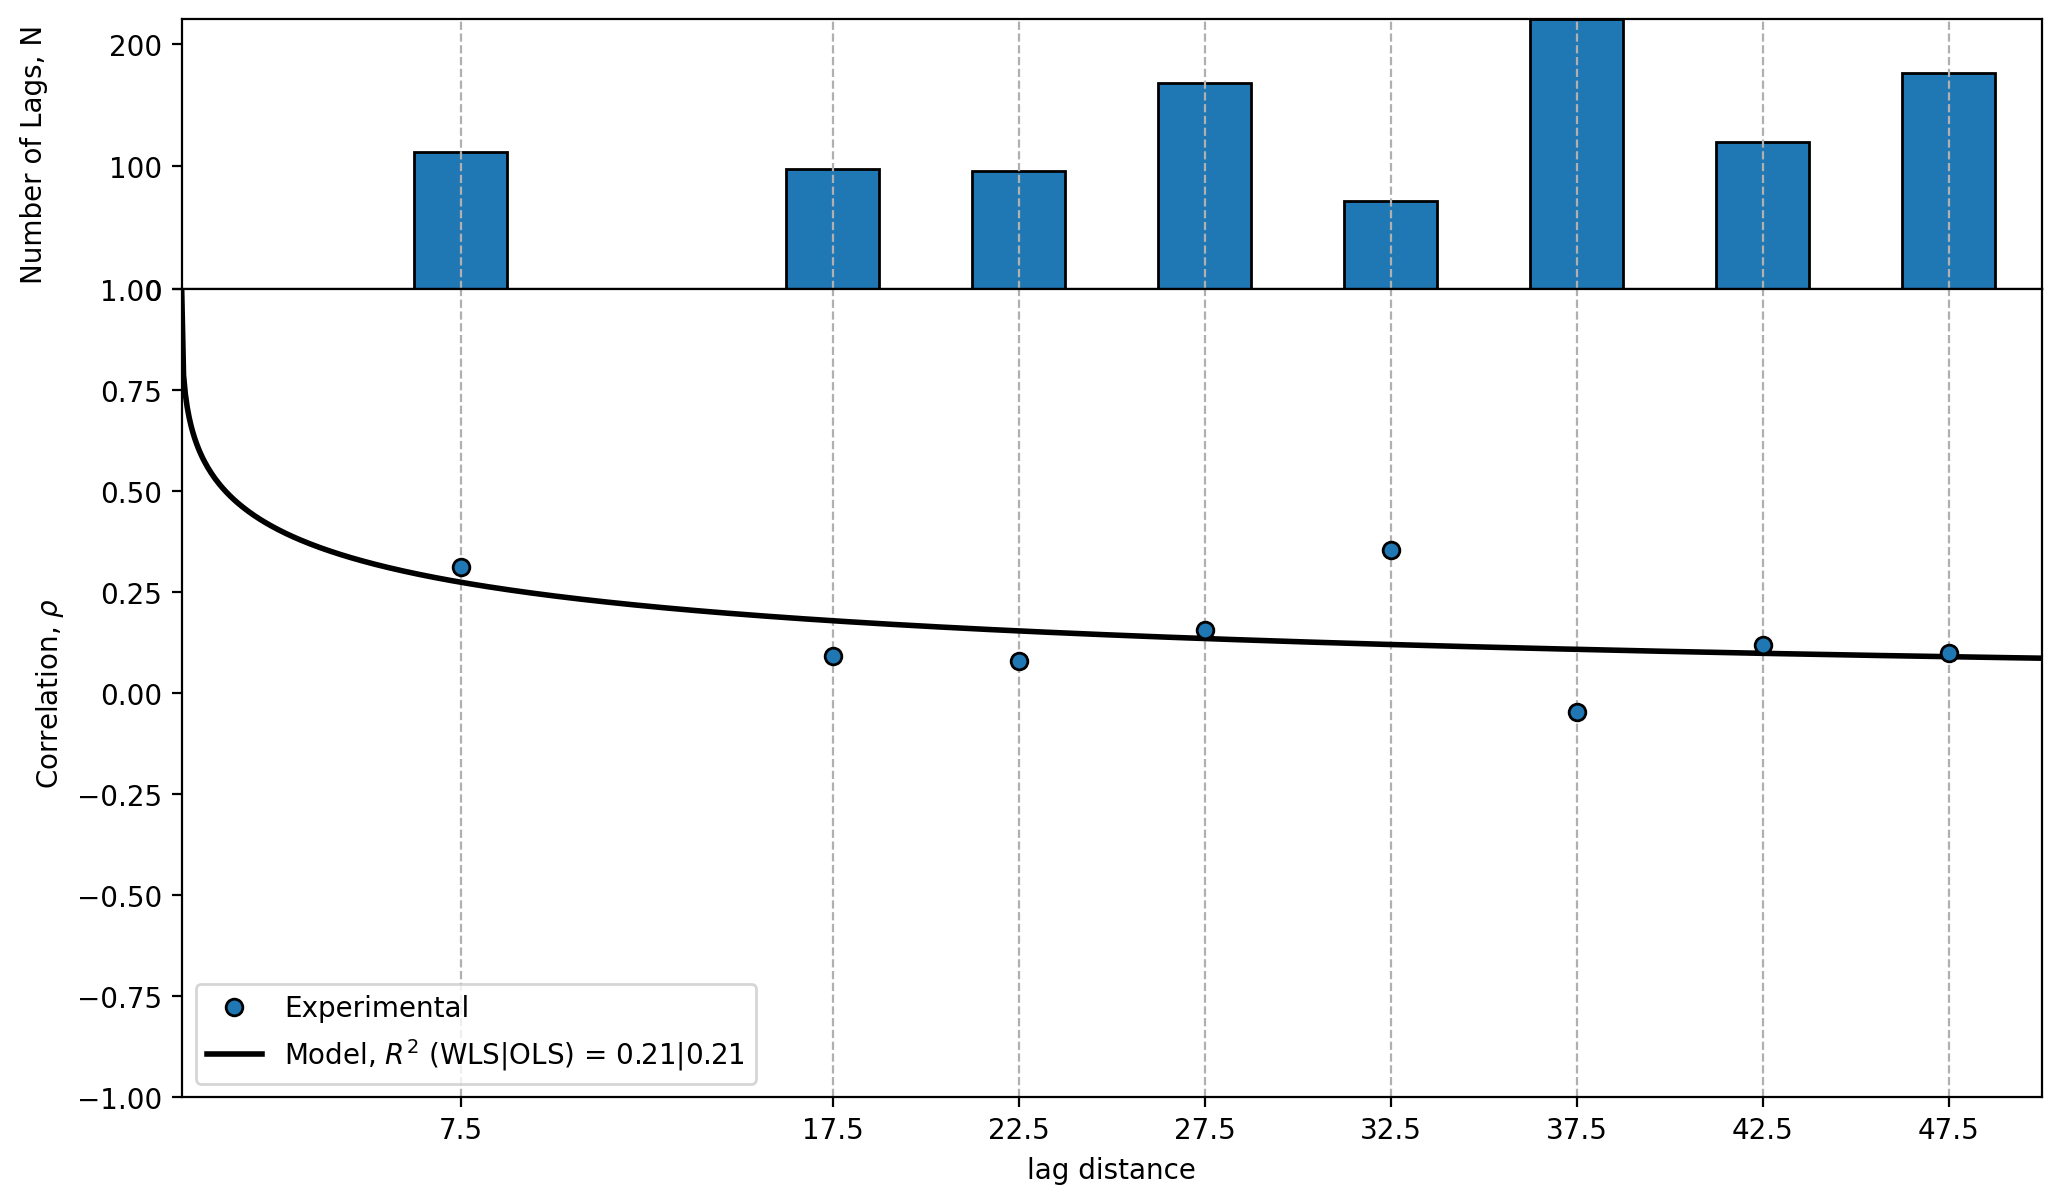

In [16]:
# get correlation between primary and secondary variables
rho0_target = estimate_collocated_correlation(
    datafl["Primary"].to_numpy(),
    datafl["Secondary"].to_numpy(),
    method="pearson",
)

# Collocated sample pairs at primary locations
z_pair = datafl["Primary"].to_numpy(dtype=float)
y_pair = datafl["Secondary"].to_numpy(dtype=float)
xy_pair = datafl[["X", "Y"]].to_numpy()

# Standardize using one consistent reference
mu_z = z_pair.mean()
sd_z = z_pair.std(ddof=1)
mu_y = y_pair.mean()
sd_y = y_pair.std(ddof=1)

z_std = (z_pair - mu_z) / sd_z
y_std = (y_pair - mu_y) / sd_y

# MM2 residual variable
r_mm2 = (z_std - rho0_target * y_std) / np.sqrt(1.0 - rho0_target**2)


# Fit direct correlogram model for the residual variable
h_lag_resid, n_obs_resid, rho_resid_emp, params_resid, r2_wls_resid, r2_ols_resid = variofit(
    values=r_mm2,
    coordinates=xy_pair,
    distance_type="cartesian",
    max_distance=50,
    bin_size=5,
    estimator_type=estimator,
    model_type=model,
    weight_fn=weight_fn,
    weight_params=weight_params,
    xmax_factor=xmax_factor,
    fix_sill=True,
    plot=True,
    transform="correlation",
)

## 4.2 Build covariance models

In [17]:
# make models from correlograms
primary_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_primary,
)

secondary_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_secondary,
)

residual_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_resid,
)

rho0_target = estimate_collocated_correlation(
    datafl["Primary"].to_numpy(),
    datafl["Secondary"].to_numpy(),
    method="pearson",
)

print("rho0_target =", rho0_target)

rho0_target = 0.7197391780935076


## 4.3 Run Intrinsic Simple Co-located Cokriging

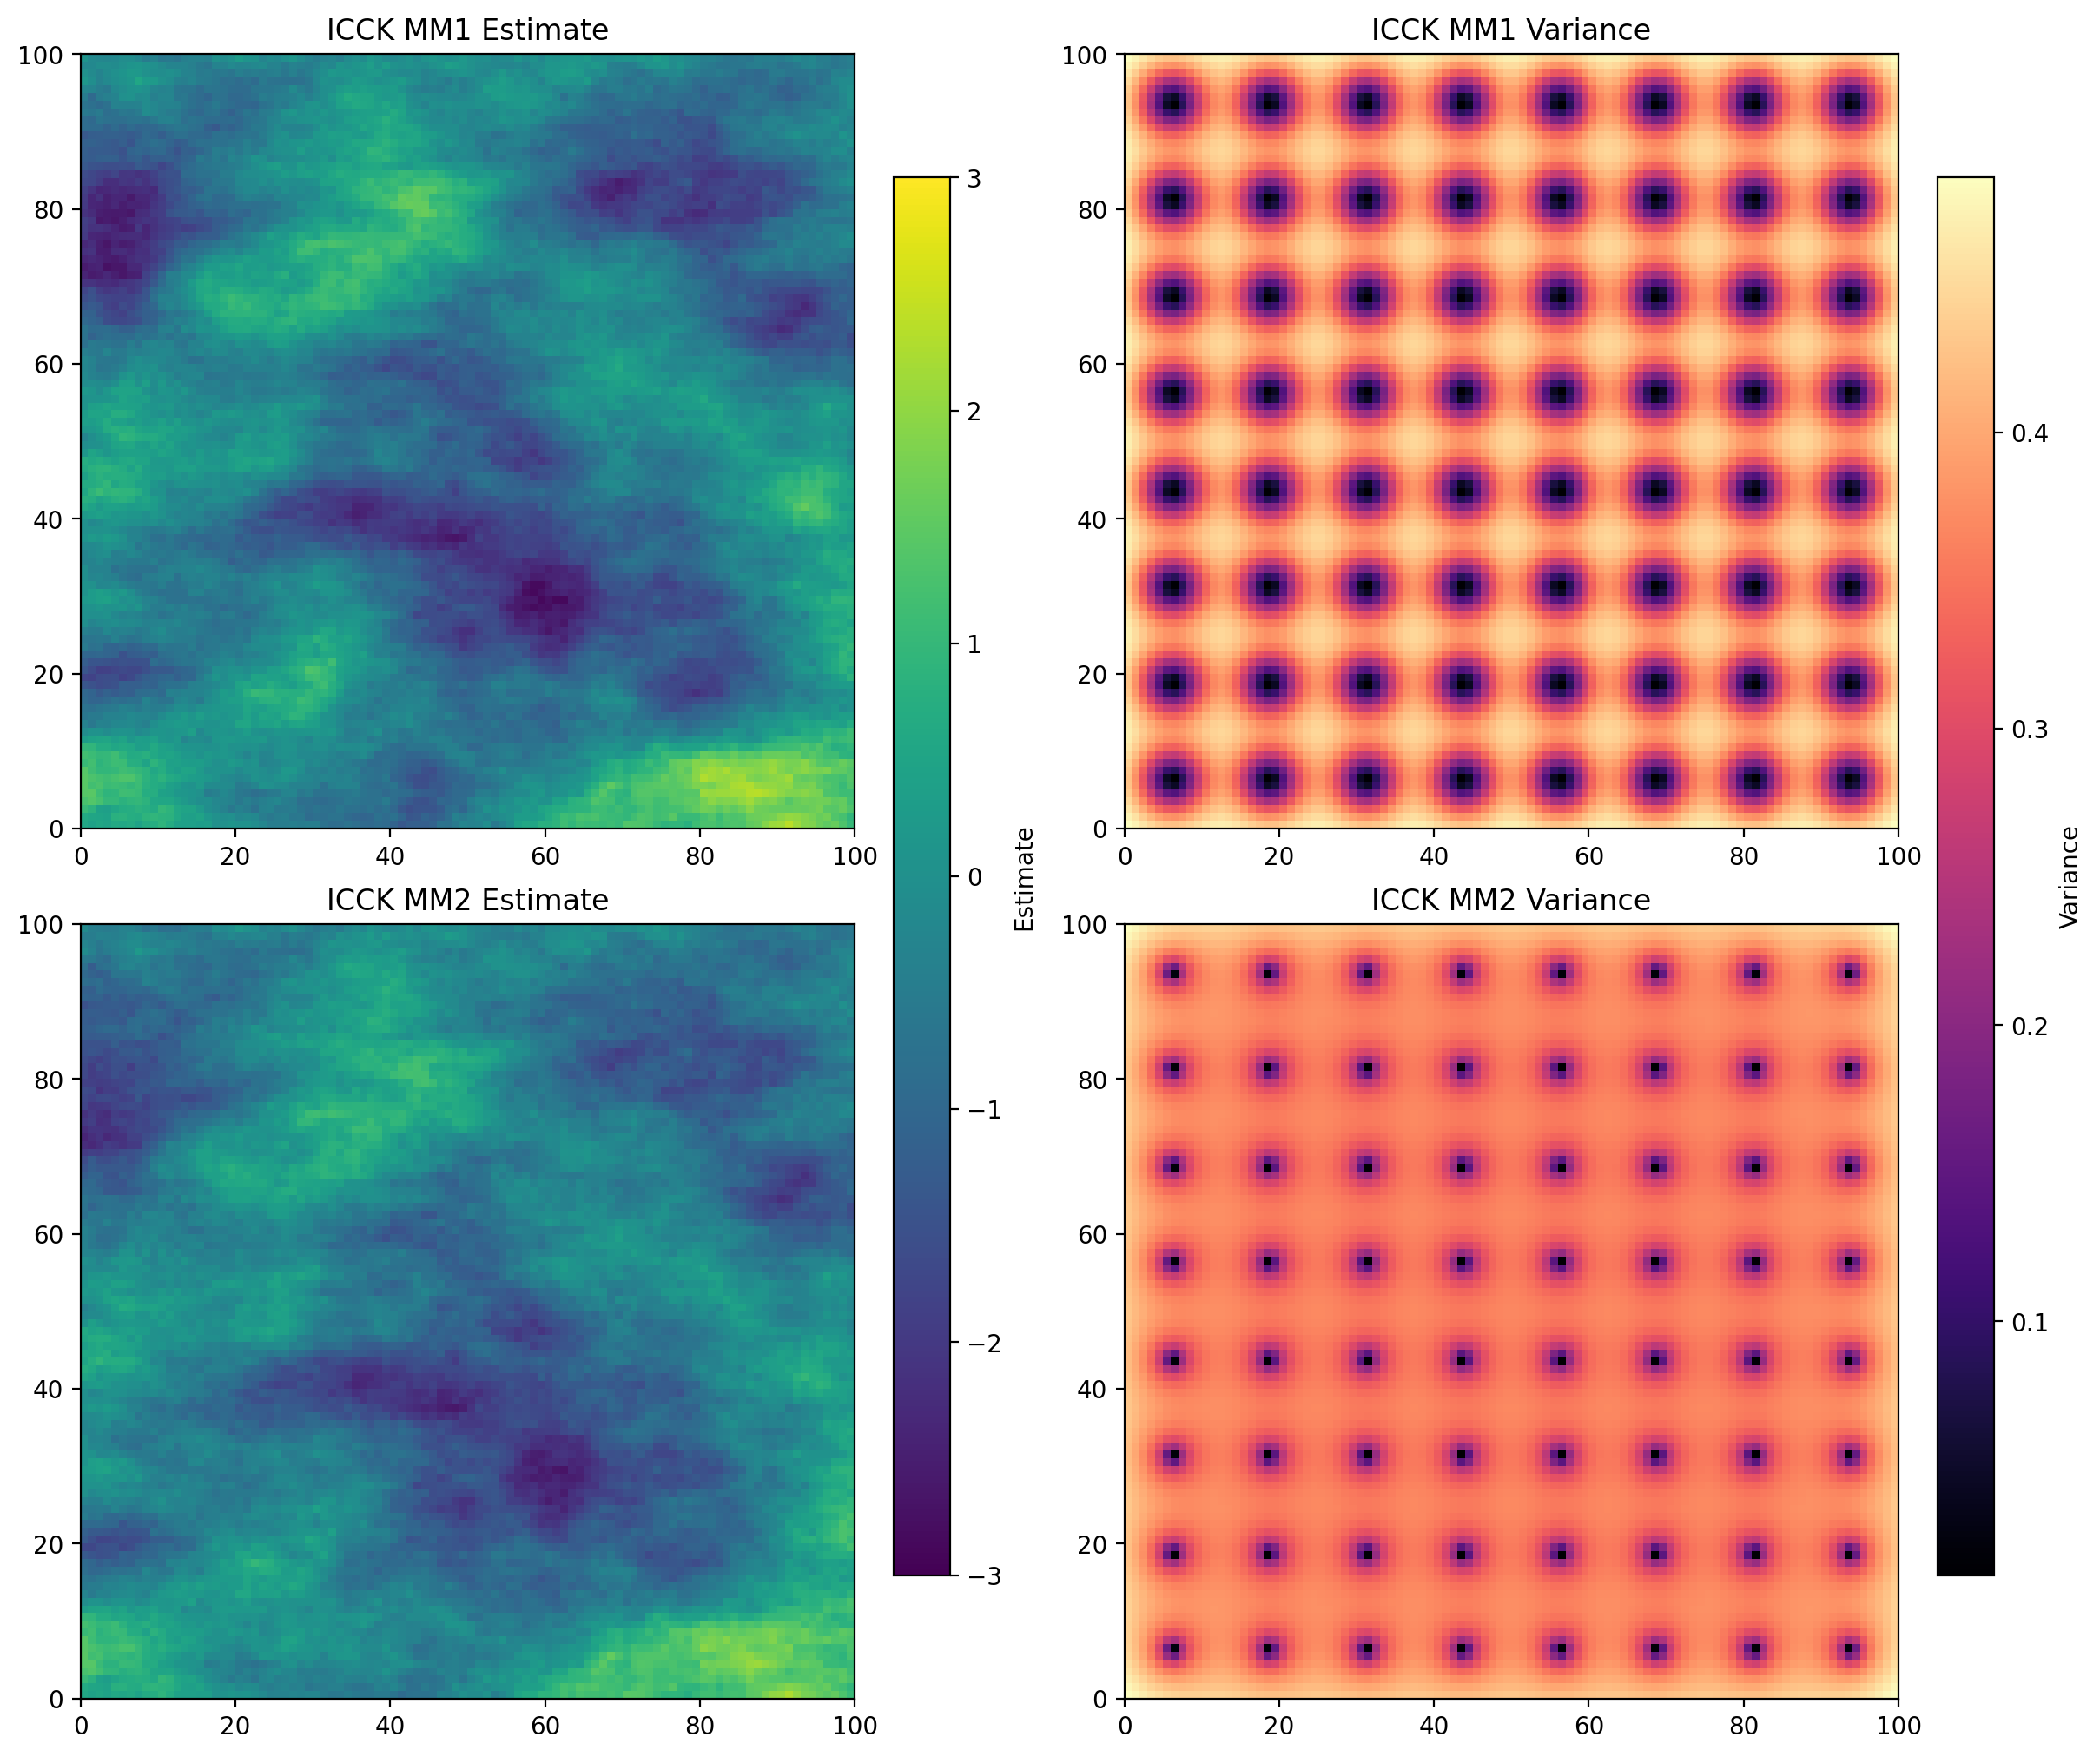

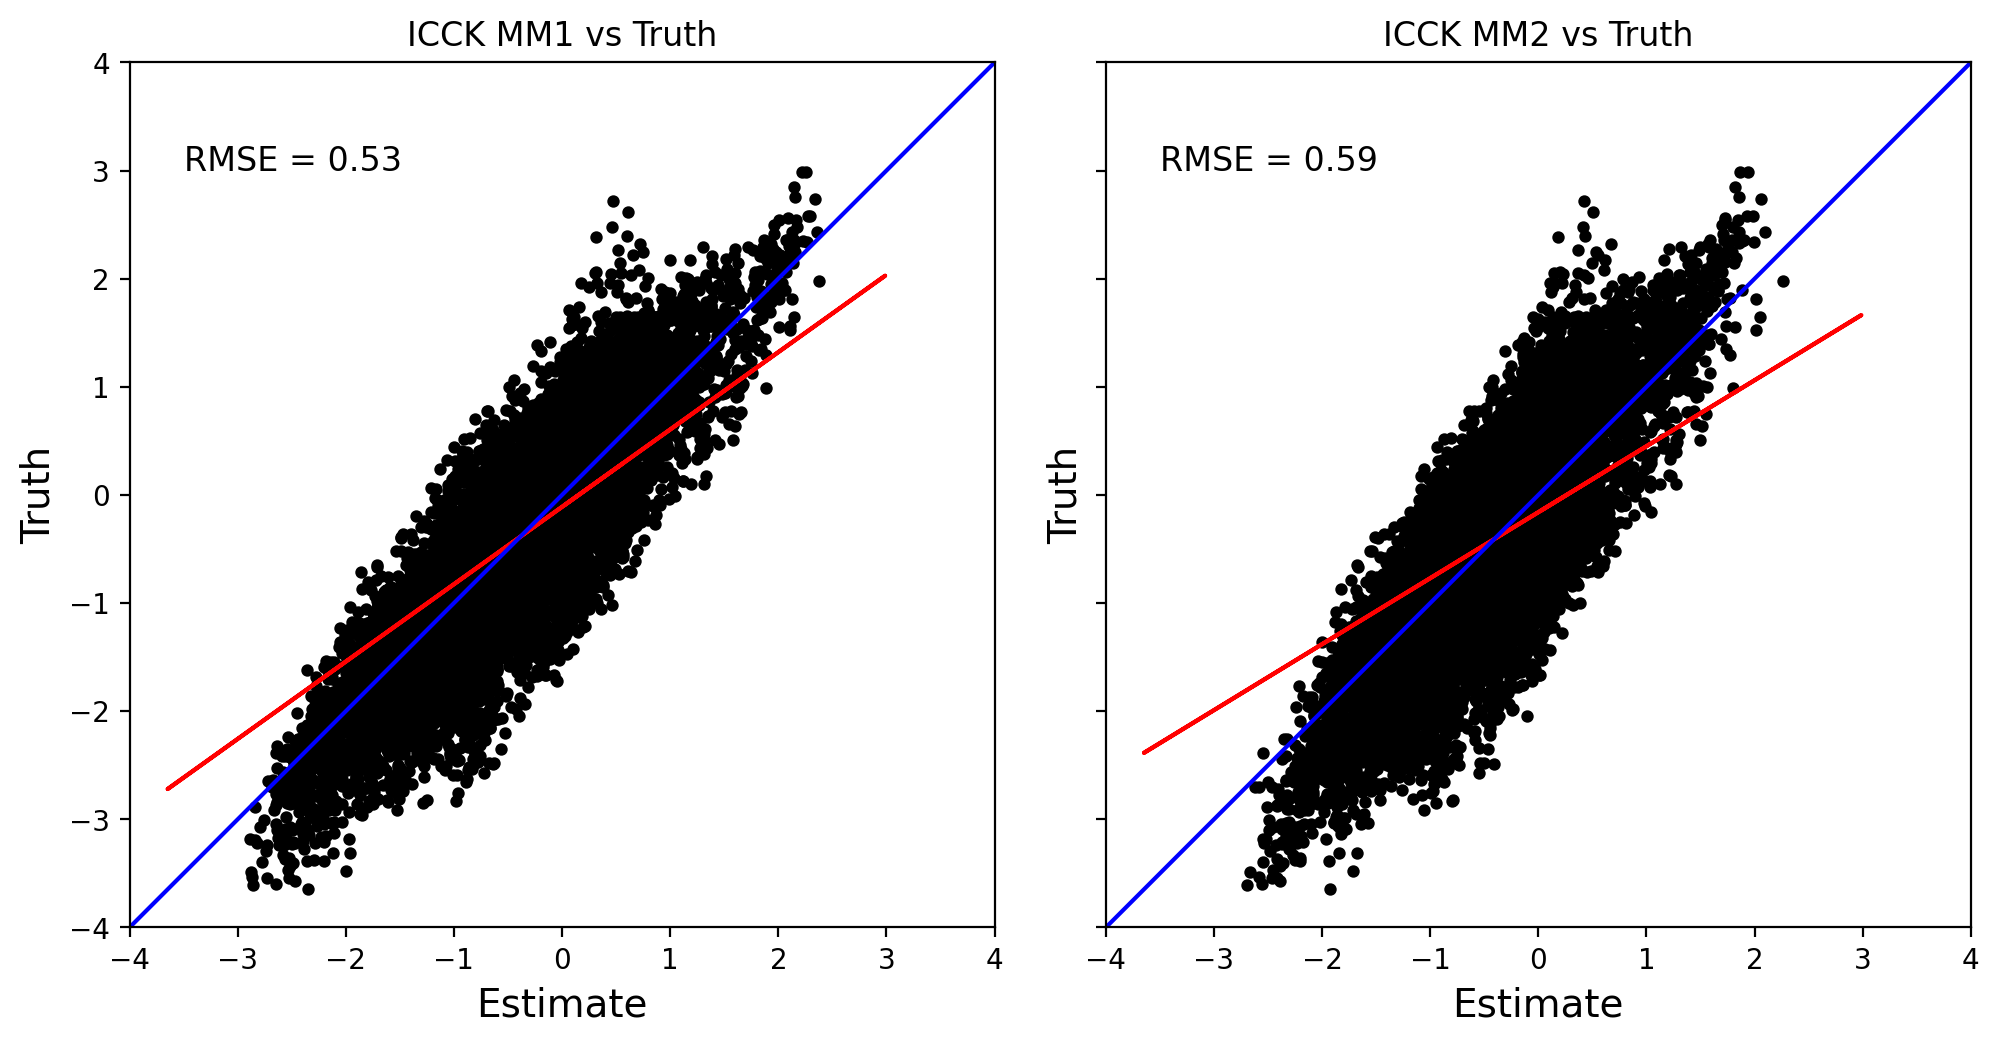

In [18]:
# ICCK MM1
est_mm1, var_mm1, wz_mm1, wy_mm1, wy0_mm1 = ICCK_MM1(
    primary_values=datafl["Primary"].to_numpy(),
    primary_coords=datafl[["X", "Y"]].to_numpy(),
    secondary_values=datafl["Secondary"].to_numpy(),
    secondary_coords=datafl[["X", "Y"]].to_numpy(),
    collocated_secondary_values=datafl_sec["Secondary"].to_numpy(),
    targets=datafl_sec[["X", "Y"]].to_numpy(),
    rho0=rho0_target,
    primary_model=primary_model,
    secondary_values_for_standardization=datafl["Secondary"].to_numpy(),
    distance_type="cartesian",
    rotation_matrix=None,
    standardize=True,
    jitter=1e-10,
    check_positive_definite=True,
    return_weights=True,
    show_progress=False,
)

# ICCK MM2
est_mm2, var_mm2, wz_mm2, wy_mm2, wy0_mm2 = ICCK_MM2(
    primary_values=datafl["Primary"].to_numpy(),
    primary_coords=datafl[["X", "Y"]].to_numpy(),
    secondary_values=datafl["Secondary"].to_numpy(),
    secondary_coords=datafl[["X", "Y"]].to_numpy(),
    collocated_secondary_values=datafl_sec["Secondary"].to_numpy(),
    targets=datafl_sec[["X", "Y"]].to_numpy(),
    rho0=rho0_target,
    secondary_model=secondary_model,
    residual_model=residual_model,
    secondary_values_for_standardization=datafl["Secondary"].to_numpy(),
    distance_type="cartesian",
    rotation_matrix=None,
    standardize=True,
    jitter=1e-10,
    check_positive_definite=True,
    return_weights=True,
    show_progress=False,
)

# plotting
rmse_mm1 = np.sqrt(mean_squared_error(truth["Primary"], est_mm1))
rmse_mm2 = np.sqrt(mean_squared_error(truth["Primary"], est_mm2))

nx = len(np.unique(datafl_sec["X"]))
ny = len(np.unique(datafl_sec["Y"]))

X = datafl_sec["X"].to_numpy().reshape(ny, nx)
Y = datafl_sec["Y"].to_numpy().reshape(ny, nx)

EST_mm1 = est_mm1.reshape(ny, nx)
VAR_mm1 = var_mm1.reshape(ny, nx)

EST_mm2 = est_mm2.reshape(ny, nx)
VAR_mm2 = var_mm2.reshape(ny, nx)

# Figure 1: maps with MM1 on top and MM2 below
fig, ax = plt.subplots(2, 2, figsize=(12, 10), dpi=200, constrained_layout=True)

im00 = ax[0, 0].pcolormesh(X, Y, EST_mm1, cmap="viridis", shading="auto", vmin=-3, vmax=3)
ax[0, 0].set_title("ICCK MM1 Estimate")
ax[0, 0].set_aspect("equal")

im01 = ax[0, 1].pcolormesh(X, Y, VAR_mm1, cmap="magma", shading="auto")
ax[0, 1].set_title("ICCK MM1 Variance")
ax[0, 1].set_aspect("equal")

im10 = ax[1, 0].pcolormesh(X, Y, EST_mm2, cmap="viridis", shading="auto", vmin=-3, vmax=3)
ax[1, 0].set_title("ICCK MM2 Estimate")
ax[1, 0].set_aspect("equal")

im11 = ax[1, 1].pcolormesh(X, Y, VAR_mm2, cmap="magma", shading="auto")
ax[1, 1].set_title("ICCK MM2 Variance")
ax[1, 1].set_aspect("equal")

fig.colorbar(im00, ax=ax[:, 0], label="Estimate", aspect=25, shrink=0.85, pad=0.02)
fig.colorbar(im01, ax=ax[:, 1], label="Variance", aspect=25, shrink=0.85, pad=0.02)

plt.show()

# Figure 2: MM1 and MM2 RMSE scatter plots
fig, ax = plt.subplots(
    1, 2, figsize=(10, 5), dpi=200, constrained_layout=True, sharex=True, sharey=True
)

x_45 = np.linspace(-4, 4, 200)

# MM1
ax[0].scatter(est_mm1, truth["Primary"], color="black", s=12)
ax[0].plot(
    truth["Primary"],
    np.poly1d(np.polyfit(truth["Primary"], est_mm1, 1))(truth["Primary"]),
    color="red",
)
ax[0].plot(x_45, x_45, color="blue")
ax[0].set_xlim(-4, 4)
ax[0].set_ylim(-4, 4)
ax[0].set_xlabel("Estimate", size=14)
ax[0].set_ylabel("Truth", size=14)
ax[0].set_aspect("equal", "box")
ax[0].text(-3.5, 3.0, f"RMSE = {rmse_mm1:.2f}", fontsize=12)
ax[0].set_title("ICCK MM1 vs Truth")

# MM2
ax[1].scatter(est_mm2, truth["Primary"], color="black", s=12)
ax[1].plot(
    truth["Primary"],
    np.poly1d(np.polyfit(truth["Primary"], est_mm2, 1))(truth["Primary"]),
    color="red",
)
ax[1].plot(x_45, x_45, color="blue")
ax[1].set_xlim(-4, 4)
ax[1].set_ylim(-4, 4)
ax[1].set_xlabel("Estimate", size=14)
ax[1].set_ylabel("Truth", size=14)
ax[1].set_aspect("equal", "box")
ax[1].text(-3.5, 3.0, f"RMSE = {rmse_mm2:.2f}", fontsize=12)
ax[1].set_title("ICCK MM2 vs Truth")

plt.show()

# 5.0 Example 4: Ordinary Co-kriging

## 5.1 Build covariance models and LMC

Kernel sets:   0%|          | 0/780 [00:00<?, ?it/s]

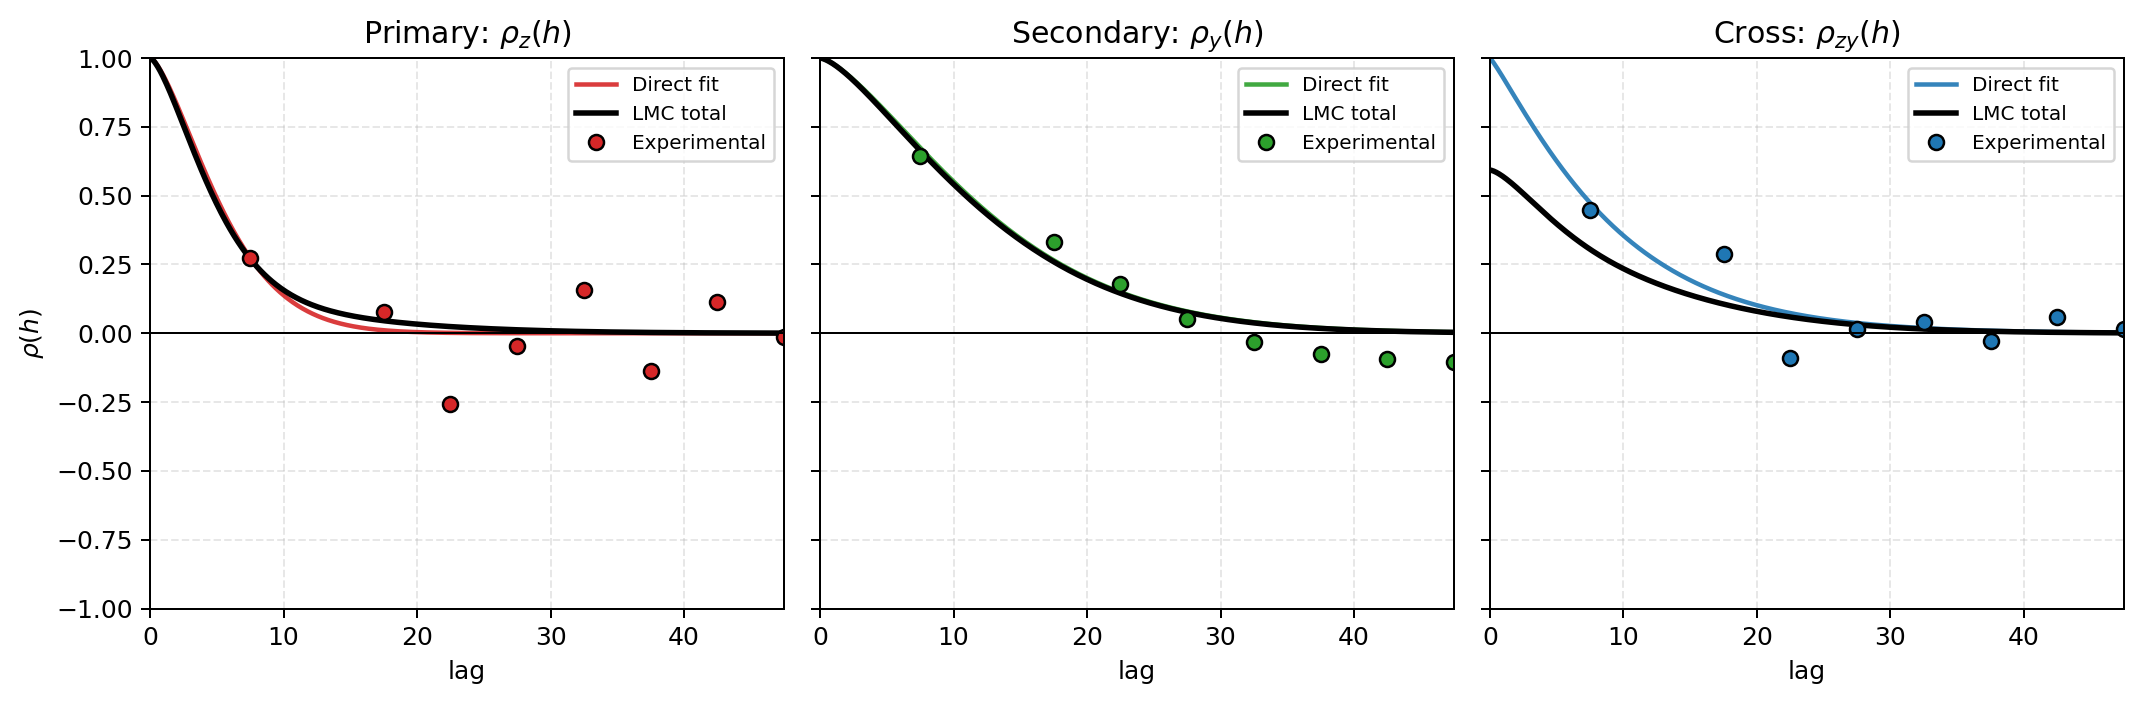

best objective = 0.022956019990793115
best rho0_fit = 0.5929542522974408
best feasible = False
best n_bad_total = 12


In [19]:
h_common, rz_common, ry_common, rzy_common, wz_common, wy_common, wzy_common = align_lmc_experimental_bins(
    h_primary=h_lag_primary,
    rho_primary=gamma_primary,
    n_primary=n_obs_primary,
    h_secondary=h_lag_secondary,
    rho_secondary=gamma_secondary,
    n_secondary=n_obs_secondary,
    h_cross=h_lag_cross,
    rho_cross=gamma12_cross,
    n_cross=n_obs_cross,
)

rho0_target = estimate_collocated_correlation(
    datafl["Primary"].to_numpy(),
    datafl["Secondary"].to_numpy(),
    method="pearson",
)

search_res = search_lmc_model_space(
    h_common,
    rz_common,
    ry_common,
    rzy_common,

    fixed_structures=None,

    model_family="variogram",
    model_type=model,                 # e.g. "powered_exponential"
    params_primary=params_primary,
    params_secondary=params_secondary,
    params_cross=params_cross,

    n_ranges=7,
    range_spacing="linear",
    range_padding_frac=0.15,
    include_direct_ranges=True,
    include_shape_average=True,
    n_structures=2,
    allow_repeated_kernels=False,

    w_primary=wz_common,
    w_secondary=wy_common,
    w_cross=wzy_common,

    cross_misfit_weight_grid=[0.25, 0.5, 1.0, 2.0, 5.0],
    rho0_penalty_weight_grid=[0.0, 0.01, 0.1, 1.0, 10.0],

    normalize_weights=True,

    plot_best=True,
    verbose=False,

)

best = search_res["best"]
best_fit = best["fit"]

print("best objective =", best["objective"])
print("best rho0_fit =", best["rho0_fit"])
print("best feasible =", best["is_feasible"])
print("best n_bad_total =", best["n_bad_total"])

## 5.2 Run Co-kriging

### 5.2.1 Case 0: No LMC and No Azimuth/Azimuth

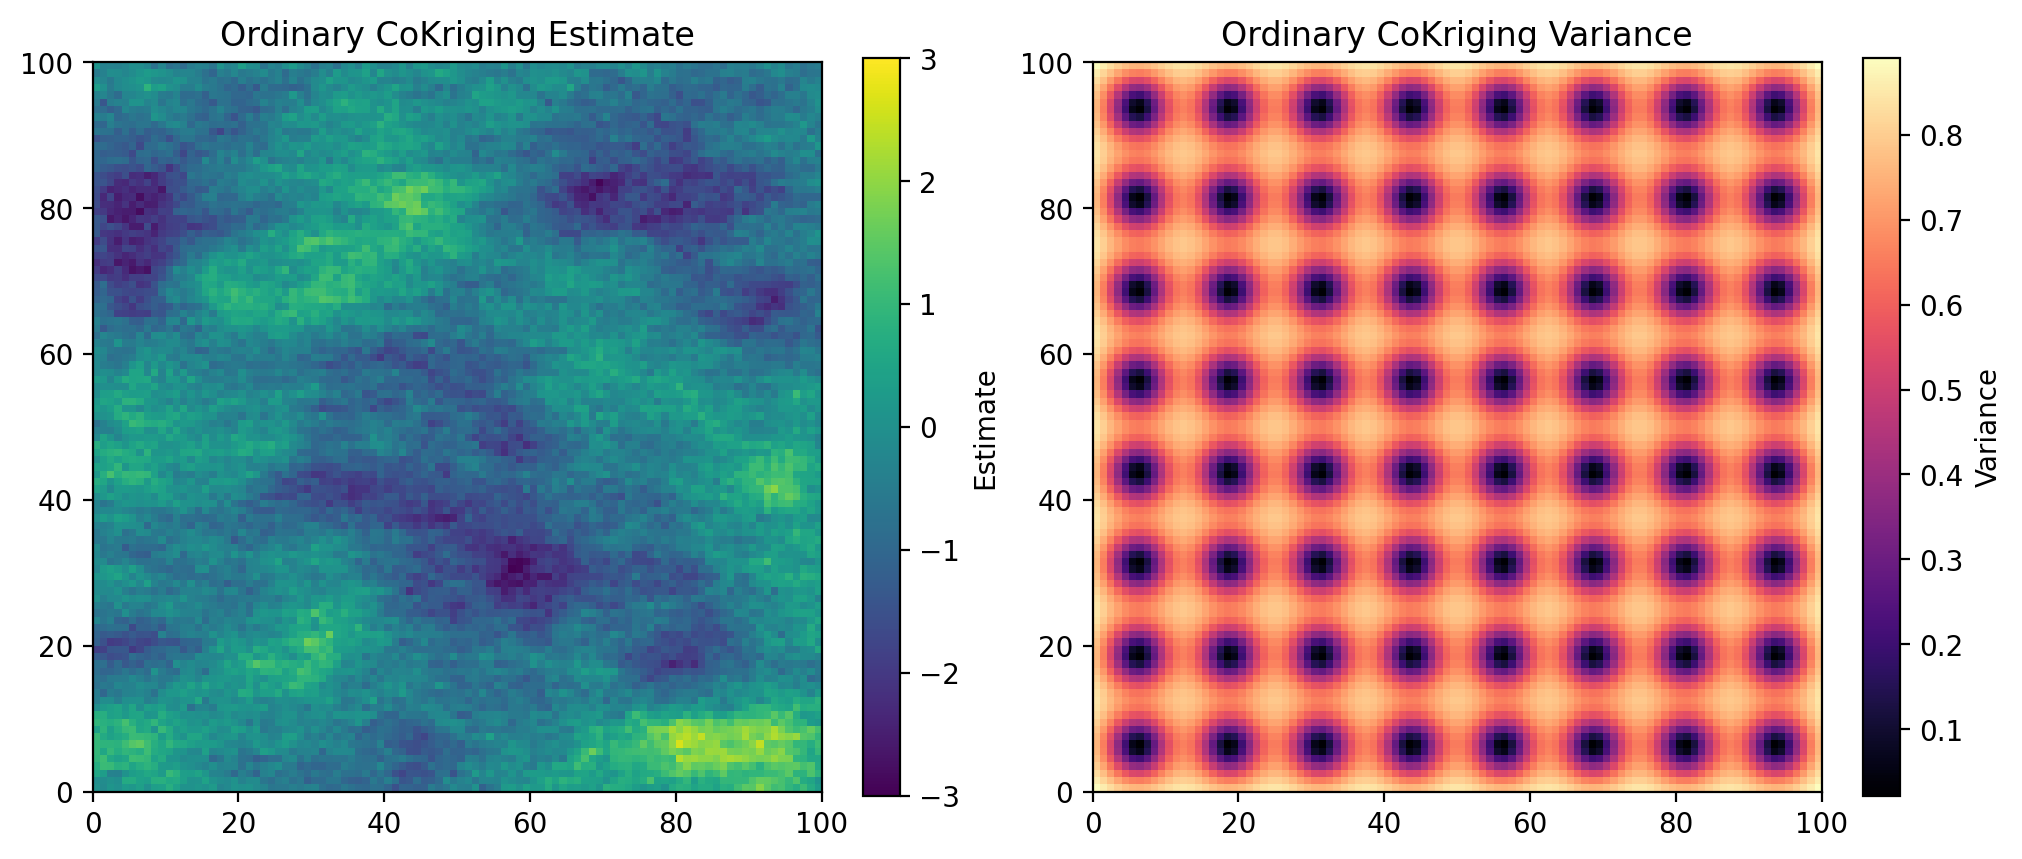

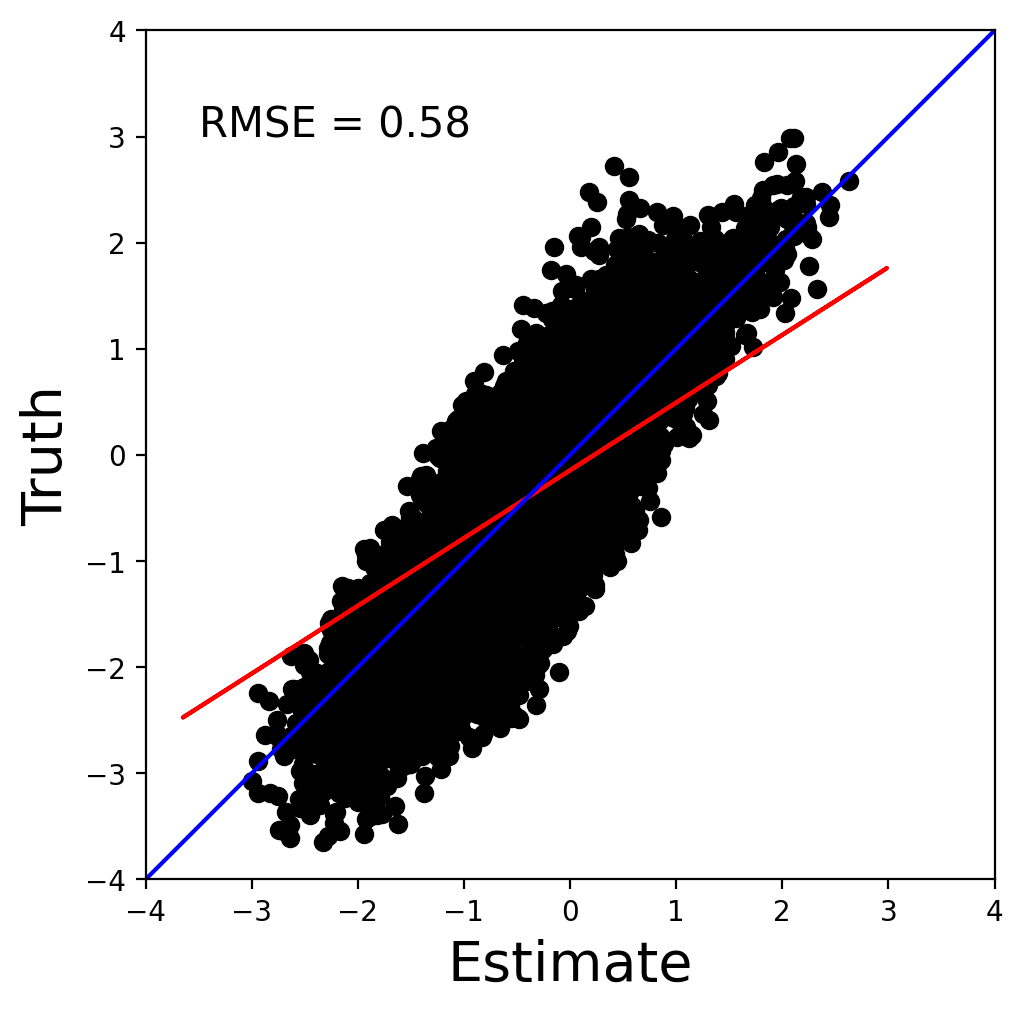

In [20]:
primary_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_primary,
)

secondary_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_secondary,
)

cross_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_cross,
    cross_scale=0.32,
)

est, var, wz, wy = ordinary_cokriging(
    primary_values=datafl["Primary"].to_numpy(),
    primary_coords=datafl[["X", "Y"]].to_numpy(),
    secondary_values=datafl_sec["Secondary"].to_numpy(),
    secondary_coords=datafl_sec[["X", "Y"]].to_numpy(),
    targets=datafl_sec[["X", "Y"]].to_numpy(),
    covariance_mode="direct",
    primary_model=primary_model,
    secondary_model=secondary_model,
    cross_model=cross_model,
    distance_type="cartesian",
    rotation_matrix=None,
    standardize=True,
    jitter=1e-10,
    check_positive_definite=True,
    return_weights=True,
)

# plot
nx = len(np.unique(datafl_sec["X"]))
ny = len(np.unique(datafl_sec["Y"]))

X = datafl_sec["X"].to_numpy().reshape(ny, nx)
Y = datafl_sec["Y"].to_numpy().reshape(ny, nx)

EST = est.reshape(ny, nx)
VAR = var.reshape(ny, nx)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=200, constrained_layout=True)
im0 = ax[0].pcolormesh(X, Y, EST, cmap="viridis", shading="auto", vmin = -3, vmax = 3)
ax[0].set_title("Ordinary CoKriging Estimate")
ax[0].set_aspect("equal")
fig.colorbar(im0, ax=ax[0], label="Estimate", aspect = 20, shrink=0.75, pad = 0.02)
im1 = ax[1].pcolormesh(X, Y, VAR, cmap="magma", shading="auto")
ax[1].set_title("Ordinary CoKriging Variance")
ax[1].set_aspect("equal")
fig.colorbar(im1, ax=ax[1], label="Variance", aspect = 20, shrink=0.75, pad = 0.02)
plt.show()

# RMSE
RMSE = np.sqrt(mean_squared_error(est, truth["Primary"]))

fig, ax = plt.subplots(figsize=(5, 5), dpi=200, constrained_layout=True)
ax.scatter(est, truth["Primary"], color="Black")
ax.plot(
        (truth["Primary"]),
        np.poly1d(
            np.polyfit(
                truth["Primary"], est, 1
            )
        )((truth["Primary"])),
        color="Red",
    )
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
x_45 = np.linspace(*ax.get_xlim())
ax.plot(x_45, x_45, color="blue")
ax.set_xlabel("Estimate", size=20)
ax.set_ylabel("Truth", size=20)
ax.set_aspect("equal", "box")
ax.text(-3.5, 3.0, f"RMSE = {RMSE:.2f}", fontsize=15)
plt.show()

### 2.2.2 Case 1: LMC and No Azimuth

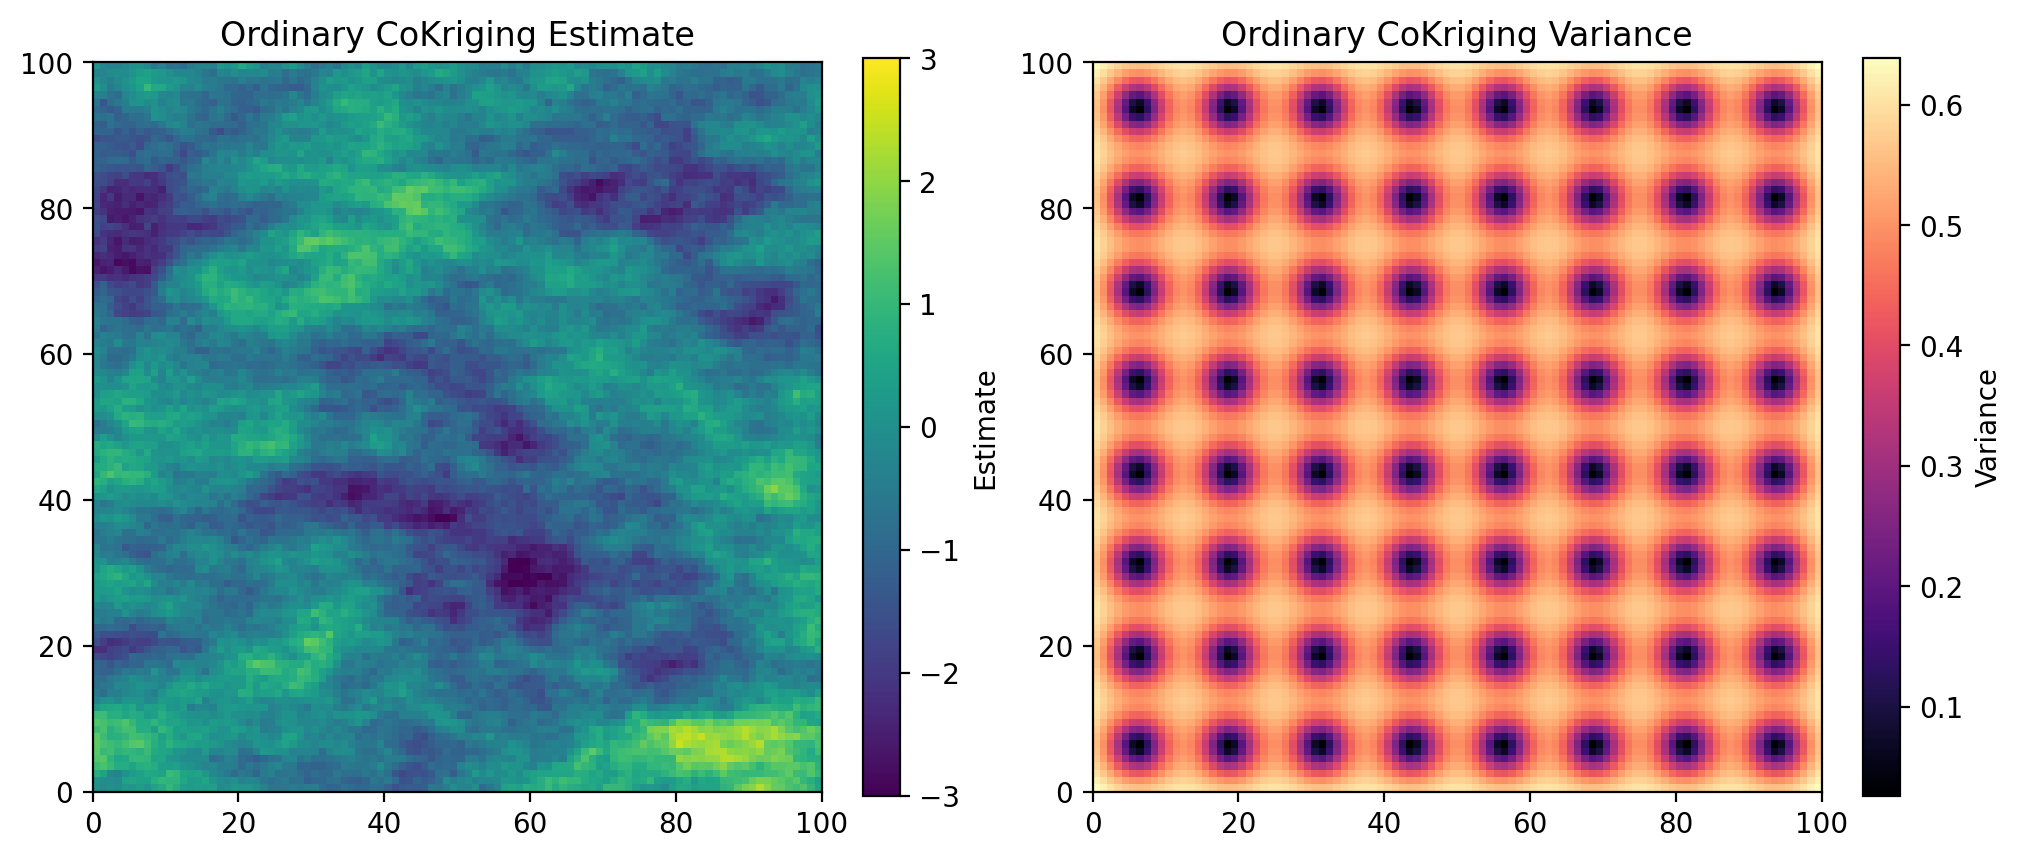

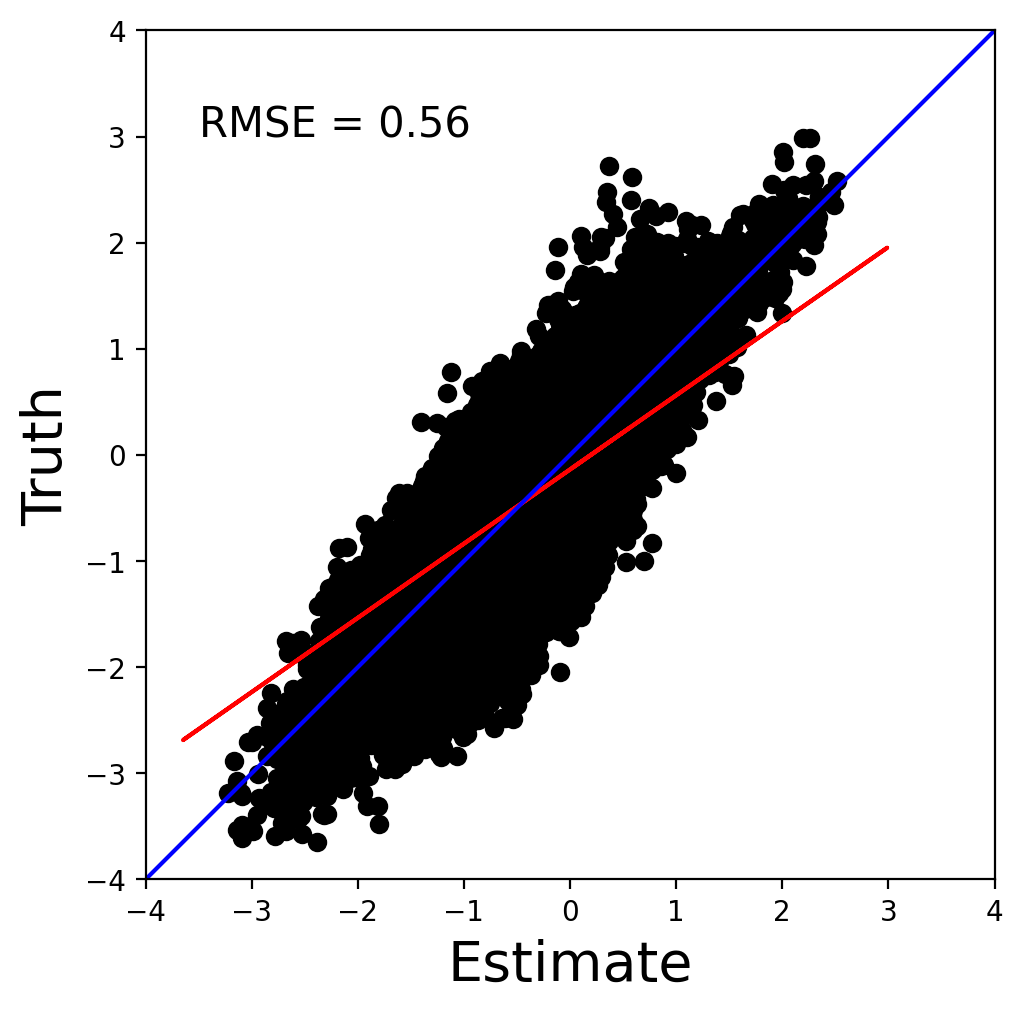

In [21]:
# use bestfit structures
structures = best_fit["structures"]
est, var, wz_ck, wy_ck = ordinary_cokriging(
    primary_values=datafl["Primary"].to_numpy(),
    primary_coords=datafl[["X", "Y"]].to_numpy(),
    secondary_values=datafl_sec["Secondary"].to_numpy(),
    secondary_coords=datafl_sec[["X", "Y"]].to_numpy(),
    targets=datafl_sec[["X", "Y"]].to_numpy(),
    covariance_mode="lmc",
    structures=structures,
    distance_type="cartesian",
    rotation_matrix=None,
    standardize=True,
    jitter=1e-10,
    check_positive_definite=True,
    return_weights=True,
)

# plot
nx = len(np.unique(datafl_sec["X"]))
ny = len(np.unique(datafl_sec["Y"]))

X = datafl_sec["X"].to_numpy().reshape(ny, nx)
Y = datafl_sec["Y"].to_numpy().reshape(ny, nx)

EST = est.reshape(ny, nx)
VAR = var.reshape(ny, nx)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=200, constrained_layout=True)
im0 = ax[0].pcolormesh(X, Y, EST, cmap="viridis", shading="auto", vmin = -3, vmax = 3)
ax[0].set_title("Ordinary CoKriging Estimate")
ax[0].set_aspect("equal")
fig.colorbar(im0, ax=ax[0], label="Estimate", aspect = 20, shrink=0.75, pad = 0.02)
im1 = ax[1].pcolormesh(X, Y, VAR, cmap="magma", shading="auto")
ax[1].set_title("Ordinary CoKriging Variance")
ax[1].set_aspect("equal")
fig.colorbar(im1, ax=ax[1], label="Variance", aspect = 20, shrink=0.75, pad = 0.02)
plt.show()

# RMSE
RMSE = np.sqrt(mean_squared_error(est, truth["Primary"]))

fig, ax = plt.subplots(figsize=(5, 5), dpi=200, constrained_layout=True)
ax.scatter(est, truth["Primary"], color="Black")
ax.plot(
        (truth["Primary"]),
        np.poly1d(
            np.polyfit(
                truth["Primary"], est, 1
            )
        )((truth["Primary"])),
        color="Red",
    )
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
x_45 = np.linspace(*ax.get_xlim())
ax.plot(x_45, x_45, color="blue")
ax.set_xlabel("Estimate", size=20)
ax.set_ylabel("Truth", size=20)
ax.set_aspect("equal", "box")
ax.text(-3.5, 3.0, f"RMSE = {RMSE:.2f}", fontsize=15)
plt.show()

# 6.0 Example 5: Ordinary Co-located Cokriging Markov Models

## 6.1 Make Residual Correlograms

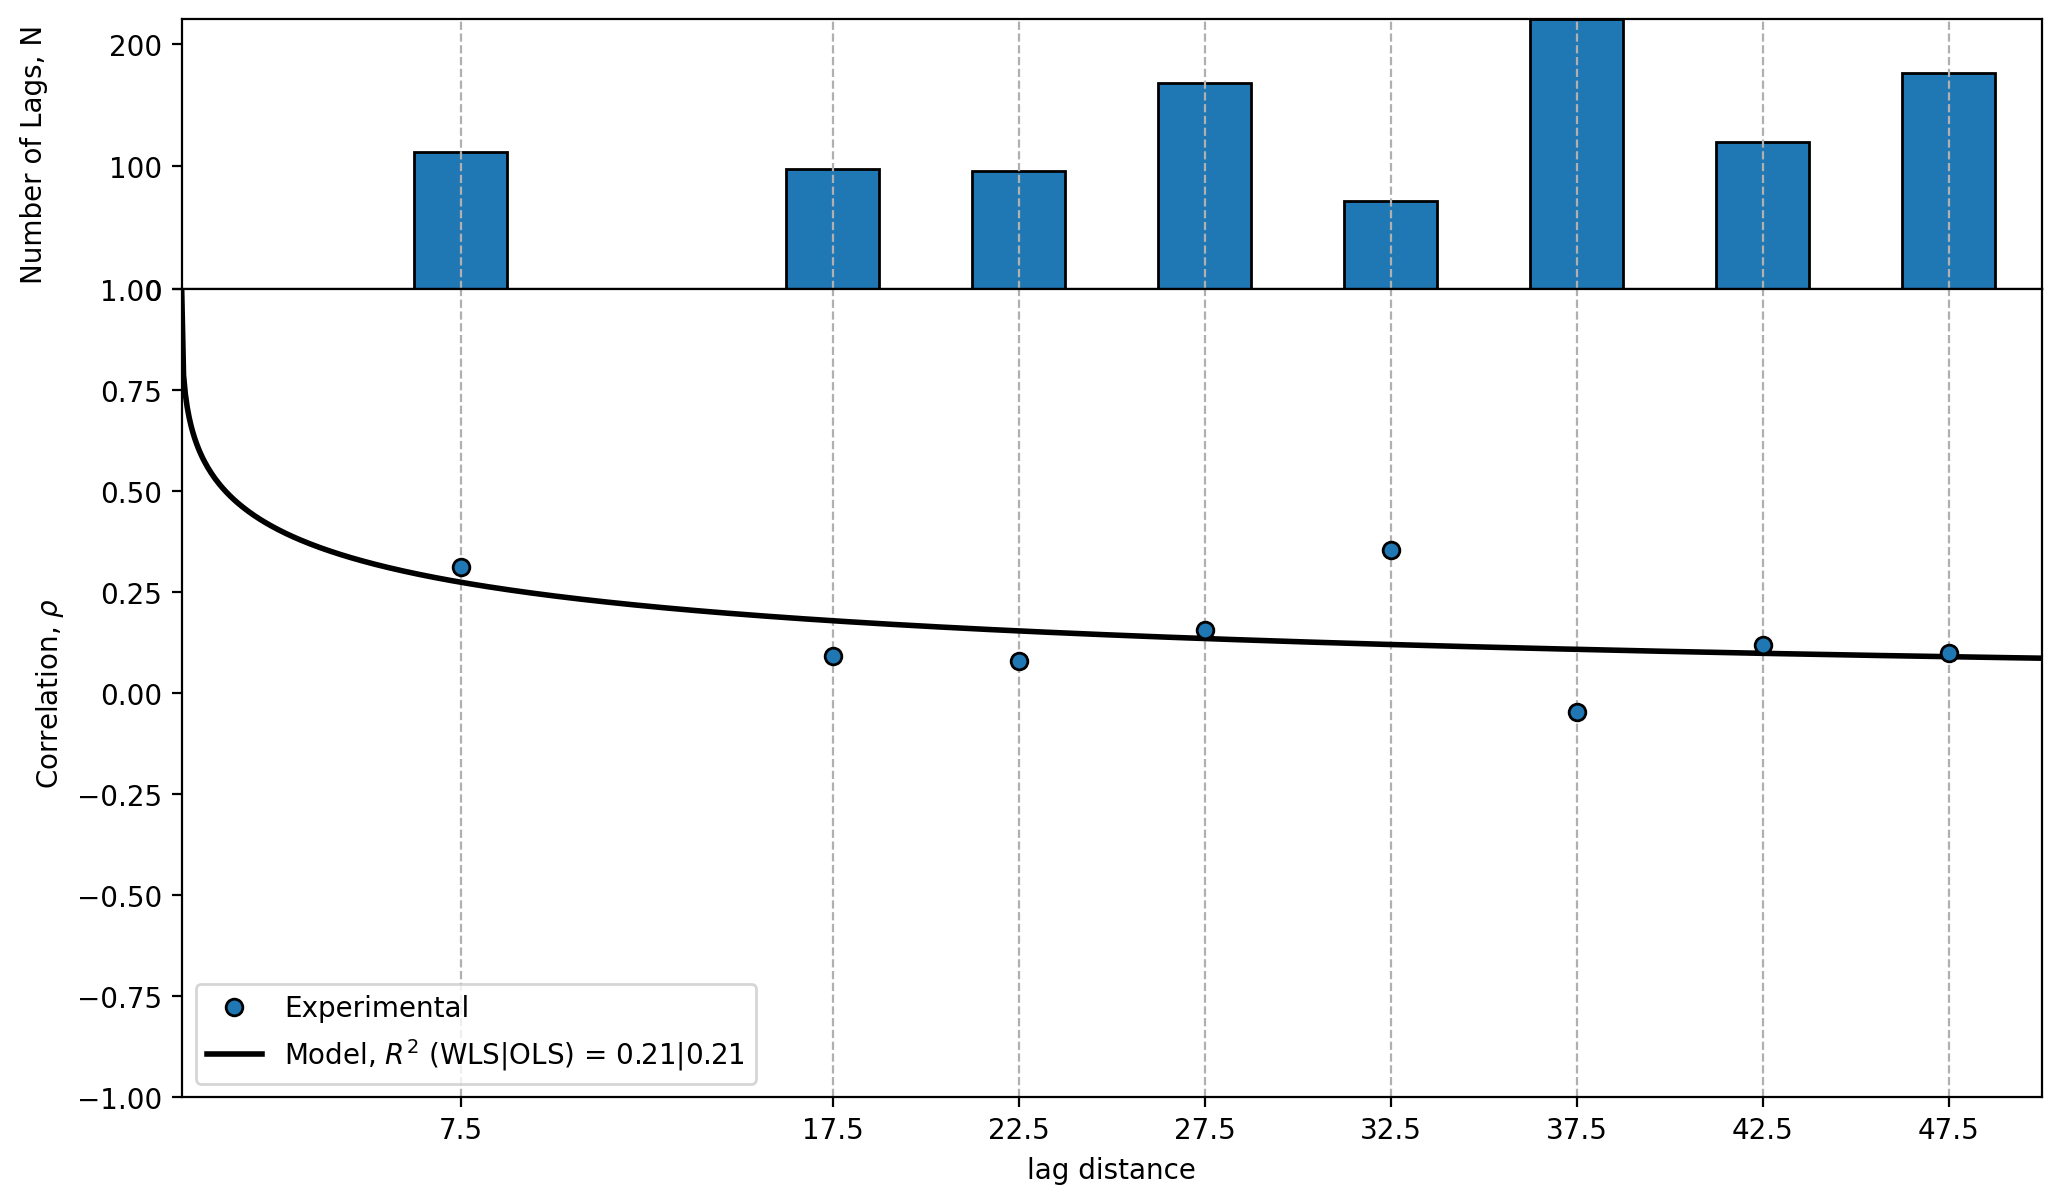

In [22]:
# get correlation between primary and secondary variables
rho0_target = estimate_collocated_correlation(
    datafl["Primary"].to_numpy(),
    datafl["Secondary"].to_numpy(),
    method="pearson",
)

# Collocated sample pairs at primary locations
z_pair = datafl["Primary"].to_numpy(dtype=float)
y_pair = datafl["Secondary"].to_numpy(dtype=float)
xy_pair = datafl[["X", "Y"]].to_numpy()

# Standardize using one consistent reference
mu_z = z_pair.mean()
sd_z = z_pair.std(ddof=1)
mu_y = y_pair.mean()
sd_y = y_pair.std(ddof=1)

z_std = (z_pair - mu_z) / sd_z
y_std = (y_pair - mu_y) / sd_y

# MM2 residual variable
r_mm2 = (z_std - rho0_target * y_std) / np.sqrt(1.0 - rho0_target**2)


# Fit direct correlogram model for the residual variable
h_lag_resid, n_obs_resid, rho_resid_emp, params_resid, r2_wls_resid, r2_ols_resid = variofit(
    values=r_mm2,
    coordinates=xy_pair,
    distance_type="cartesian",
    max_distance=50,
    bin_size=5,
    estimator_type=estimator,
    model_type=model,
    weight_fn=weight_fn,
    weight_params=weight_params,
    xmax_factor=xmax_factor,
    fix_sill=True,
    plot=True,
    transform="correlation",
)

## 6.2 Build Covariance models

In [23]:
# make models from correlograms
primary_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_primary,
)

secondary_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_secondary,
)

residual_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_resid,
)

rho0_target = estimate_collocated_correlation(
    datafl["Primary"].to_numpy(),
    datafl["Secondary"].to_numpy(),
    method="pearson",
)

print("rho0_target =", rho0_target)

rho0_target = 0.7197391780935076


## 6.4 Run Ordinary Co-located Cokriging

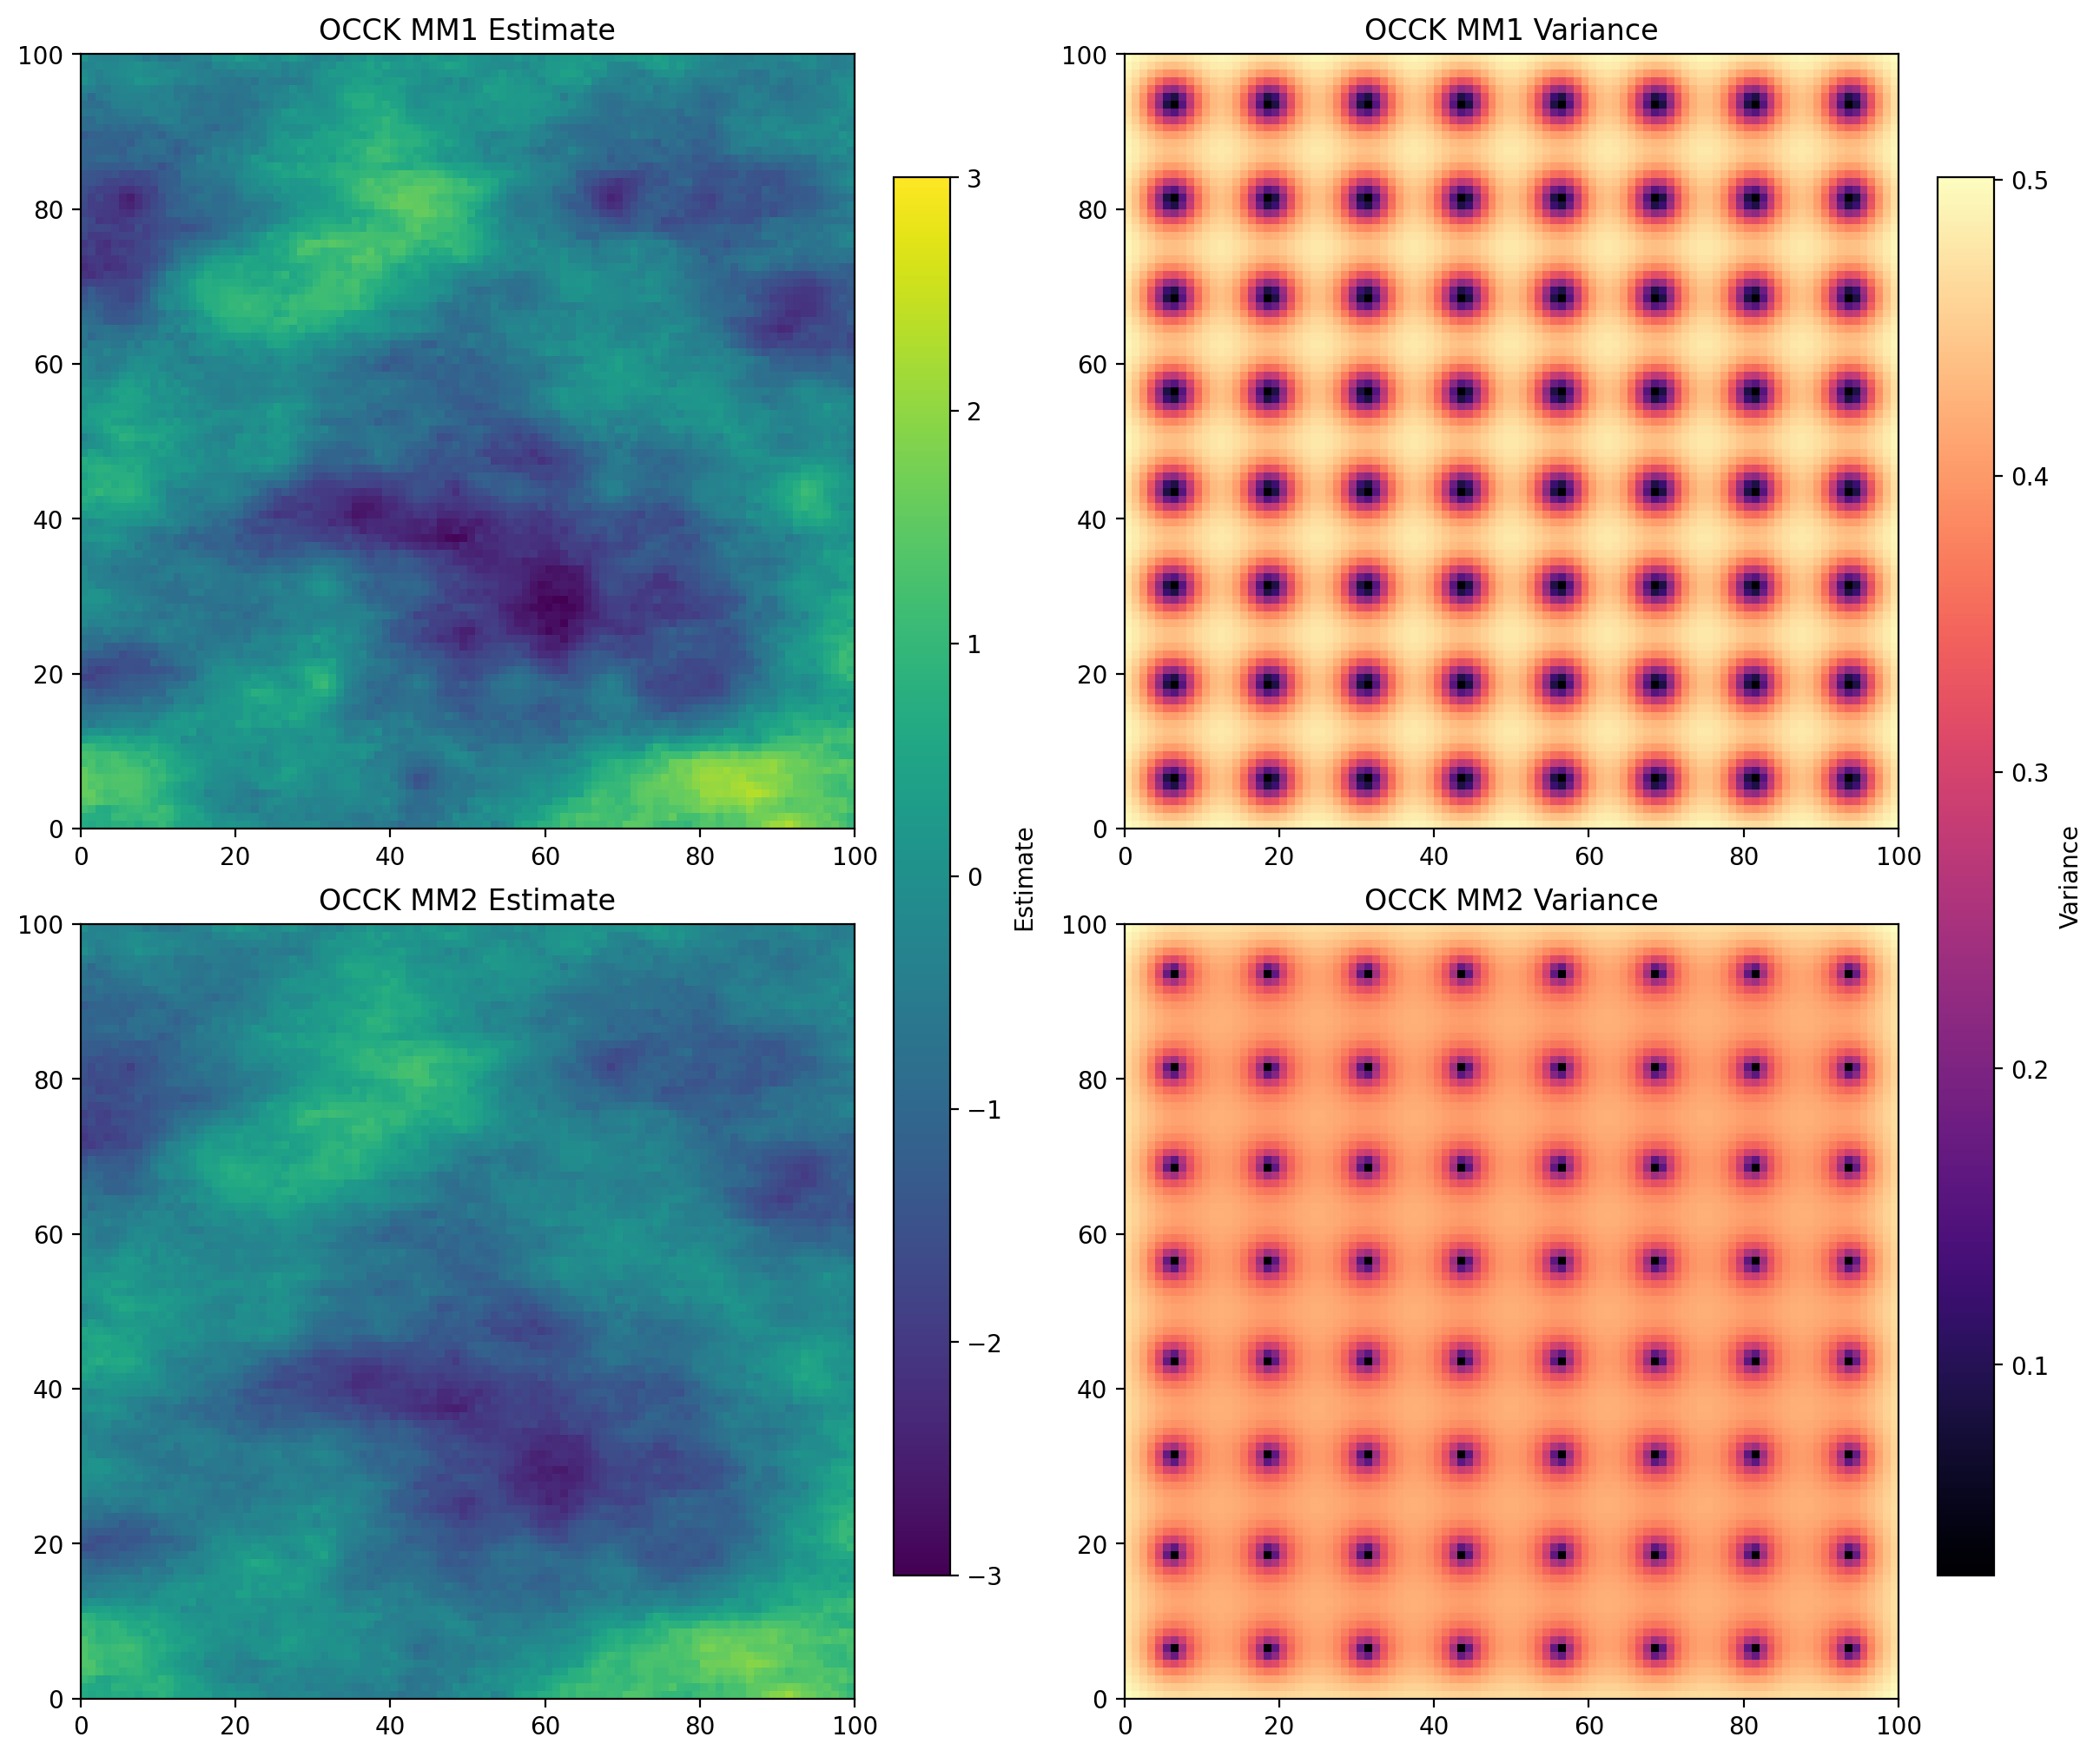

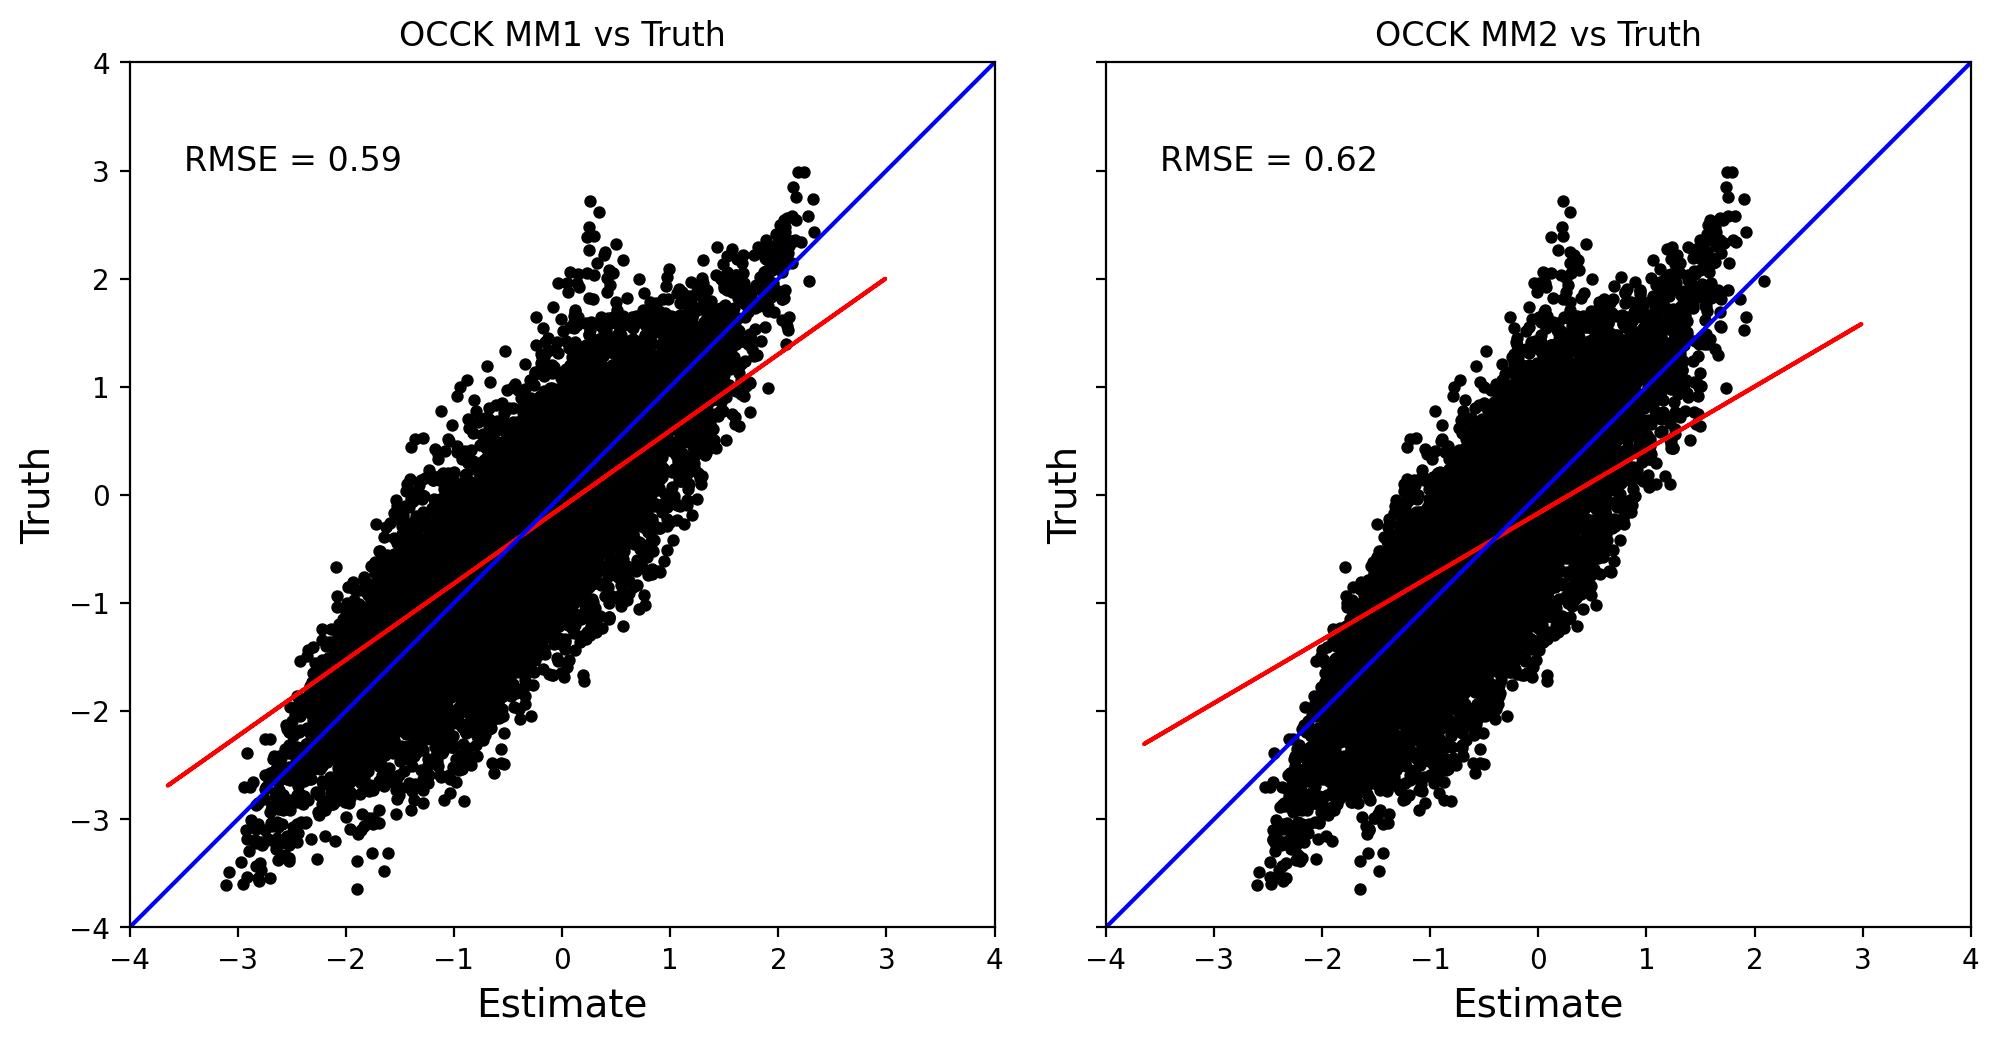

In [24]:
# MM1
est_mm1, var_mm1, wz_mm1, wy0_mm1 = OCCK_MM1(
    primary_values=datafl["Primary"].to_numpy(),
    primary_coords=datafl[["X", "Y"]].to_numpy(),
    collocated_secondary_values=datafl_sec["Secondary"].to_numpy(),
    targets=datafl_sec[["X", "Y"]].to_numpy(),
    rho0=rho0_target,
    primary_model=primary_model,
    secondary_values_for_standardization=datafl["Secondary"].to_numpy(),
    distance_type="cartesian",
    rotation_matrix=None,
    standardize=True,
    jitter=1e-10,
    check_positive_definite=True,
    return_weights=True,
    show_progress=False,
)

# MM2
est_mm2, var_mm2, wz_mm2, wy0_mm2 = OCCK_MM2(
    primary_values=datafl["Primary"].to_numpy(),
    primary_coords=datafl[["X", "Y"]].to_numpy(),
    collocated_secondary_values=datafl_sec["Secondary"].to_numpy(),
    targets=datafl_sec[["X", "Y"]].to_numpy(),
    rho0=rho0_target,
    secondary_model=secondary_model,
    residual_model=residual_model,
    secondary_values_for_standardization=datafl["Secondary"].to_numpy(),
    distance_type="cartesian",
    rotation_matrix=None,
    standardize=True,
    jitter=1e-10,
    check_positive_definite=True,
    return_weights=True,
    show_progress=False,
)

# plotting
rmse_mm1 = np.sqrt(mean_squared_error(truth["Primary"], est_mm1))
rmse_mm2 = np.sqrt(mean_squared_error(truth["Primary"], est_mm2))

nx = len(np.unique(datafl_sec["X"]))
ny = len(np.unique(datafl_sec["Y"]))

X = datafl_sec["X"].to_numpy().reshape(ny, nx)
Y = datafl_sec["Y"].to_numpy().reshape(ny, nx)

EST_mm1 = est_mm1.reshape(ny, nx)
VAR_mm1 = var_mm1.reshape(ny, nx)

EST_mm2 = est_mm2.reshape(ny, nx)
VAR_mm2 = var_mm2.reshape(ny, nx)

# Figure 1: maps with MM1 on top and MM2 below
fig, ax = plt.subplots(2, 2, figsize=(12, 10), dpi=200, constrained_layout=True)
im00 = ax[0, 0].pcolormesh(X, Y, EST_mm1, cmap="viridis", shading="auto", vmin=-3, vmax=3)
ax[0, 0].set_title(f"OCCK MM1 Estimate")
ax[0, 0].set_aspect("equal")
im01 = ax[0, 1].pcolormesh(X, Y, VAR_mm1, cmap="magma", shading="auto")
ax[0, 1].set_title(f"OCCK MM1 Variance")
ax[0, 1].set_aspect("equal")
im10 = ax[1, 0].pcolormesh(X, Y, EST_mm2, cmap="viridis", shading="auto", vmin=-3, vmax=3)
ax[1, 0].set_title(f"OCCK MM2 Estimate")
ax[1, 0].set_aspect("equal")
im11 = ax[1, 1].pcolormesh(X, Y, VAR_mm2, cmap="magma", shading="auto")
ax[1, 1].set_title(f"OCCK MM2 Variance")
ax[1, 1].set_aspect("equal")
fig.colorbar(im00, ax=ax[:, 0], label="Estimate", aspect=25, shrink=0.85, pad=0.02)
fig.colorbar(im01, ax=ax[:, 1], label="Variance", aspect=25, shrink=0.85, pad=0.02)
plt.show()

# Figure 2: MM1 and MM2 RMSE scatter plots
fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=200, constrained_layout=True, sharex=True, sharey=True)

# MM1
ax[0].scatter(est_mm1, truth["Primary"], color="black", s=12)
ax[0].plot(
    truth["Primary"],
    np.poly1d(np.polyfit(truth["Primary"], est_mm1, 1))(truth["Primary"]),
    color="red",
)
ax[0].set_xlim(-4, 4)
ax[0].set_ylim(-4, 4)
x_45 = np.linspace(-4, 4, 200)
ax[0].plot(x_45, x_45, color="blue")
ax[0].set_xlabel("Estimate", size=14)
ax[0].set_ylabel("Truth", size=14)
ax[0].set_aspect("equal", "box")
ax[0].text(-3.5, 3.0, f"RMSE = {rmse_mm1:.2f}", fontsize=12)
ax[0].set_title("OCCK MM1 vs Truth")

# MM2
ax[1].scatter(est_mm2, truth["Primary"], color="black", s=12)
ax[1].plot(
    truth["Primary"],
    np.poly1d(np.polyfit(truth["Primary"], est_mm2, 1))(truth["Primary"]),
    color="red",
)
ax[1].plot(x_45, x_45, color="blue")
ax[1].set_xlim(-4, 4)
ax[1].set_ylim(-4, 4)
ax[1].set_xlabel("Estimate", size=14)
ax[1].set_ylabel("Truth", size=14)
ax[1].set_aspect("equal", "box")
ax[1].text(-3.5, 3.0, f"RMSE = {rmse_mm2:.2f}", fontsize=12)
ax[1].set_title("OCCK MM2 vs Truth")

plt.show()

# 7.0 Example 6: Ordinary Intrinsic Co-located Cokriging Markov Models

## 7.1 Make Residual Correlograms

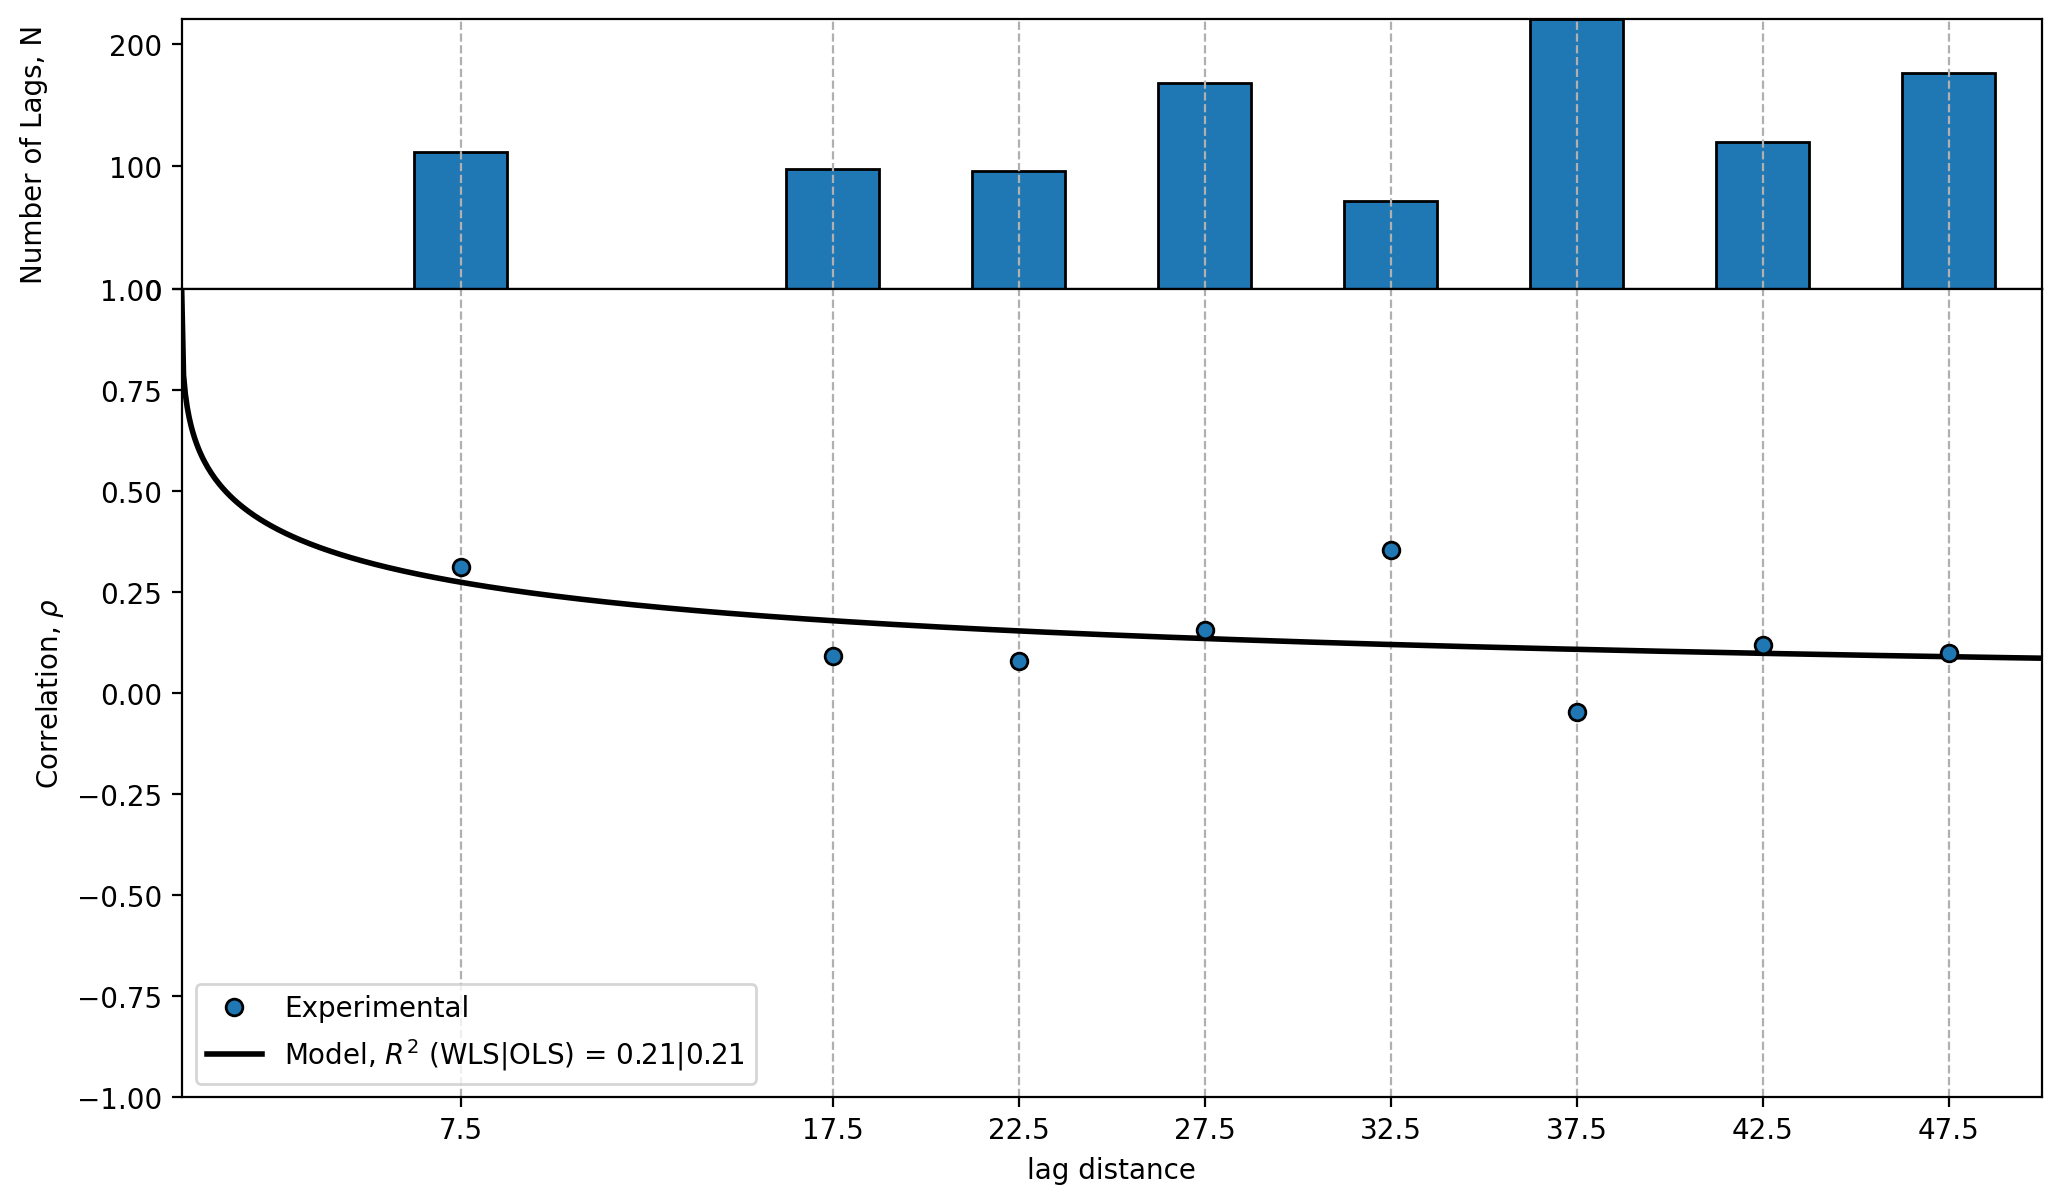

In [25]:
# get correlation between primary and secondary variables
rho0_target = estimate_collocated_correlation(
    datafl["Primary"].to_numpy(),
    datafl["Secondary"].to_numpy(),
    method="pearson",
)

# Collocated sample pairs at primary locations
z_pair = datafl["Primary"].to_numpy(dtype=float)
y_pair = datafl["Secondary"].to_numpy(dtype=float)
xy_pair = datafl[["X", "Y"]].to_numpy()

# Standardize using one consistent reference
mu_z = z_pair.mean()
sd_z = z_pair.std(ddof=1)
mu_y = y_pair.mean()
sd_y = y_pair.std(ddof=1)

z_std = (z_pair - mu_z) / sd_z
y_std = (y_pair - mu_y) / sd_y

# MM2 residual variable
r_mm2 = (z_std - rho0_target * y_std) / np.sqrt(1.0 - rho0_target**2)


# Fit direct correlogram model for the residual variable
h_lag_resid, n_obs_resid, rho_resid_emp, params_resid, r2_wls_resid, r2_ols_resid = variofit(
    values=r_mm2,
    coordinates=xy_pair,
    distance_type="cartesian",
    max_distance=50,
    bin_size=5,
    estimator_type=estimator,
    model_type=model,
    weight_fn=weight_fn,
    weight_params=weight_params,
    xmax_factor=xmax_factor,
    fix_sill=True,
    plot=True,
    transform="correlation",
)

## 7.2 Build Covariance models

In [26]:
# make models from correlograms
primary_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_primary,
)

secondary_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_secondary,
)

residual_model = make_covmodel_spec(
    model_family="variogram",
    model_type="powered_exponential",
    params=params_resid,
)

rho0_target = estimate_collocated_correlation(
    datafl["Primary"].to_numpy(),
    datafl["Secondary"].to_numpy(),
    method="pearson",
)

print("rho0_target =", rho0_target)

rho0_target = 0.7197391780935076


## 7.3 Run Ordinary Intrinsic Co-located Cokriging

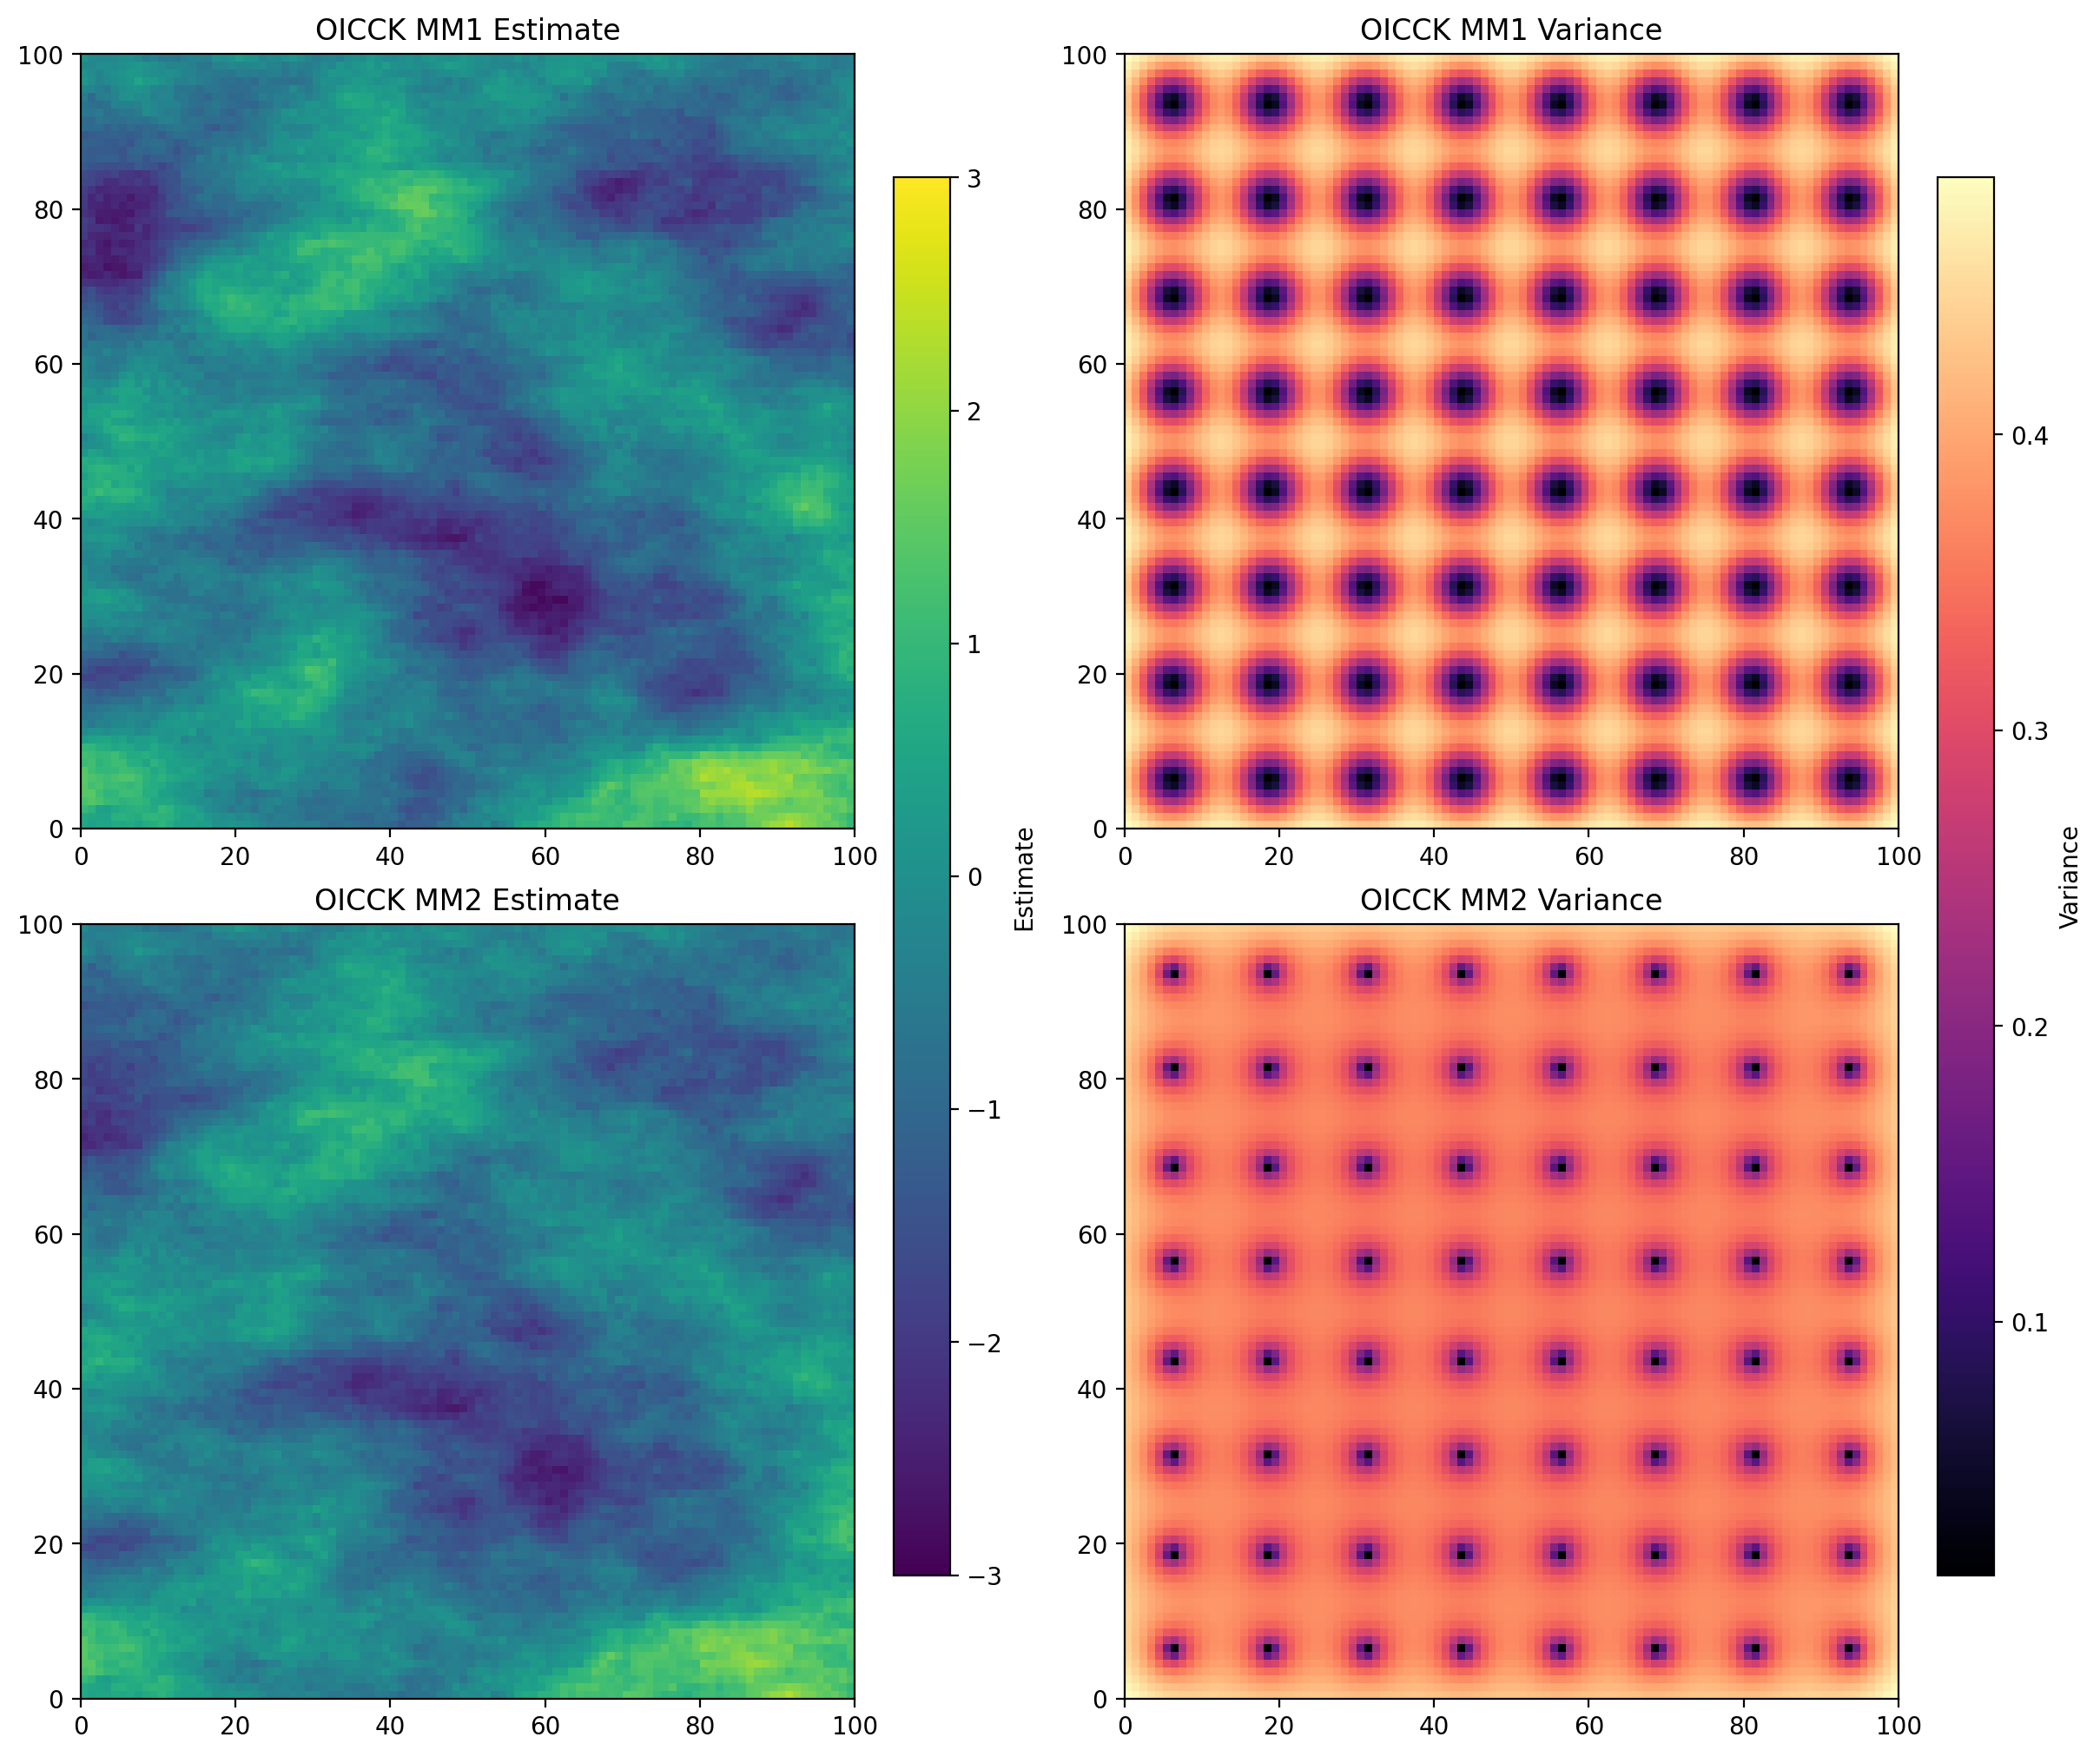

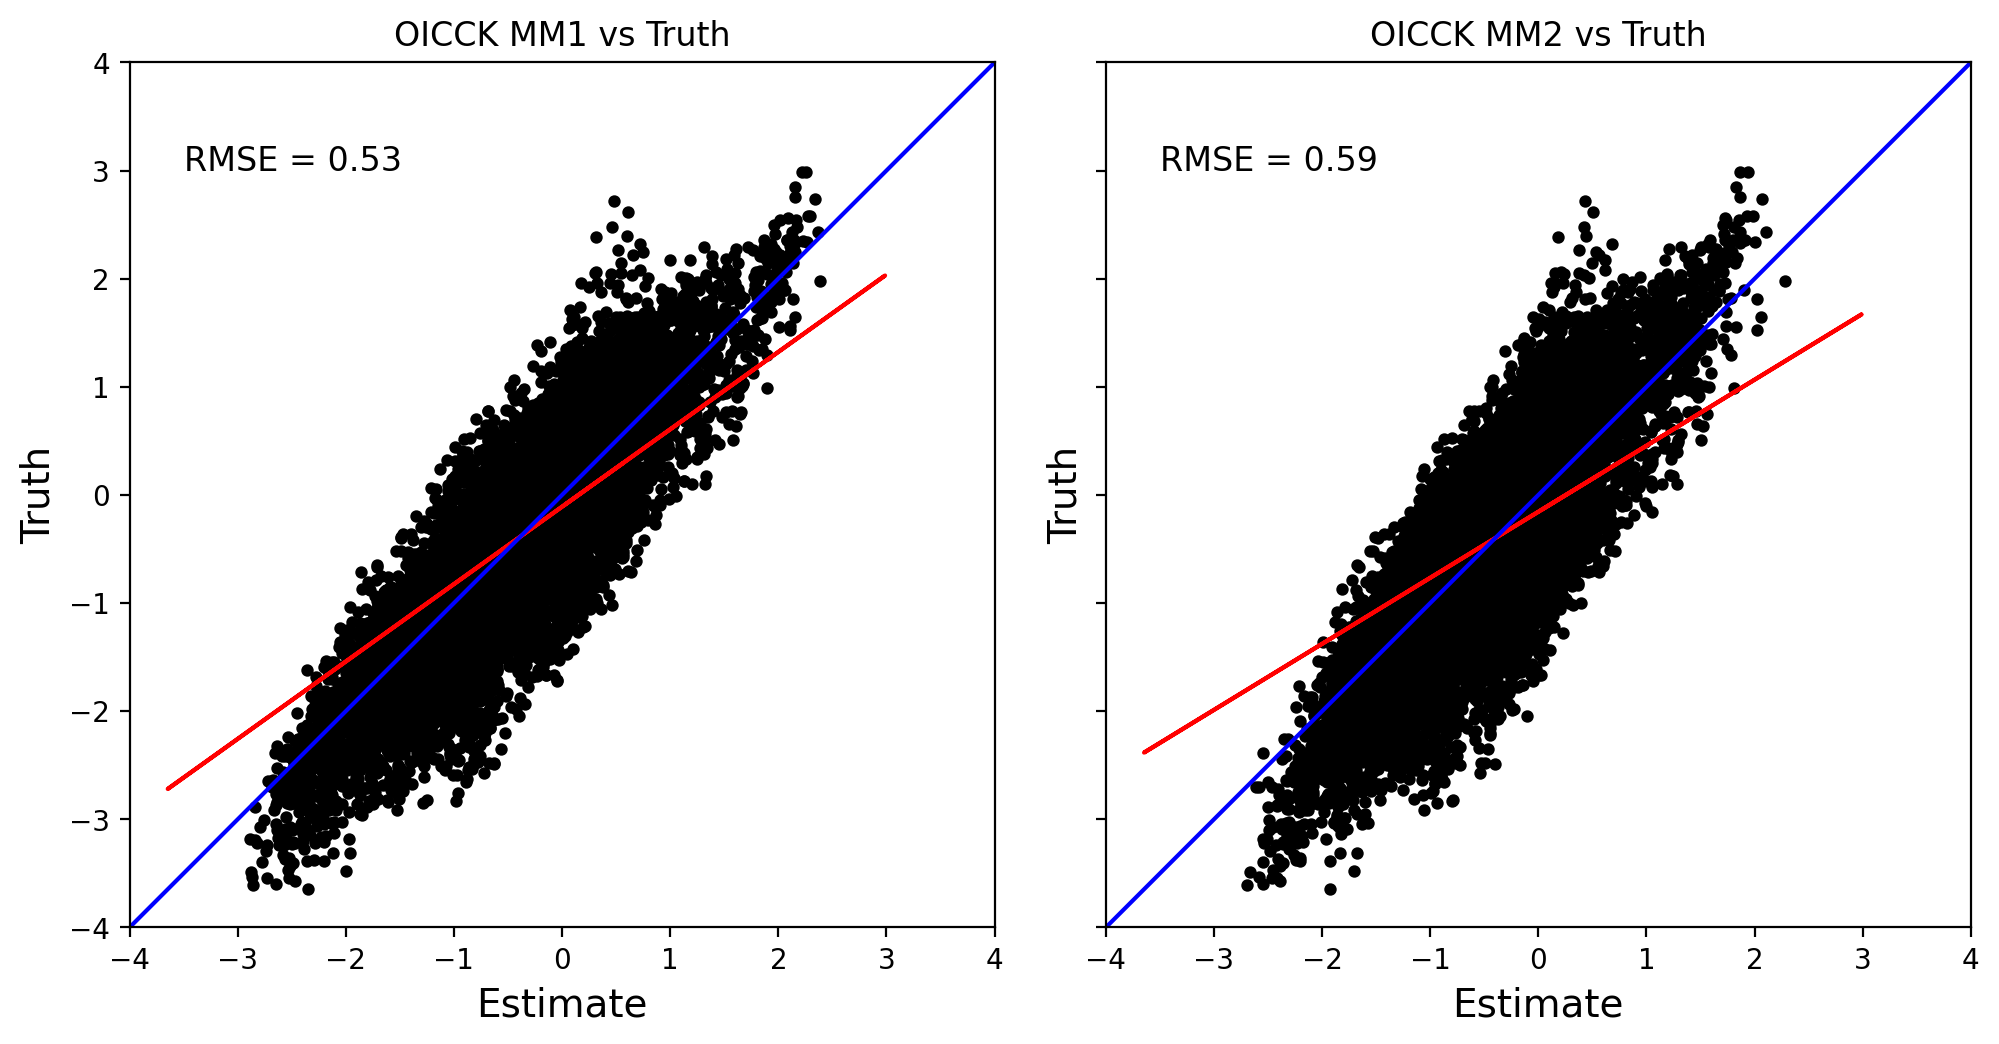

In [27]:
# ICCK MM1
est_mm1, var_mm1, wz_mm1, wy_mm1, wy0_mm1 = OICCK_MM1(
    primary_values=datafl["Primary"].to_numpy(),
    primary_coords=datafl[["X", "Y"]].to_numpy(),
    secondary_values=datafl["Secondary"].to_numpy(),
    secondary_coords=datafl[["X", "Y"]].to_numpy(),
    collocated_secondary_values=datafl_sec["Secondary"].to_numpy(),
    targets=datafl_sec[["X", "Y"]].to_numpy(),
    rho0=rho0_target,
    primary_model=primary_model,
    secondary_values_for_standardization=datafl["Secondary"].to_numpy(),
    distance_type="cartesian",
    rotation_matrix=None,
    standardize=True,
    jitter=1e-10,
    check_positive_definite=True,
    return_weights=True,
    show_progress=False,
)

# ICCK MM2
est_mm2, var_mm2, wz_mm2, wy_mm2, wy0_mm2 = OICCK_MM2(
    primary_values=datafl["Primary"].to_numpy(),
    primary_coords=datafl[["X", "Y"]].to_numpy(),
    secondary_values=datafl["Secondary"].to_numpy(),
    secondary_coords=datafl[["X", "Y"]].to_numpy(),
    collocated_secondary_values=datafl_sec["Secondary"].to_numpy(),
    targets=datafl_sec[["X", "Y"]].to_numpy(),
    rho0=rho0_target,
    secondary_model=secondary_model,
    residual_model=residual_model,
    secondary_values_for_standardization=datafl["Secondary"].to_numpy(),
    distance_type="cartesian",
    rotation_matrix=None,
    standardize=True,
    jitter=1e-10,
    check_positive_definite=True,
    return_weights=True,
    show_progress=False,
)

# plotting
rmse_mm1 = np.sqrt(mean_squared_error(truth["Primary"], est_mm1))
rmse_mm2 = np.sqrt(mean_squared_error(truth["Primary"], est_mm2))

nx = len(np.unique(datafl_sec["X"]))
ny = len(np.unique(datafl_sec["Y"]))

X = datafl_sec["X"].to_numpy().reshape(ny, nx)
Y = datafl_sec["Y"].to_numpy().reshape(ny, nx)

EST_mm1 = est_mm1.reshape(ny, nx)
VAR_mm1 = var_mm1.reshape(ny, nx)

EST_mm2 = est_mm2.reshape(ny, nx)
VAR_mm2 = var_mm2.reshape(ny, nx)

# Figure 1: maps with MM1 on top and MM2 below
fig, ax = plt.subplots(2, 2, figsize=(12, 10), dpi=200, constrained_layout=True)

im00 = ax[0, 0].pcolormesh(X, Y, EST_mm1, cmap="viridis", shading="auto", vmin=-3, vmax=3)
ax[0, 0].set_title("OICCK MM1 Estimate")
ax[0, 0].set_aspect("equal")

im01 = ax[0, 1].pcolormesh(X, Y, VAR_mm1, cmap="magma", shading="auto")
ax[0, 1].set_title("OICCK MM1 Variance")
ax[0, 1].set_aspect("equal")

im10 = ax[1, 0].pcolormesh(X, Y, EST_mm2, cmap="viridis", shading="auto", vmin=-3, vmax=3)
ax[1, 0].set_title("OICCK MM2 Estimate")
ax[1, 0].set_aspect("equal")

im11 = ax[1, 1].pcolormesh(X, Y, VAR_mm2, cmap="magma", shading="auto")
ax[1, 1].set_title("OICCK MM2 Variance")
ax[1, 1].set_aspect("equal")

fig.colorbar(im00, ax=ax[:, 0], label="Estimate", aspect=25, shrink=0.85, pad=0.02)
fig.colorbar(im01, ax=ax[:, 1], label="Variance", aspect=25, shrink=0.85, pad=0.02)

plt.show()

# Figure 2: MM1 and MM2 RMSE scatter plots
fig, ax = plt.subplots(
    1, 2, figsize=(10, 5), dpi=200, constrained_layout=True, sharex=True, sharey=True
)

x_45 = np.linspace(-4, 4, 200)

# MM1
ax[0].scatter(est_mm1, truth["Primary"], color="black", s=12)
ax[0].plot(
    truth["Primary"],
    np.poly1d(np.polyfit(truth["Primary"], est_mm1, 1))(truth["Primary"]),
    color="red",
)
ax[0].plot(x_45, x_45, color="blue")
ax[0].set_xlim(-4, 4)
ax[0].set_ylim(-4, 4)
ax[0].set_xlabel("Estimate", size=14)
ax[0].set_ylabel("Truth", size=14)
ax[0].set_aspect("equal", "box")
ax[0].text(-3.5, 3.0, f"RMSE = {rmse_mm1:.2f}", fontsize=12)
ax[0].set_title("OICCK MM1 vs Truth")

# MM2
ax[1].scatter(est_mm2, truth["Primary"], color="black", s=12)
ax[1].plot(
    truth["Primary"],
    np.poly1d(np.polyfit(truth["Primary"], est_mm2, 1))(truth["Primary"]),
    color="red",
)
ax[1].plot(x_45, x_45, color="blue")
ax[1].set_xlim(-4, 4)
ax[1].set_ylim(-4, 4)
ax[1].set_xlabel("Estimate", size=14)
ax[1].set_ylabel("Truth", size=14)
ax[1].set_aspect("equal", "box")
ax[1].text(-3.5, 3.0, f"RMSE = {rmse_mm2:.2f}", fontsize=12)
ax[1].set_title("OICCK MM2 vs Truth")

plt.show()